# Appendix L: ResNet50V2 Tests 7

In [1]:
!nvidia-smi

Tue Mar 25 15:47:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   29C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
#!pip install tensorflow
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Import libraries

In [3]:
import tensorflow as tf # Access to models, datasets and training
from tensorflow.keras.datasets import cifar100 # Access to CIFAR-100
from tensorflow.keras.applications import ResNet50 # Access to pre-trained model
from tensorflow.keras import layers, models, optimizers # Access to building blocks of a model
from tensorflow.keras.models import load_model # Ability to load best_saved model
from tensorflow import keras # Access to stuff for model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard, CSVLogger
from sklearn.model_selection import train_test_split # To help split dataset up
from sklearn.metrics import confusion_matrix, classification_report # Analysis of model train, val & test
import numpy as np # Manipulate data
import pandas as pd # Statistical analysis of data
import seaborn as sns
import matplotlib.pyplot as plt # Plot data

# Function definitions

In [4]:
def display_imgs(imgs, labels):
        plt.subplots(figsize=(10,10))
        for i in range(16):
            plt.subplot(4, 4, i+1)
            k = np.random.randint(0, imgs.shape[0])
            if i == 0:
                print(f"labels[{k}].shape: {labels[k].shape}")
                print(f"imgs[{k}].shape: {imgs[k].shape}")
            plt.imshow(imgs[k])
            #plt.title(labels[k])
            plt.axis('off')
        plt.tight_layout()
        plt.show()


def class_distrib(y, labels_names, dataset_name):
        counts = pd.DataFrame(data=y).value_counts().sort_index()
        #print(f"counts:\n{counts}")
        fig, ax = plt.subplots(figsize=(20,10))
        ax.bar(labels_names, counts)
        ax.set_xticklabels(labels_names, rotation=90, fontsize=15)
        plt.title(f"Distribution of '{dataset_name}' Dataset", fontsize=25)
        plt.grid()
        plt.tight_layout()
        plt.show()

def augment_dataset(x, y):
        x = tf.image.resize(x, (224, 224))  # Resize images
        x = tf.image.random_flip_left_right(x)  # Random horizontal flip
        x = tf.image.random_brightness(x, max_delta=0.2)  # Adjust brightness
        x = tf.image.random_contrast(x, lower=0.8, upper=1.2)  # Adjust contrast
        y = tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))  # One-hot encode labels
        return x, y

def plot_evidence(epochs, train_loss, val_loss, train_acc, val_acc):
        # Plot Training and Validation Loss
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_loss, label='Training Loss')
        plt.plot(epochs, val_loss, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss')
        plt.legend()
        plt.grid()

        # Plot Training and Validation Accuracy
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_acc, label='Training Accuracy')
        plt.plot(epochs, val_acc, label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.legend()
        plt.grid()

        plt.tight_layout()
        plt.show()


# Dropout(0.6), weight_decay(3e-1), l2(3e-1) - no epoch stop

X_temp.shape: (8000, 32, 32, 3)

X_temp_val.shape: (4000, 32, 32, 3)
y_temp_val.shape: (4000, 1)
X_temp_test.shape: (4000, 32, 32, 3)
y_temp_test.shape: (4000, 1)

X_train.shape: (42000, 32, 32, 3)
y_train.shape: (42000, 1)
X_val.shape: (9000, 32, 32, 3)
y_val.shape: (9000, 1)
X_test.shape: (9000, 32, 32, 3)
y_test.shape: (9000, 1)

labels[819].shape: (1,)
imgs[819].shape: (32, 32, 3)


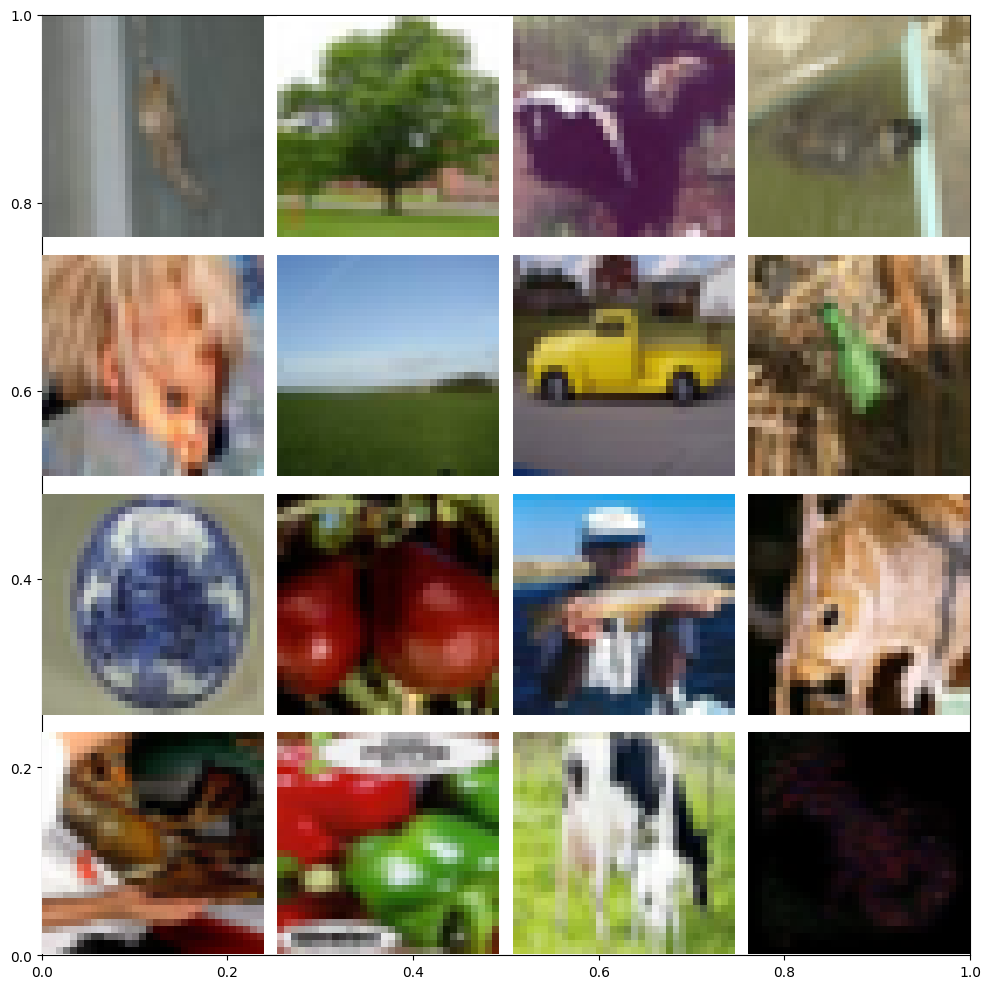

labels[21487].shape: (1,)
imgs[21487].shape: (32, 32, 3)


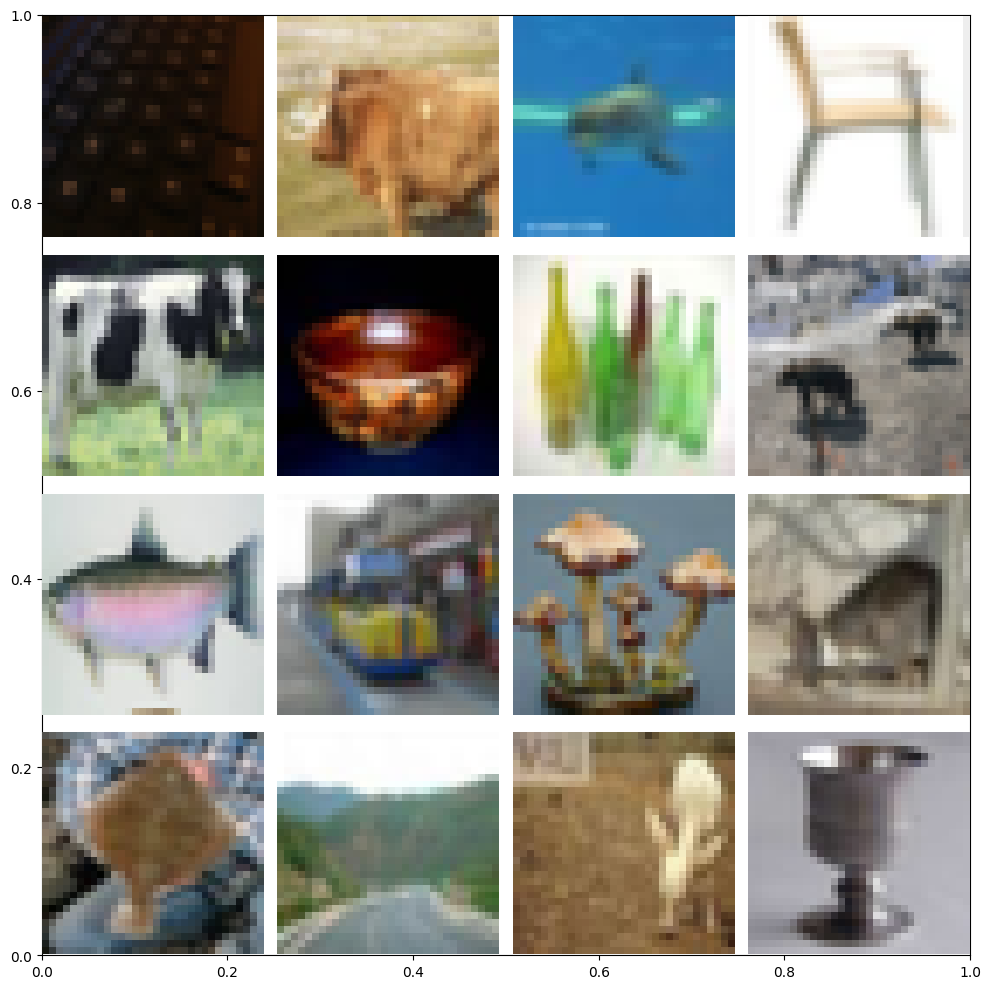

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


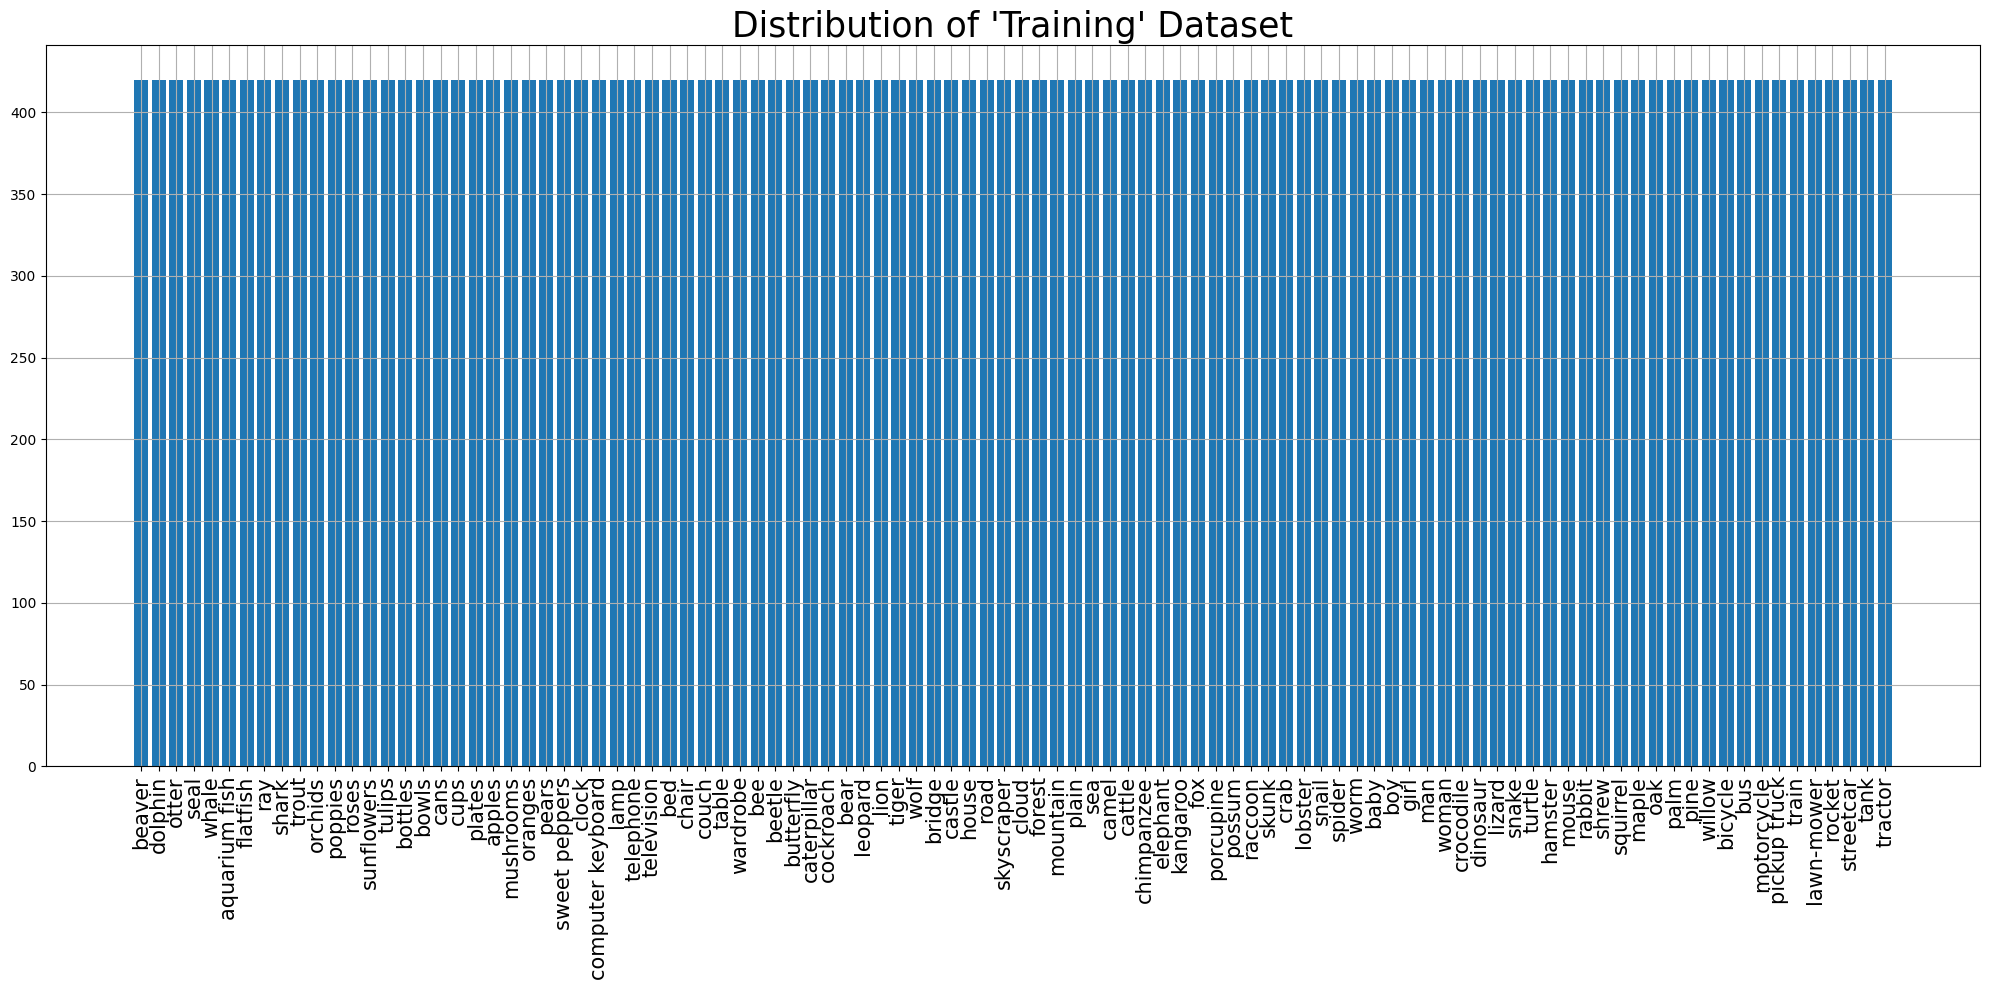

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


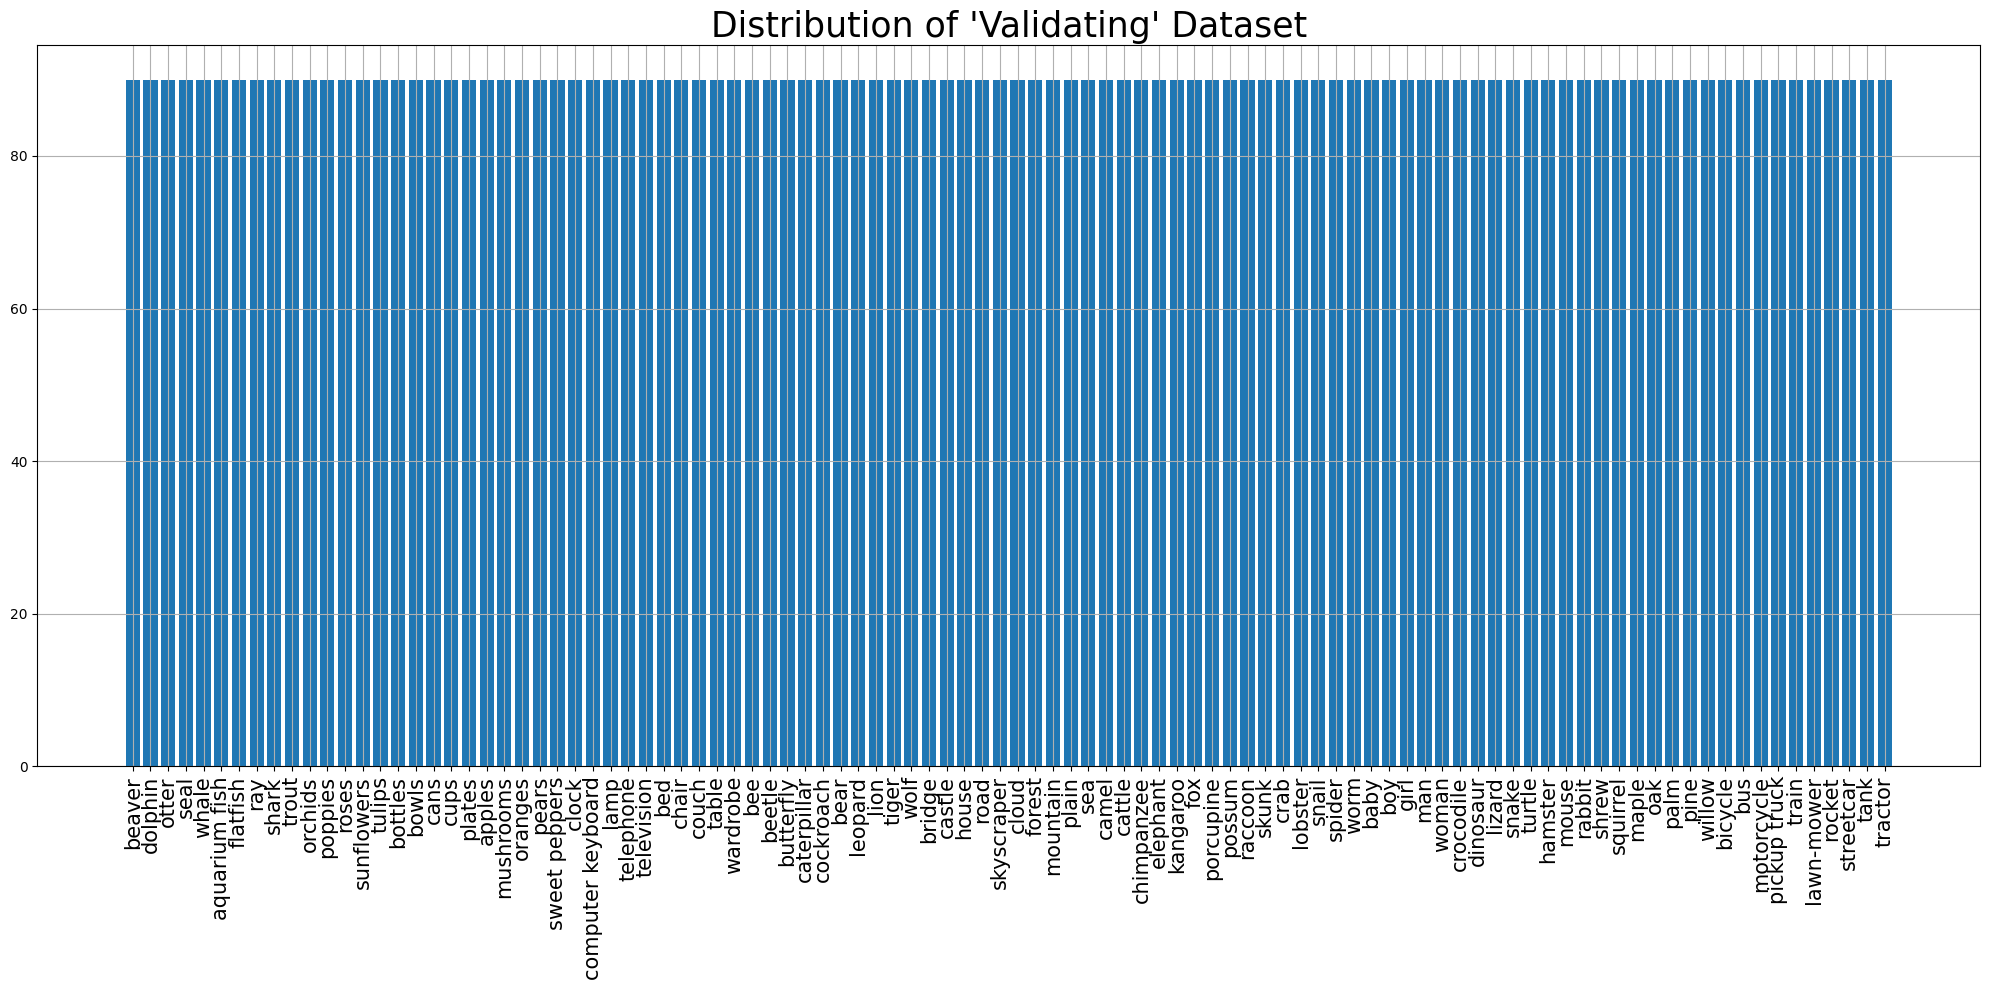

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


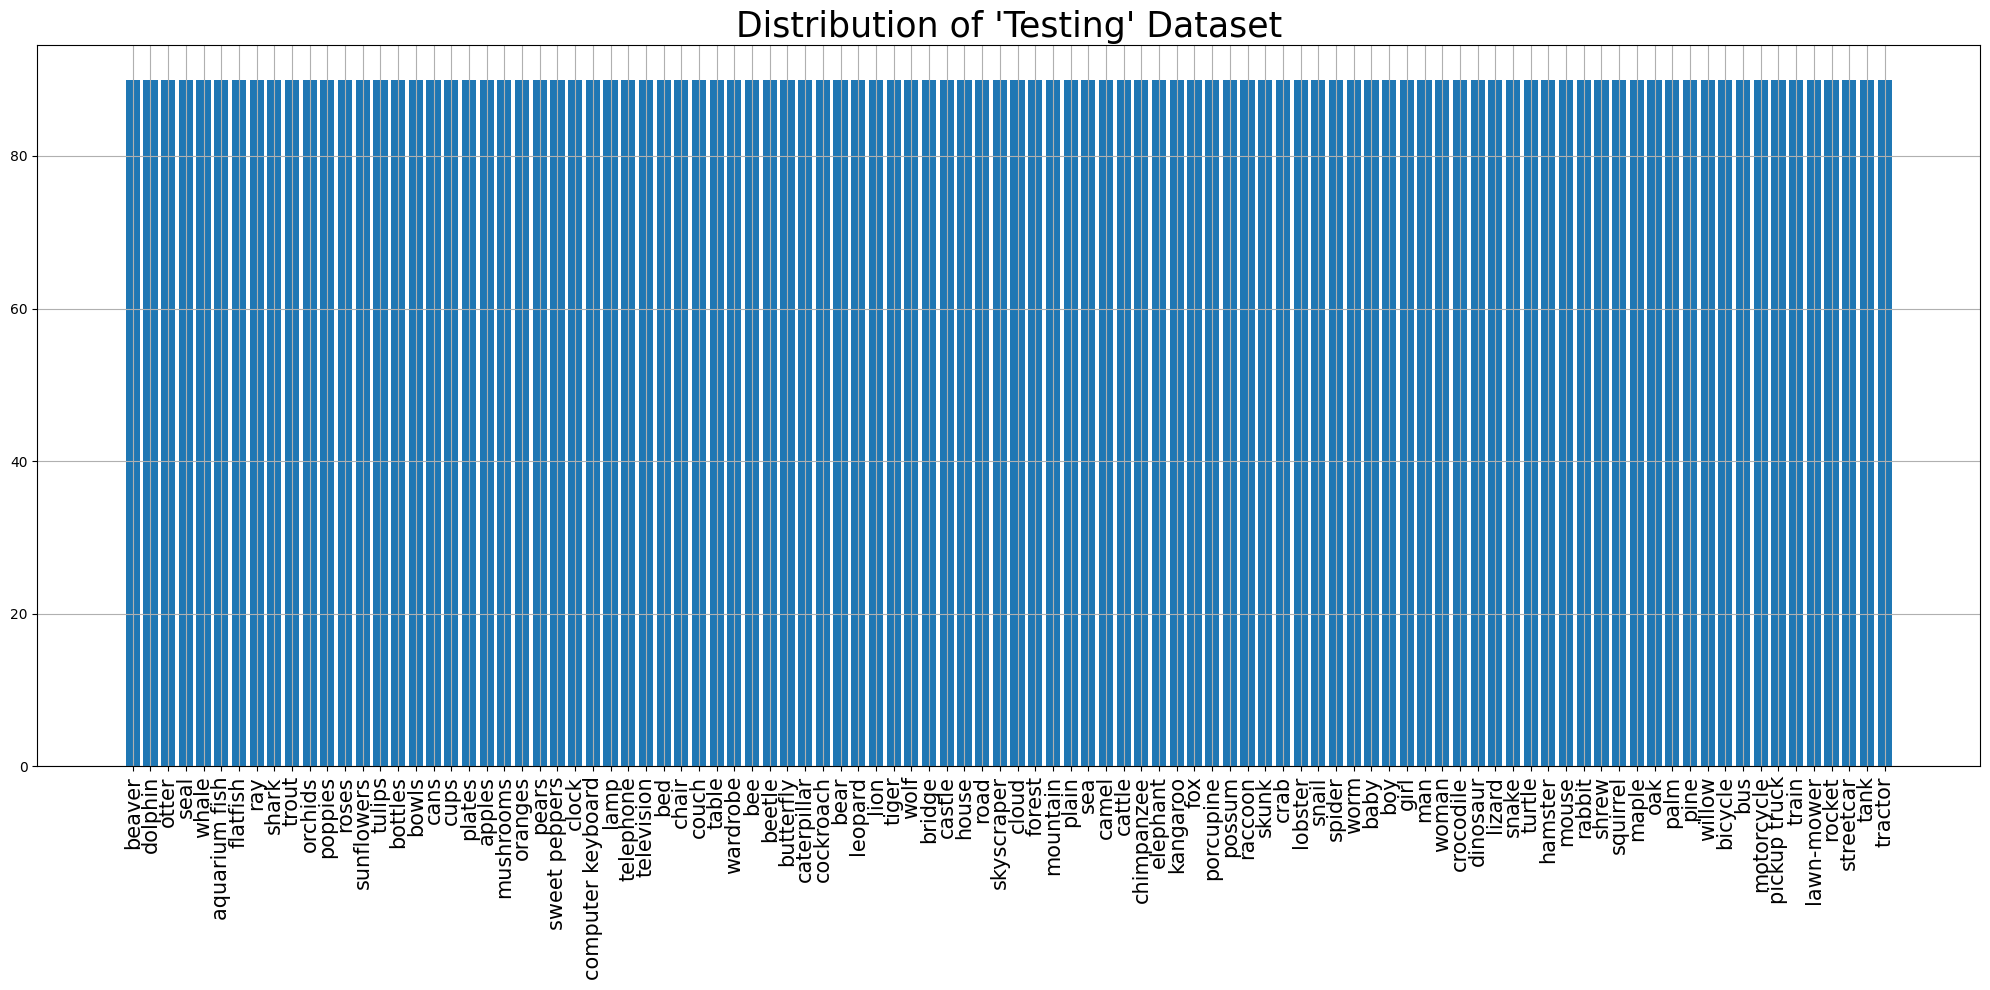

Training dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Validation dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Testing dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)
<class 'tuple'>
2
<class 'tensorflow.python.framework.ops.EagerTensor'> <class 'tensorflow.python.framework.ops.EagerTensor'>
(64, 224, 224, 3)
(64, 100)
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 100)
2
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(64, 224, 224, 3) (6

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet152v2 (Functional)             │ (None, 7, 7, 2048)          │      58,331,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 59,432,036 (226.72 MB)

 Trainable params: 1,100,388 (4.20 MB)

 Non-trainable params: 58,331,648 (222.52 MB)

Epoch 1/25
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4782 - f1_score: 0.4758 - loss: 2.0626 - precision: 0.7510
Epoch 1: val_loss improved from inf to 1.35815, saving model to best_model_v1.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 90s 98ms/step - accuracy: 0.4783 - f1_score: 0.4759 - loss: 2.0619 - precision: 0.7510 - val_accuracy: 0.6156 - val_f1_score: 0.6144 - val_loss: 1.3582 - val_precision: 0.7965 - learning_rate: 0.0010
Epoch 2/25
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6856 - f1_score: 0.6830 - loss: 1.0891 - precision: 0.8379
Epoch 2: val_loss improved from 1.35815 to 1.29781, saving model to best_model_v1.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - accuracy: 0.6857 - f1_score: 0.6831 - loss: 1.0889 - precision: 0.8379 - val_accuracy: 0.6308 - val_f1_score: 0.6308 - val_loss: 1.2978 - val_precision: 0.7858 - learning_rate: 0.0010
Epoch 3/25
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7506 - f1_score: 0.7484 - loss: 0.8669 - precision:

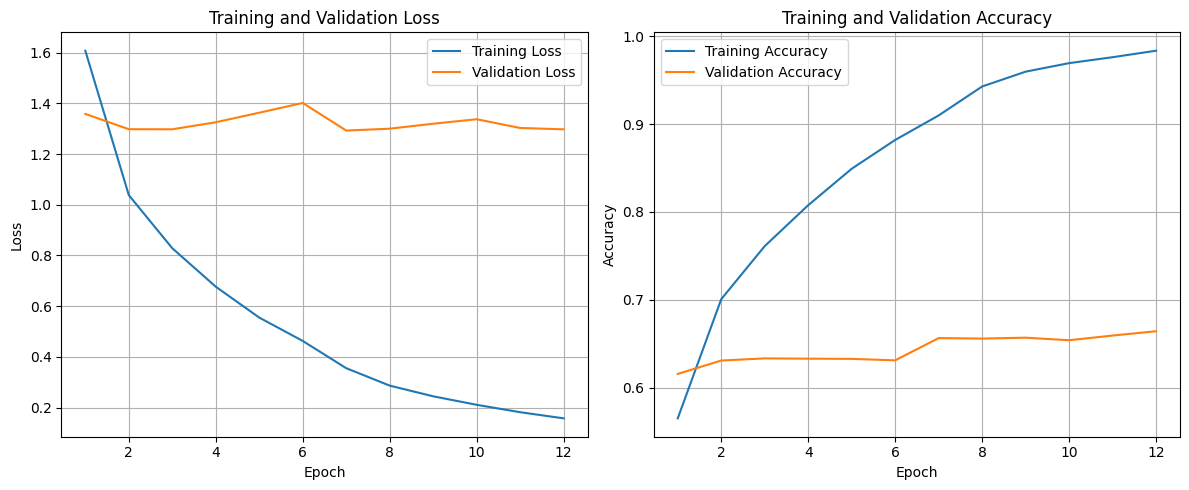

141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.6447 - f1_score: 0.6402 - loss: 1.3076 - precision: 0.7553
Test Accuracy: 65.16%
Test Loss: 1.2872965335845947
Test Precision: 75.81%
Test F1 Scores (Per Class): [81.481476 76.923065 58.959538 52.941174 43.181812 71.73912  61.08374
 69.791664 83.9779   86.904755 58.441555 37.426895 70.58823  45.933006
 68.67469  65.47085  83.060104 70.93597  57.522118 60.869564 80.22598
 74.556206 88.888885 69.565216 78.61271  60.869556 59.459454 44.06779
 81.11111  64.51612  61.146492 64.15094  53.424656 59.40594  64.893616
 43.3121   77.49999  55.752205 51.785706 88.888885 70.17543  86.516846
 60.294117 72.72727  48.67256  53.631275 44.53781  50.209206 83.798874
 78.57142  51.351345 71.16564  61.13989  86.666664 61.428566 34.3949
 73.95833  69.1983   61.068703 47.76119  72.61146  72.82051  65.284966
 68.263466 53.237408 53.88601  71.345024 60.24096  82.608696 84.57142
 58.291454 72.641495 45.398766 59.259254 39.999996 80.85106  79.28994
 68.539

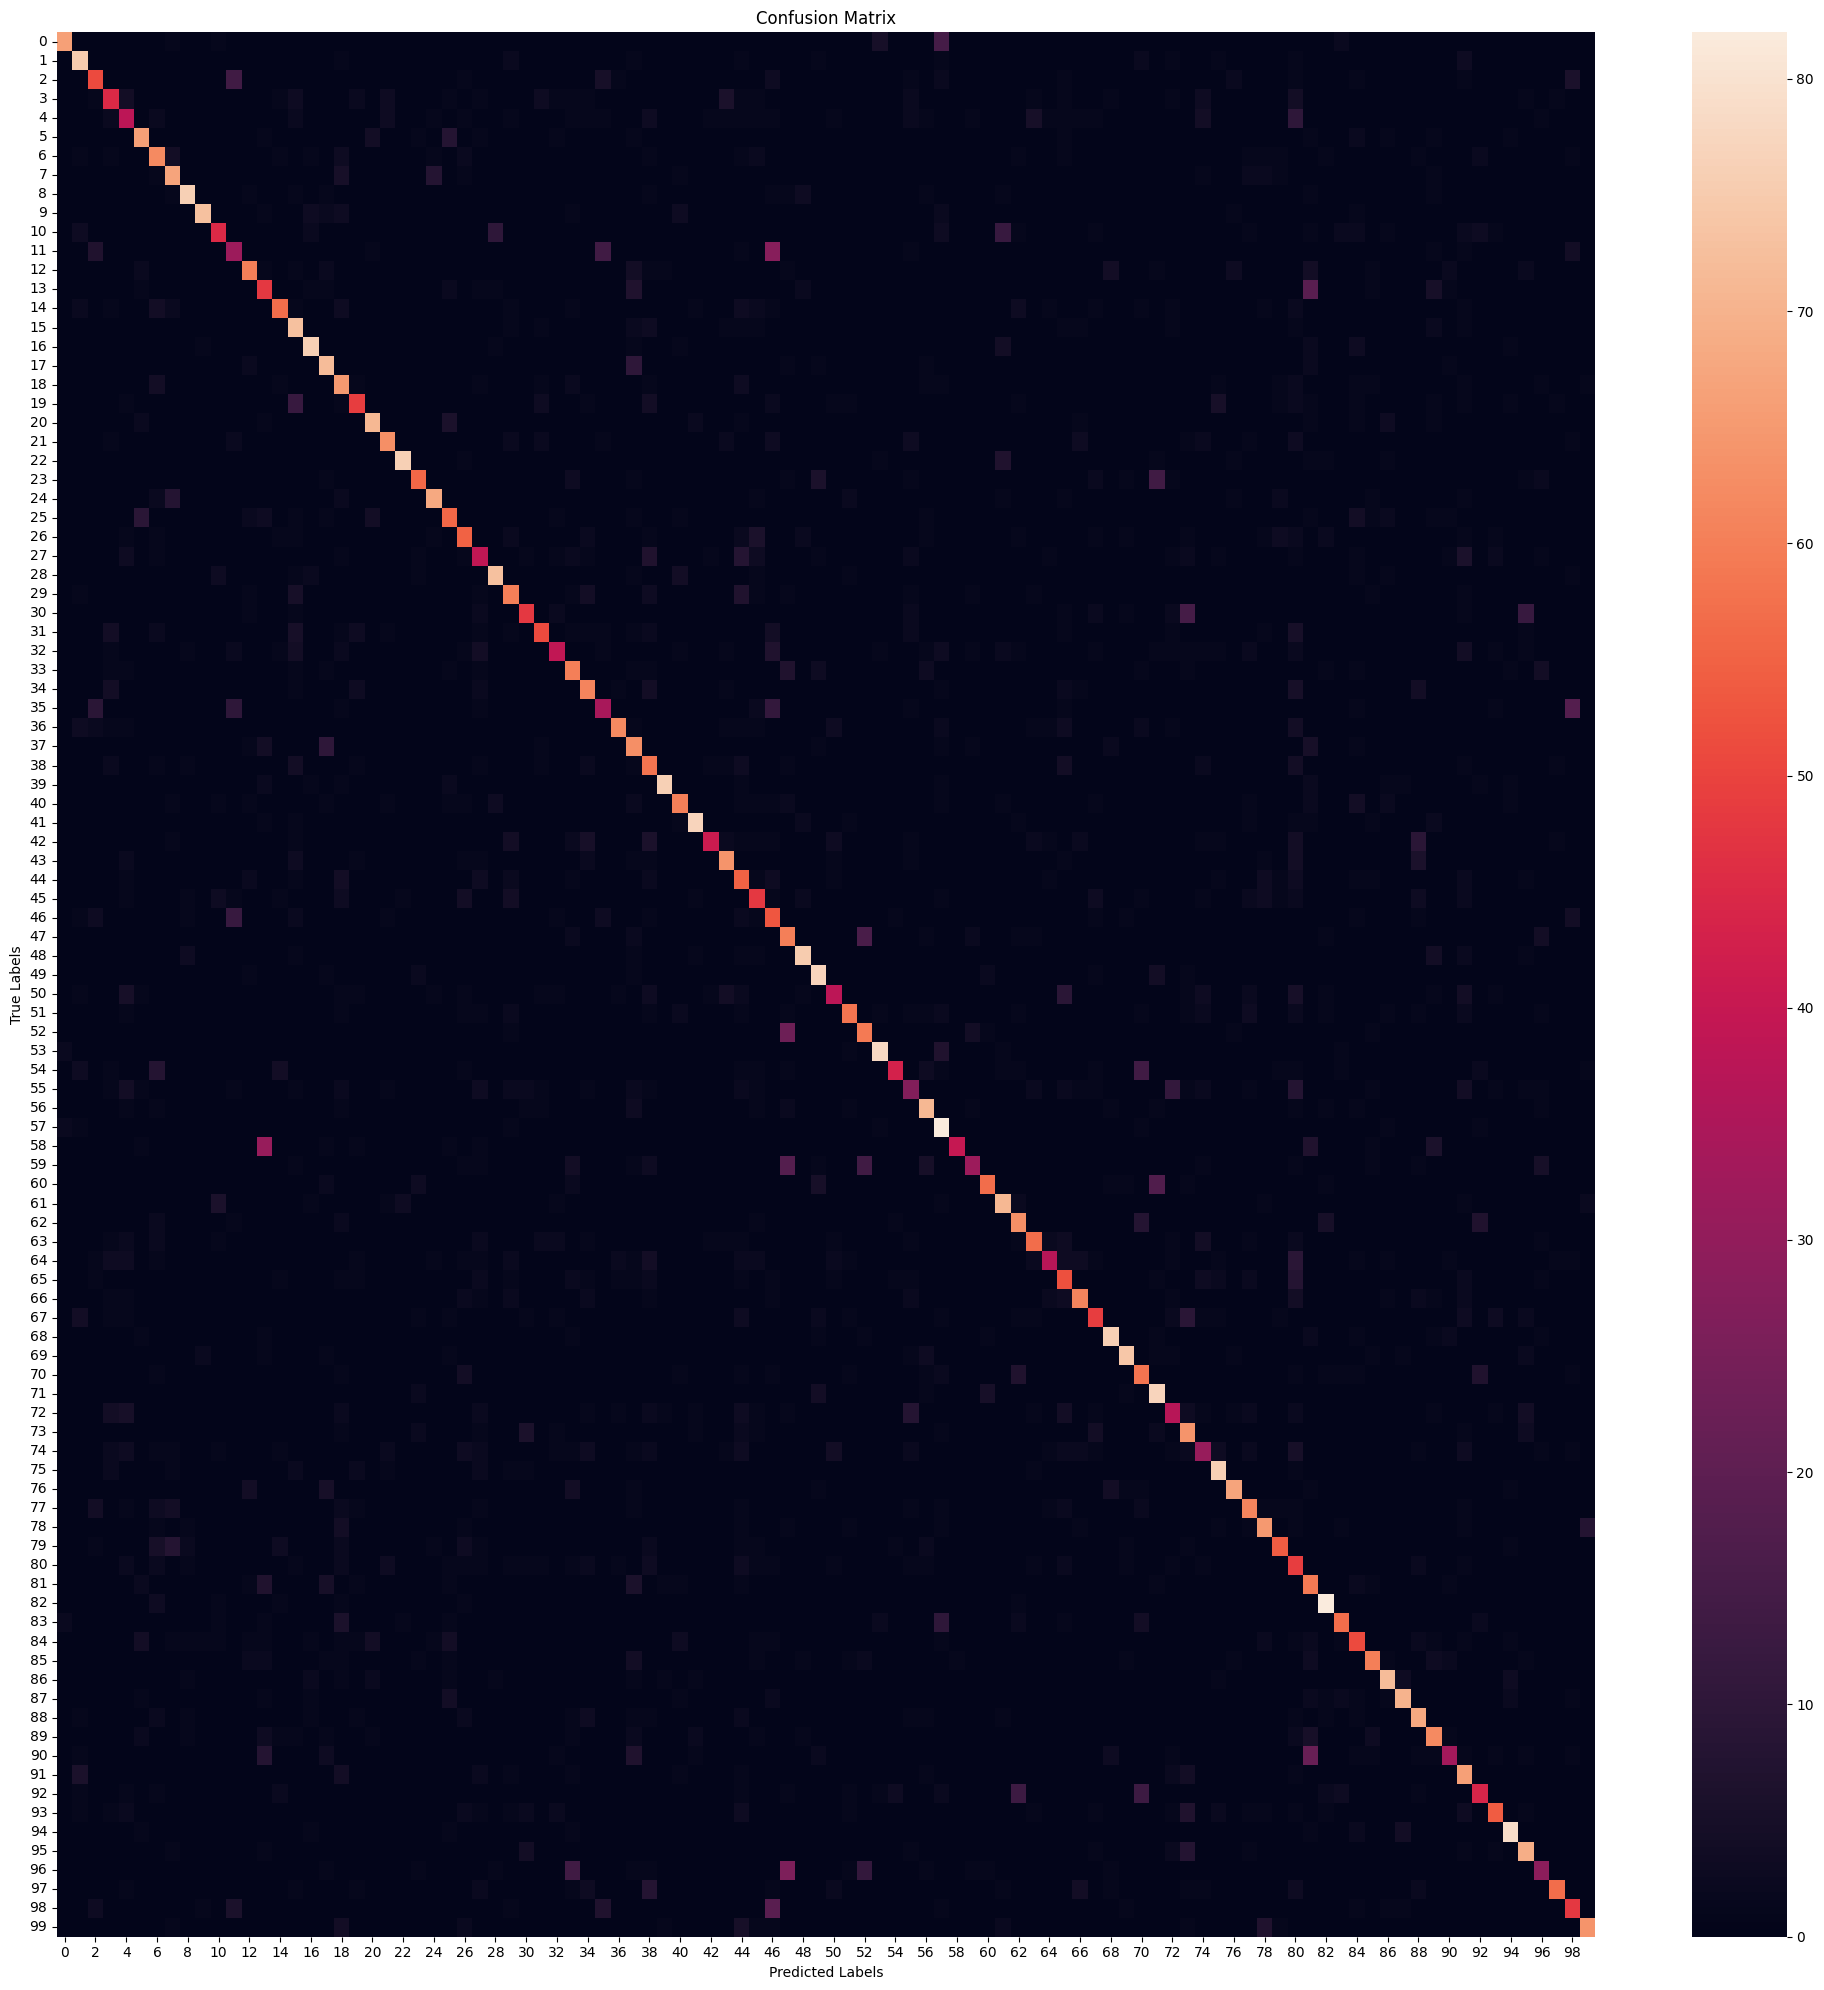

                   precision    recall  f1-score   support

           beaver       0.92      0.73      0.81        90
          dolphin       0.71      0.83      0.77        90
            otter       0.61      0.57      0.59        90
             seal       0.56      0.50      0.53        90
            whale       0.44      0.42      0.43        90
    aquarium fish       0.70      0.73      0.72        90
         flatfish       0.55      0.69      0.61        90
              ray       0.66      0.74      0.70        90
            shark       0.84      0.84      0.84        90
            trout       0.94      0.81      0.87        90
          orchids       0.70      0.50      0.58        90
          poppies       0.40      0.36      0.37        90
            roses       0.75      0.67      0.71        90
       sunflowers       0.40      0.53      0.46        90
           tulips       0.75      0.63      0.69        90
          bottles       0.55      0.81      0.65       

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet152v2 (Functional)             │ (None, 7, 7, 2048)          │      58,331,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 59,432,036 (226.72 MB)

 Trainable params: 1,100,388 (4.20 MB)

 Non-trainable params: 58,331,648 (222.52 MB)

Epoch 1/15
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8988 - f1_score: 0.8982 - loss: 0.3707 - precision: 0.9515
Epoch 1: val_loss improved from inf to 1.19345, saving model to best_model_fine_tune_v1.keras
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 127s 77ms/step - accuracy: 0.8988 - f1_score: 0.8982 - loss: 0.3708 - precision: 0.9515 - val_accuracy: 0.6772 - val_f1_score: 0.6760 - val_loss: 1.1934 - val_precision: 0.7836 - learning_rate: 1.0000e-05
Epoch 2/15
1313/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9217 - f1_score: 0.9210 - loss: 0.3152 - precision: 0.9649
Epoch 2: val_loss improved from 1.19345 to 1.18745, saving model to best_model_fine_tune_v1.keras
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 80s 61ms/step - accuracy: 0.9217 - f1_score: 0.9209 - loss: 0.3152 - precision: 0.9649 - val_accuracy: 0.6797 - val_f1_score: 0.6783 - val_loss: 1.1874 - val_precision: 0.7827 - learning_rate: 1.0000e-05
Epoch 3/15
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9290 - f1_sc

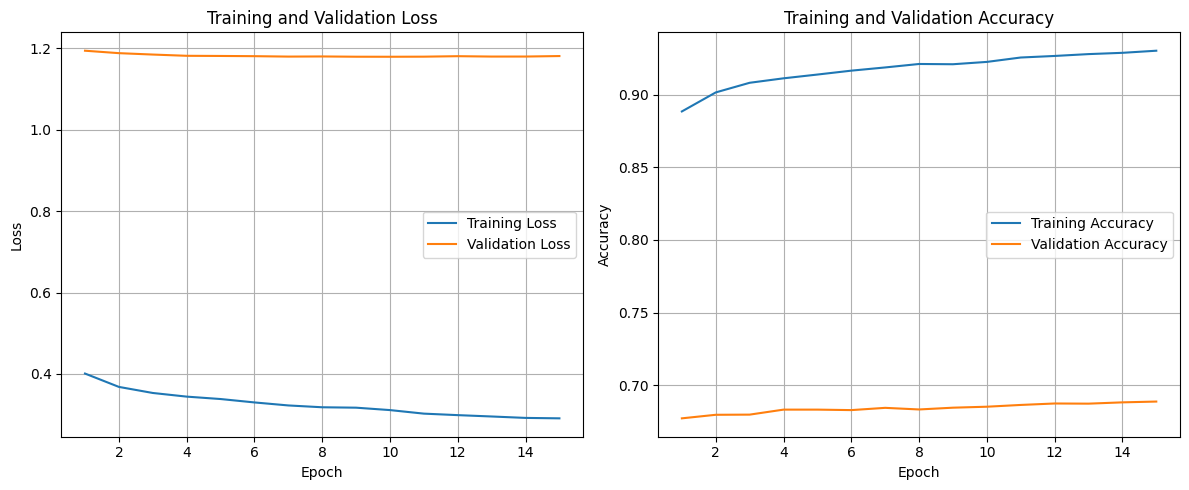

141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.6732 - f1_score: 0.6660 - loss: 1.2033 - precision: 0.7724
Test Accuracy: 68.09%
Test Loss: 1.1775946617126465
Test Precision: 78.06%
Test F1 Scores (Per Class): [83.615814 80.41236  59.550552 53.93258  39.779003 72.72727  69.84126
 72.92817  86.36363  88.76403  64.40677  42.857136 70.39106  51.933693
 70.303024 72.52747  79.787224 81.08108  66.666664 64.739876 79.79274
 75.675674 87.15083  75.428566 79.99999  64.44444  59.66851  48.863632
 83.42856  65.93406  60.919537 63.5838   56.6265   62.032085 68.53932
 44.943817 79.069756 64.51612  58.24175  89.534874 71.276596 83.15788
 61.797745 72.63157  51.813465 54.64481  56.32183  53.48836  85.56149
 78.78787  54.54545  71.03825  68.74999  86.910995 69.94535  34.28571
 74.4186   77.08333  77.21518  59.770107 75.14451  74.28571  68.926544
 67.796616 51.190464 55.319138 72.83237  60.109283 84.946236 81.481476
 64.83515  74.59459  43.093918 67.02127  42.857136 84.26965  81.35593
 69.662

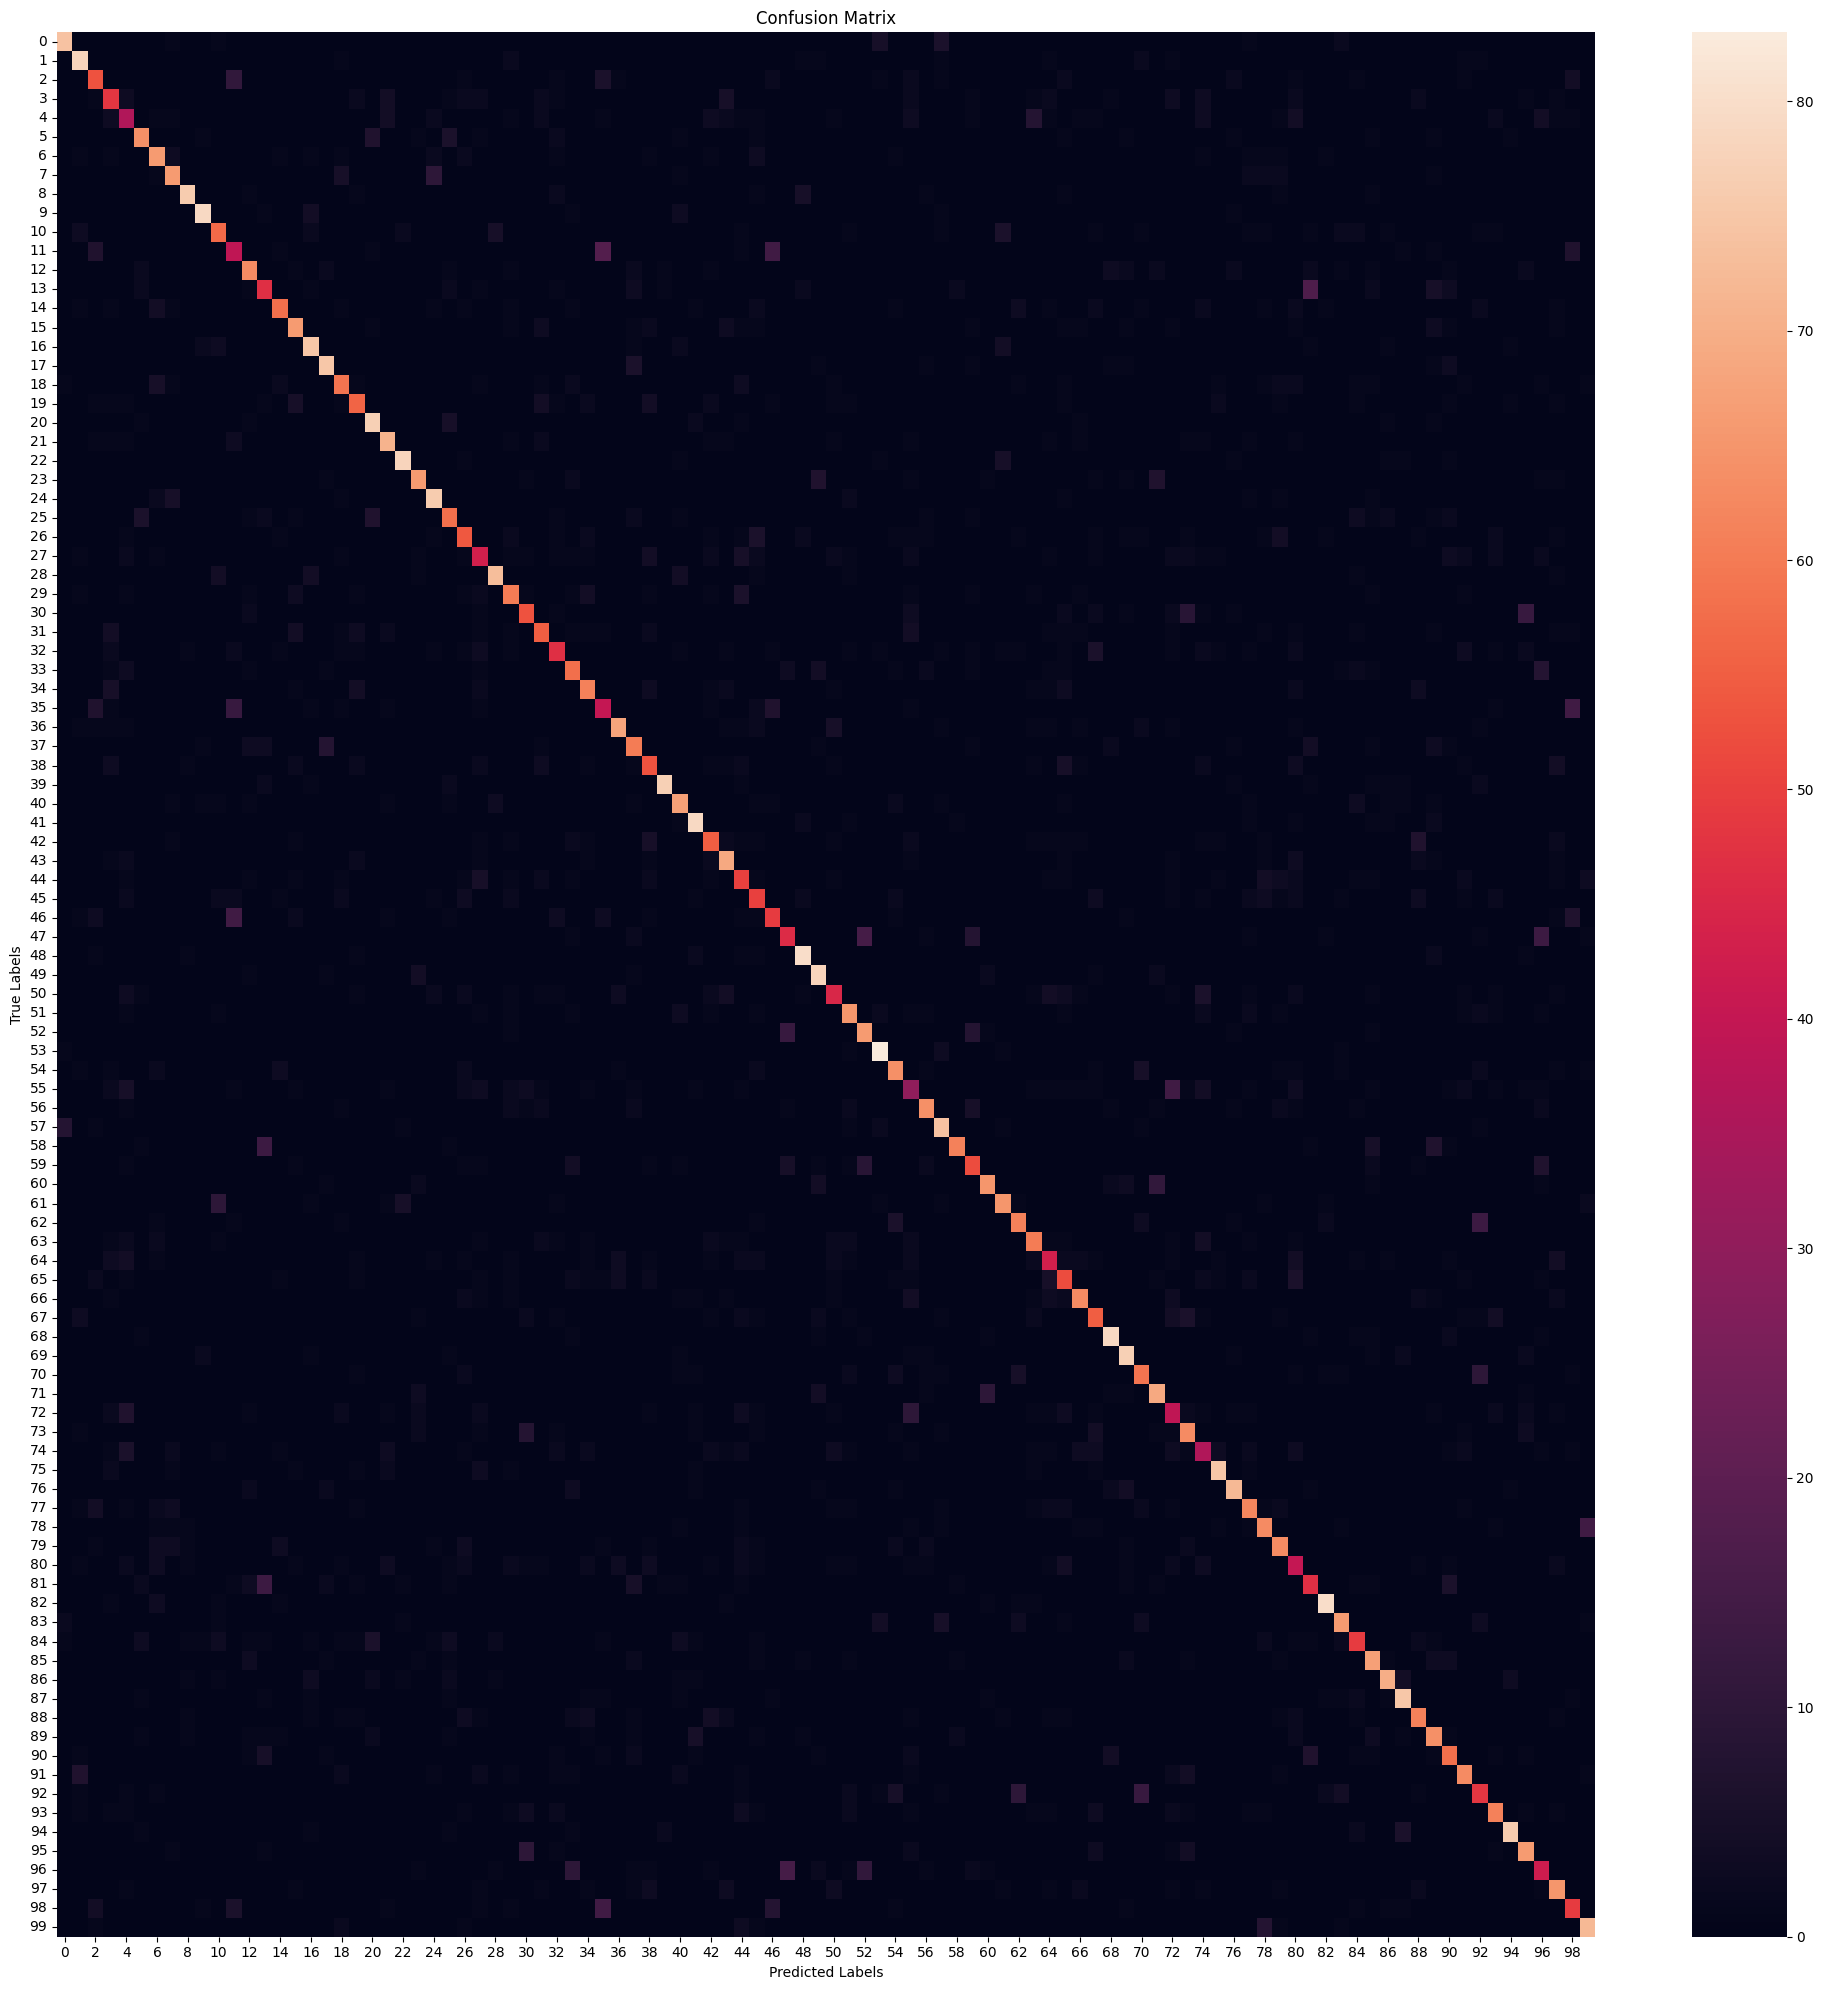

                   precision    recall  f1-score   support

           beaver       0.85      0.82      0.84        90
          dolphin       0.75      0.87      0.80        90
            otter       0.60      0.59      0.60        90
             seal       0.55      0.53      0.54        90
            whale       0.40      0.40      0.40        90
    aquarium fish       0.74      0.71      0.73        90
         flatfish       0.67      0.73      0.70        90
              ray       0.73      0.73      0.73        90
            shark       0.88      0.84      0.86        90
            trout       0.90      0.88      0.89        90
          orchids       0.66      0.63      0.64        90
          poppies       0.42      0.43      0.43        90
            roses       0.71      0.70      0.70        90
       sunflowers       0.52      0.52      0.52        90
           tulips       0.77      0.64      0.70        90
          bottles       0.72      0.73      0.73       

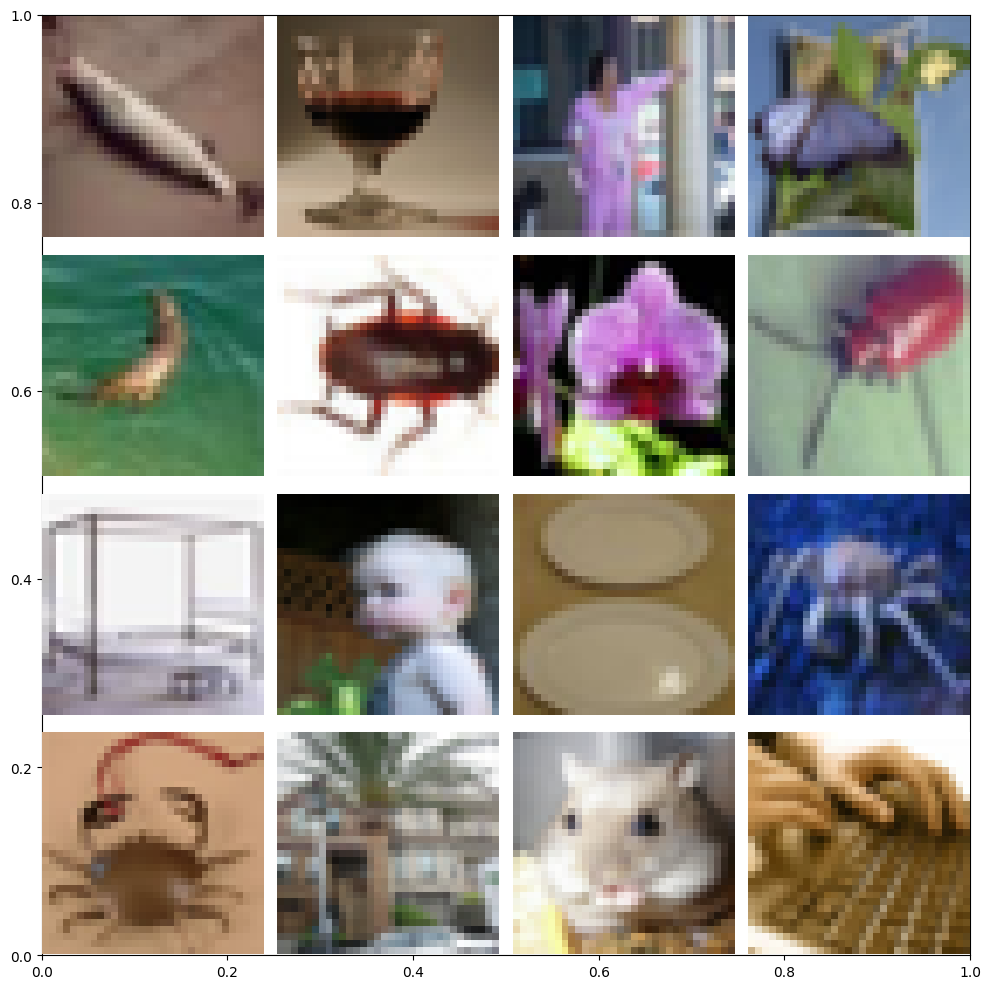

labels[40043].shape: (1,)
imgs[40043].shape: (32, 32, 3)


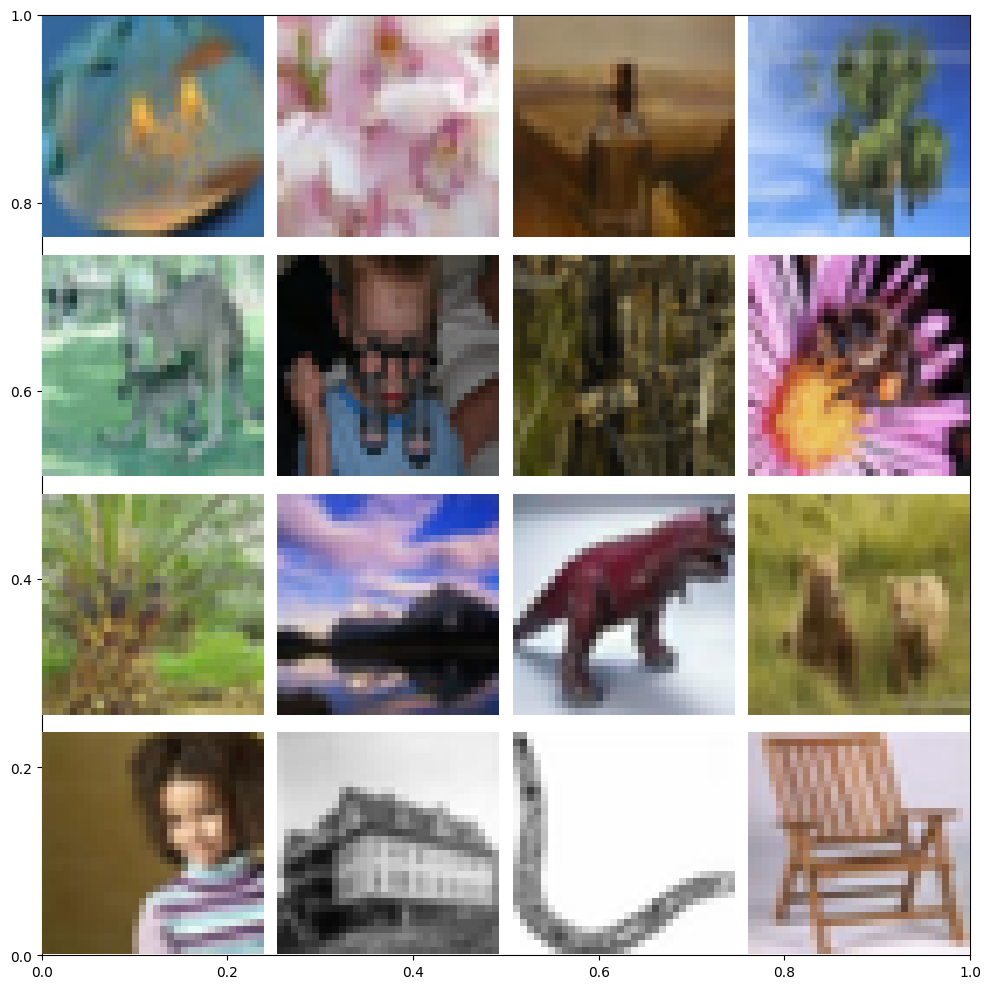

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


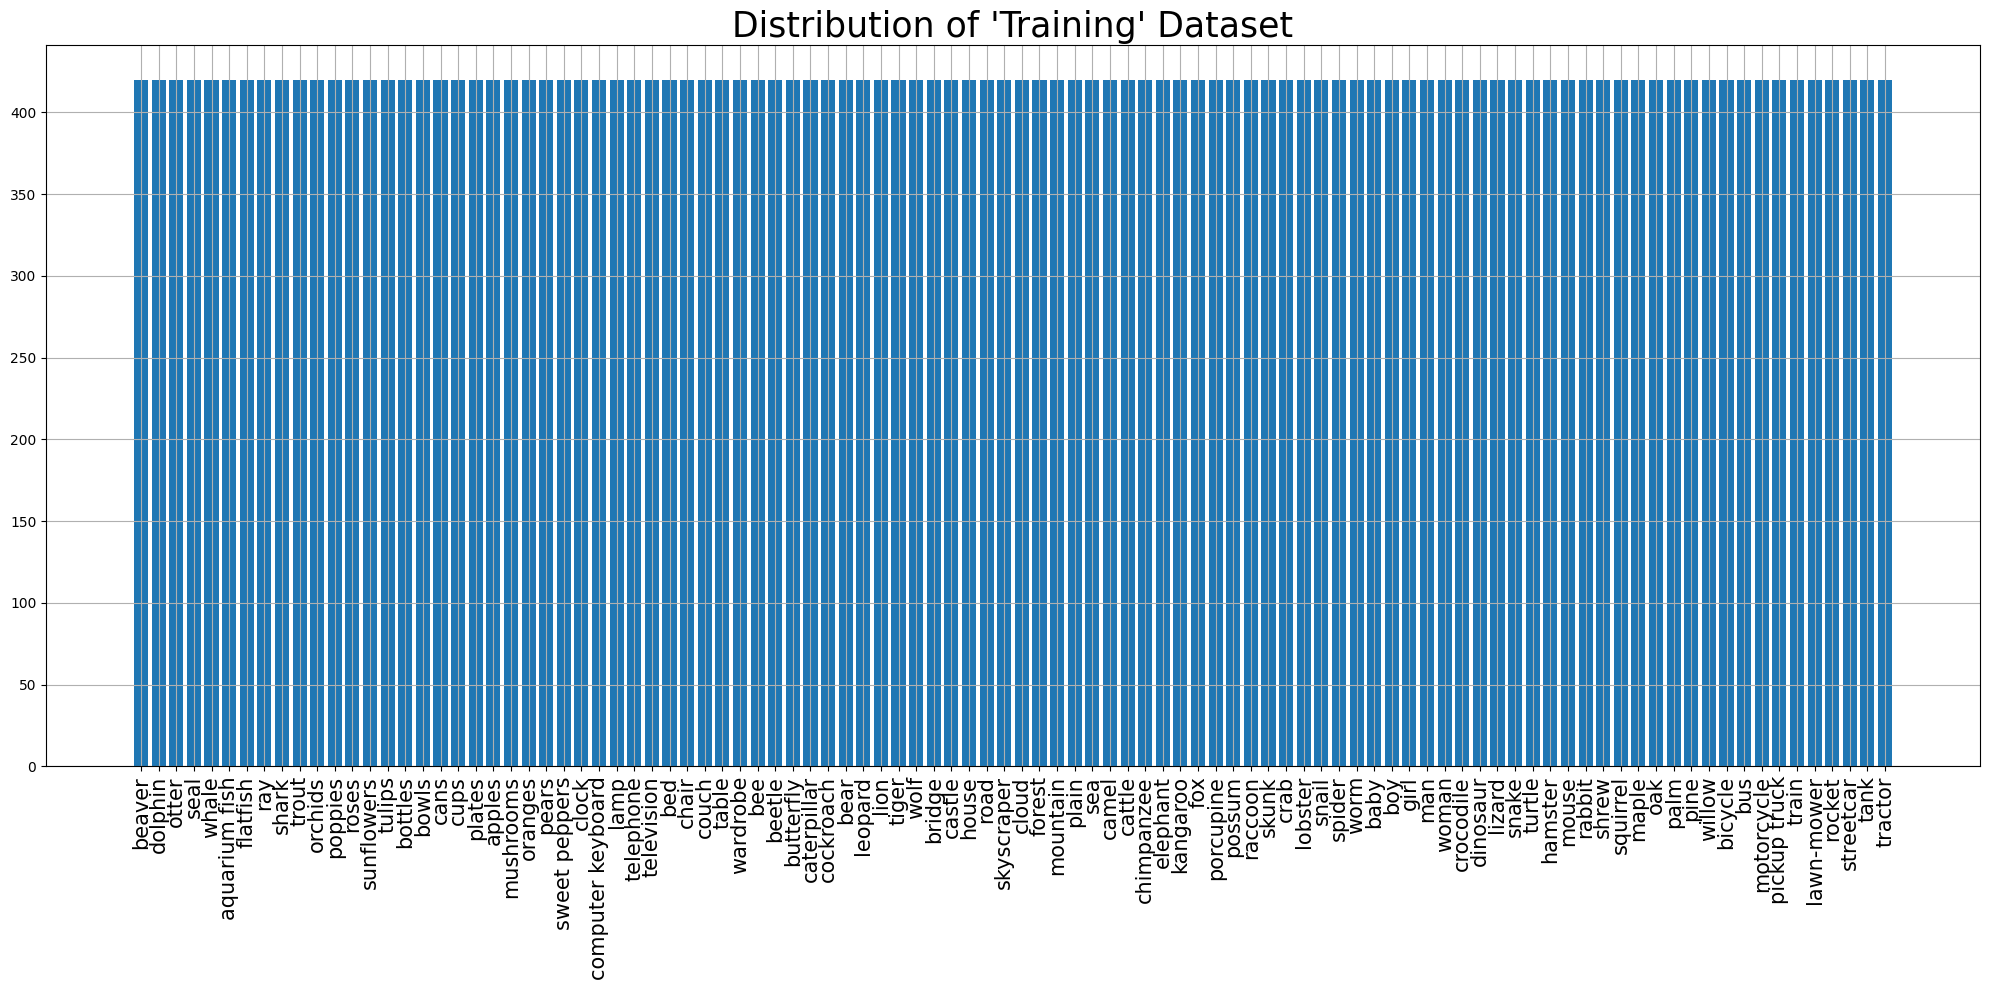

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


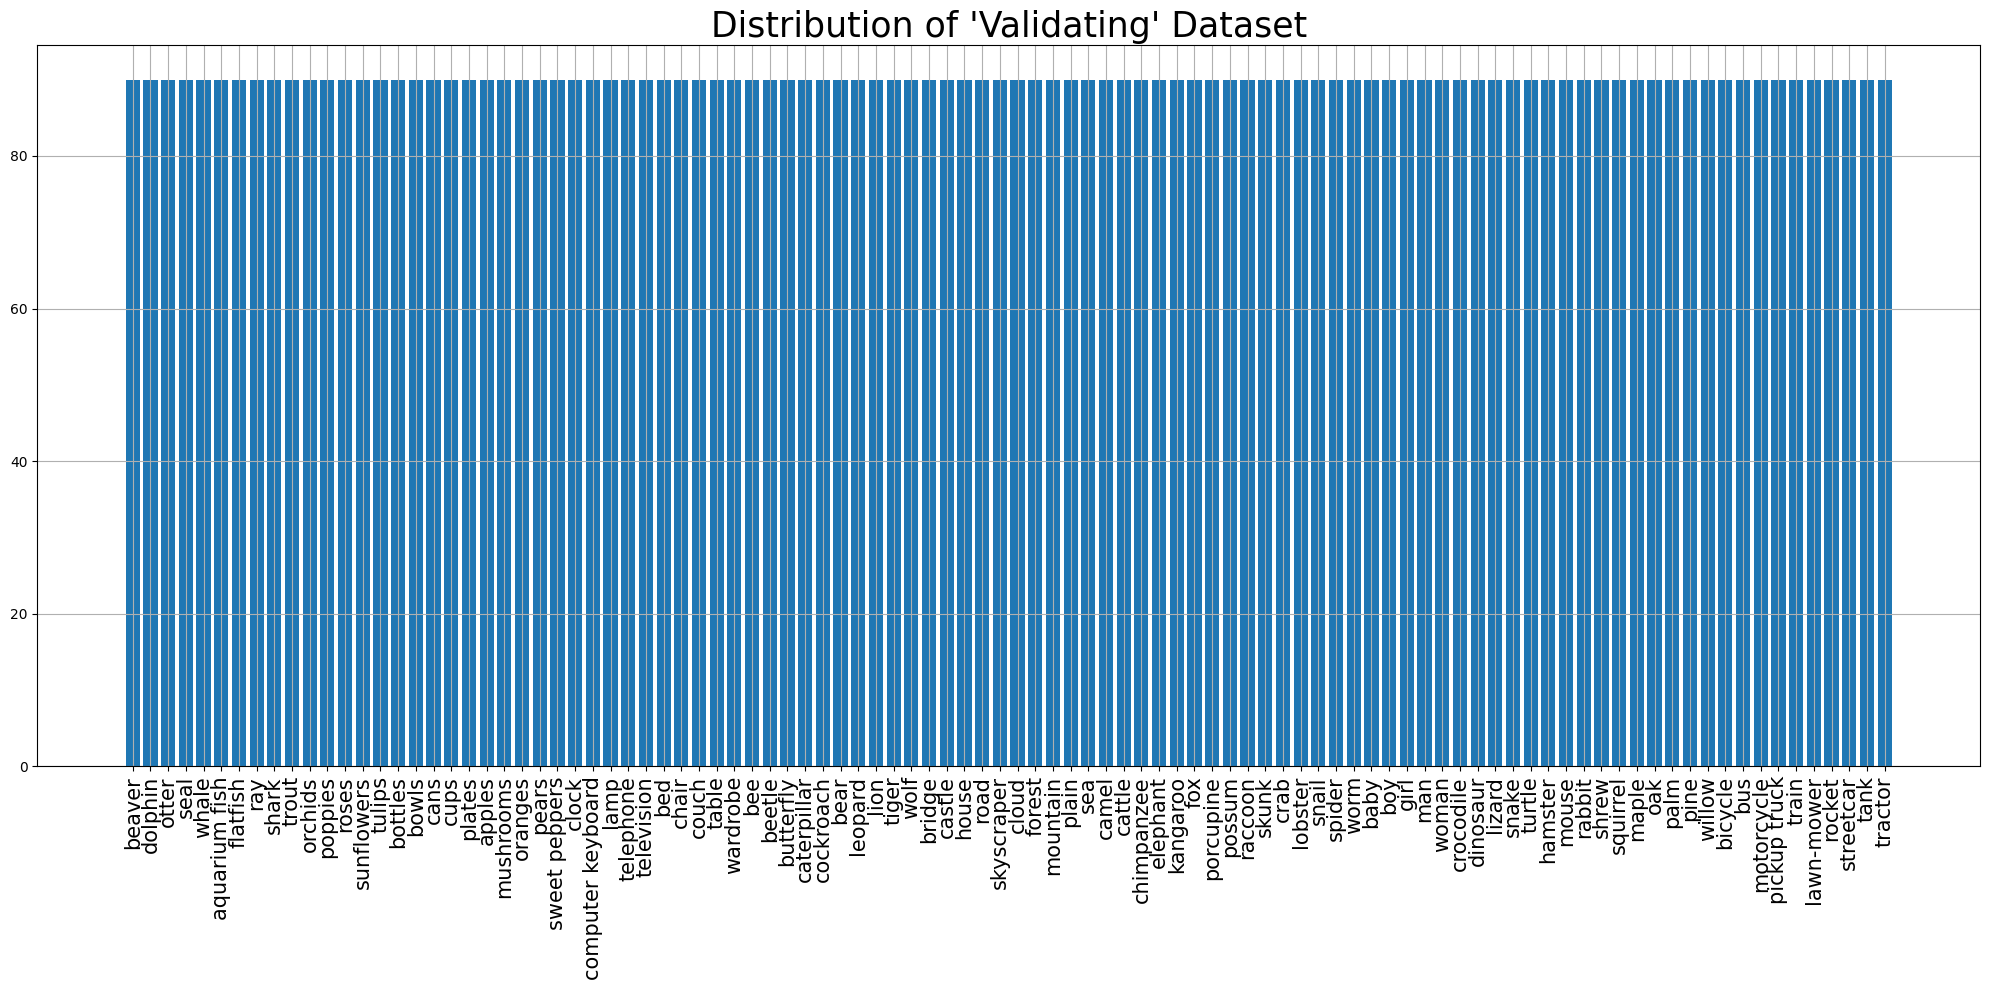

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


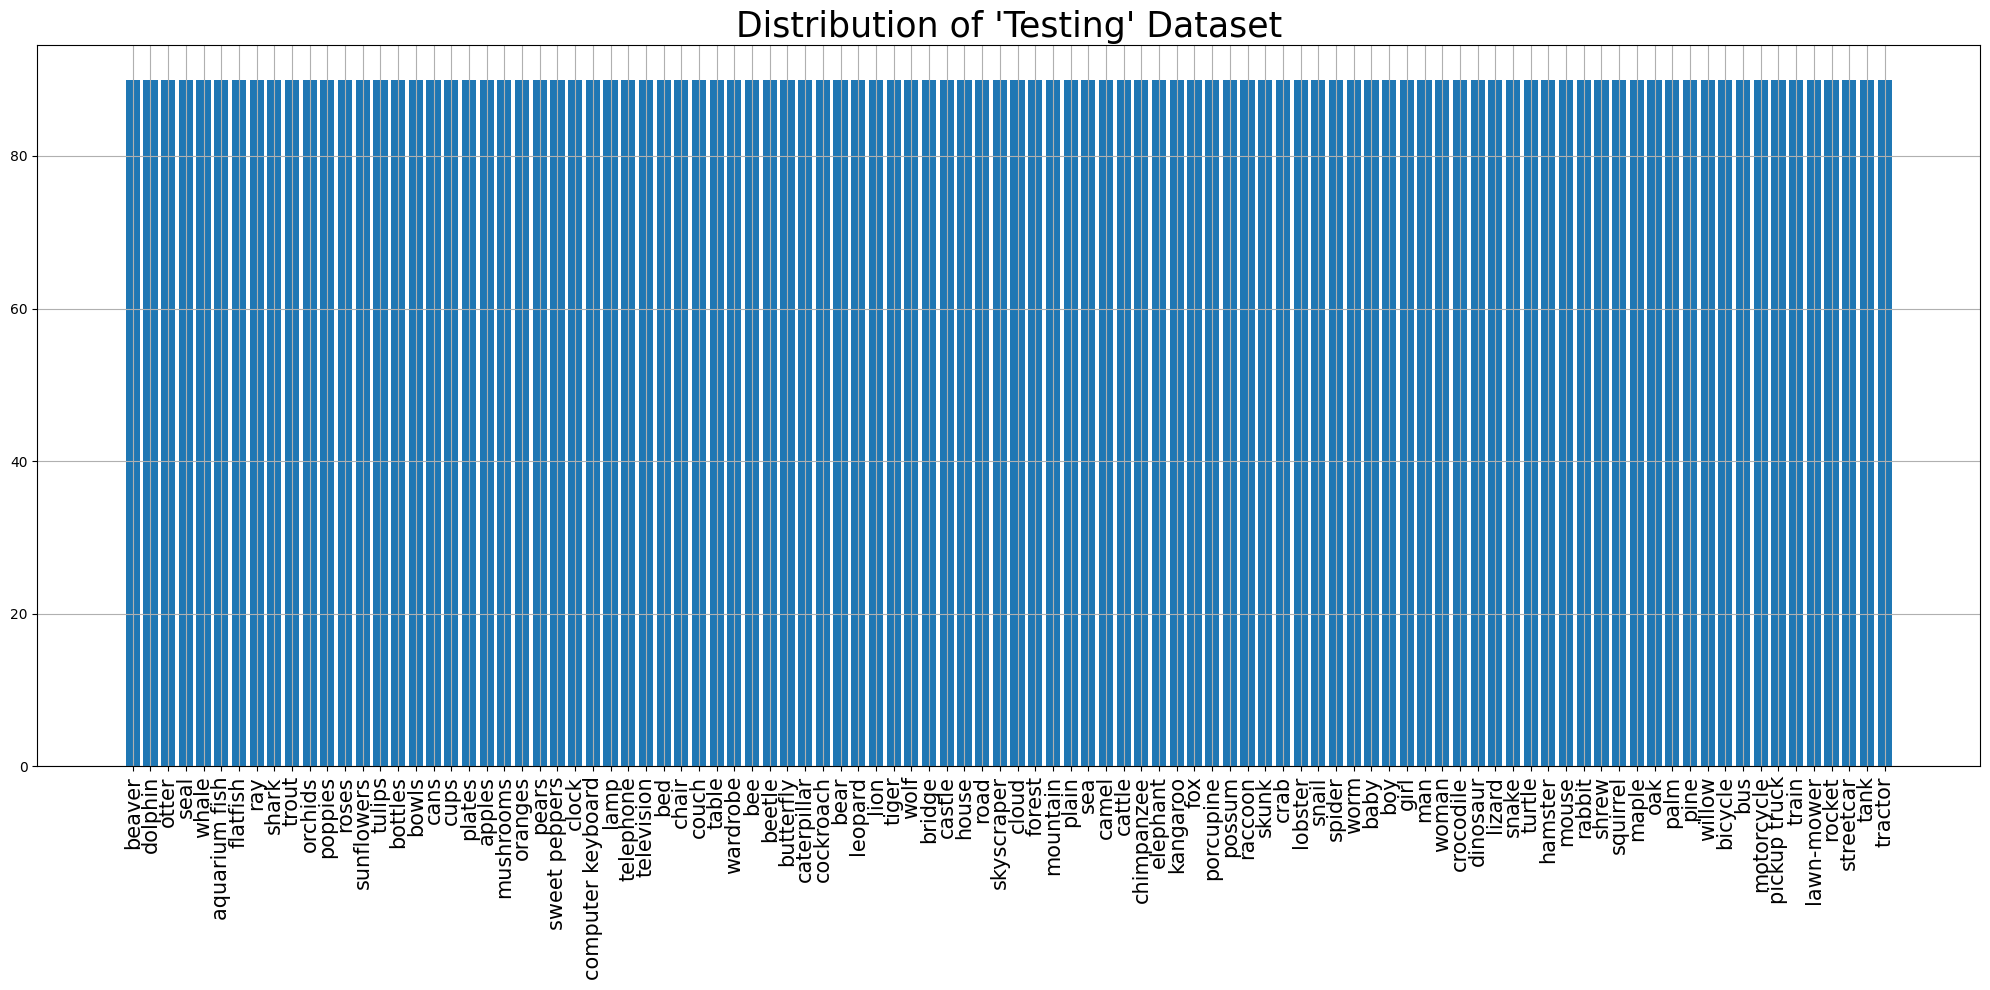

Training dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Validation dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Testing dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)


KeyboardInterrupt: 

In [6]:
for repeat_2_times in range(2):
    #### <<<<<<<<<<Load and process data>>>>>>>>>>
    # Load CIFAR-100 dataset
    (X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode='fine')

    X_temp, X_train, y_temp, y_train = train_test_split(X_train, y_train, test_size=0.84, stratify=y_train, random_state=42)
    print(f"X_temp.shape: {X_temp.shape}\n")

    # Split temp data into equal validation (4000) and testing (4000) data
    X_temp_val, X_temp_test, y_temp_val, y_temp_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
    print(f"X_temp_val.shape: {X_temp_val.shape}")
    print(f"y_temp_val.shape: {y_temp_val.shape}")
    print(f"X_temp_test.shape: {X_temp_test.shape}")
    print(f"y_temp_test.shape: {y_temp_test.shape}\n")

    # Split test data into validation (5000) and testing (5000)
    X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=42)

    # Add temp_val to validation (9000) and temp_test to testing (9000) to get a 70/15/15 data split
    X_val = np.concatenate((X_val, X_temp_val), axis=0)
    y_val = np.concatenate((y_val, y_temp_val), axis=0)
    X_test = np.concatenate((X_test, X_temp_test), axis=0)
    y_test = np.concatenate((y_test, y_temp_test), axis=0)

    print(f"X_train.shape: {X_train.shape}")
    print(f"y_train.shape: {y_train.shape}")
    print(f"X_val.shape: {X_val.shape}")
    print(f"y_val.shape: {y_val.shape}")
    print(f"X_test.shape: {X_test.shape}")
    print(f"y_test.shape: {y_test.shape}\n")

    display_imgs(X_train, y_train)

    # Normalise images (scale to range [0, 1]) - Improves convergence speed & accuracy
    X_train, X_val, X_test = X_train / 255.0, X_val / 255.0, X_test / 255.0
    display_imgs(X_train, y_train)

    labels_names = ['beaver','dolphin','otter','seal','whale','aquarium fish','flatfish','ray','shark','trout',
                   'orchids','poppies','roses','sunflowers','tulips','bottles','bowls','cans','cups','plates',
                   'apples','mushrooms','oranges','pears','sweet peppers','clock','computer keyboard','lamp',
                   'telephone','television','bed','chair','couch','table','wardrobe','bee','beetle','butterfly',
                   'caterpillar','cockroach','bear','leopard','lion','tiger','wolf','bridge','castle','house',
                   'road','skyscraper','cloud','forest','mountain','plain','sea','camel','cattle','chimpanzee',
                   'elephant','kangaroo','fox','porcupine','possum','raccoon','skunk','crab','lobster','snail',
                   'spider','worm','baby','boy','girl','man','woman','crocodile','dinosaur','lizard','snake',
                   'turtle','hamster','mouse','rabbit','shrew','squirrel','maple','oak','palm','pine','willow',
                   'bicycle','bus','motorcycle','pickup truck','train','lawn-mower','rocket','streetcar','tank',
                   'tractor']

    class_distrib(y_train, labels_names, "Training")
    class_distrib(y_val, labels_names, "Validating")
    class_distrib(y_test, labels_names, "Testing")

    # Create TensorFlow datasets

    batch_size = 64

    train_dataset_ = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
                     .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                        tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
                     .batch(batch_size)
                     .prefetch(tf.data.experimental.AUTOTUNE))

    # DEBUG augment
    #train_dataset_aug = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
    #                 .map(augment_dataset, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    #                 .batch(batch_size)
    #                 .prefetch(tf.data.experimental.AUTOTUNE))

    # Combine the original dataset and the augmented dataset
    train_dataset = train_dataset_#.concatenate(train_dataset_aug)

    val_dataset = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
                   .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                      tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
                   .batch(batch_size)
                   .prefetch(tf.data.experimental.AUTOTUNE))

    test_dataset = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
                     .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                        tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
                    .batch(batch_size)
                    .prefetch(tf.data.experimental.AUTOTUNE))

    print(f"Training dataset:\n {train_dataset}")
    for img, lbl in train_dataset.take(1):
        #if isinstance(batch, tuple) and len(batch) == 2:
        print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
        print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
        del img,lbl
    print(f"\nValidation dataset:\n {val_dataset}")
    for img, lbl in val_dataset.take(1):
        #if isinstance(batch, tuple) and len(batch) == 2:
        print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
        print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
        del img,lbl
    print(f"\nTesting dataset:\n {test_dataset}")
    for img, lbl in test_dataset.take(1):
        #if isinstance(batch, tuple) and len(batch) == 2:
        print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
        print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
        del img,lbl


    #### <<<<<<<<<<Pre-trained model>>>>>>>>>>
    # Load ResNet50 pre-trained on ImageNet (w/out the top classification layer which is designed for ImageNet (diff dataset))
    resnet_50_base = tf.keras.applications.ResNet152V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Freeze the layers of VGG16 so they don't get updated during training - can unfreeze for fine tuning later
    resnet_50_base.trainable = False

    for layer in resnet_50_base.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            layer.kernel_regularizer = tf.keras.regularizers.l2(3e-1) # DEBUG l2

    # Add custom classification layers for CIFAR-100 (100 classes) - adapt model to CIFAR-100
    model = models.Sequential([
        resnet_50_base,
        layers.GlobalAveragePooling2D(), # Better for ResNet than Flatten
        layers.Dense(512, activation='relu'),
        layers.Dense(100, activation='softmax')  # CIFAR-100 has 100 classes
    ])

    for sample in test_dataset.take(1):
        print(type(sample))  # Should be <class 'tuple'>
        print(len(sample))  # Should be 2
        print(type(sample[0]), type(sample[1]))  # Both should be <class 'tensorflow.Tensor'>
        print(sample[0].shape)  # Should be (batch_size, 224, 224, 3)
        print(sample[1].shape)  # Should be (batch_size, 100)
    print(f"Model input shape: {model.input_shape}")
    print(f"Model output shape: {model.output_shape}")
    sample = next(iter(test_dataset.as_numpy_iterator()))
    print(len(sample))  # Should be 2
    print(type(sample[0]), type(sample[1]))  # Both should be <class 'numpy.ndarray'>
    print(sample[0].shape, sample[1].shape)  # Should match model input and output
    print("\n")
    #for x, y in test_dataset.take(1):
    #    print(type(x), type(y))  # Both should be <class 'tensorflow.Tensor'>
    #for x_batch, y_batch in test_dataset.take(1):
    #    test_loss, test_acc = model.evaluate(x_batch, y_batch)
    #    print(f"Test Loss: {test_loss}, Test Accuracy: {test_acc}")

    # Compile the model
    #tensorboard_callback = keras.callbacks.TensorBoard(log_dir="./logs")
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3, weight_decay=3e-1), # DEBUG weight
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 'precision', 'f1_score'])

    model.summary()

    #### <<<<<<<<<<Train Model & Track Training/Validation Error>>>>>>>>>>
    early_stopping = EarlyStopping(monitor='val_loss', # or val_accuracy
                                   patience=5, # Num. epochs with no improvements - help void overfitting
                                   restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', # or val_accuracy
                                  factor=0.5, # Reduce lr by a factor
                                  patience=3, # Num epochs w/ no improvement
                                  min_lr=1e-6, # Min lr
                                  verbose=1)
    #tensorboard = TensorBoard(log_dir='./logs', # Logs directory
    #                         histogram_freq=1, # Logs histograms for weights/activations
    #                         write_graph=True, # Logs graph of model
    #                         write_images=True) # Log images like weight histogram
    checkpoint = ModelCheckpoint('best_model_v1.keras', # Path where the best model will be saved
                                 monitor='val_loss', # What to monitor (validation loss)
                                 save_best_only=True, # Only save model when validation loss improves
                                 mode='min', # Looking to minimse the validation loss
                                 verbose=1) # Print out message when saving model
    checkpoint_fine_tune = ModelCheckpoint('best_model_fine_tune_v1.keras', # Path where the best model will be saved
                                 monitor='val_loss', # What to monitor (validation loss)
                                 save_best_only=True, # Only save model when validation loss improves
                                 mode='min', # Looking to minimse the validation loss
                                 verbose=1) # Print out message when saving model
    #cvs_logger = CSVLogger('training_log.csv', seperator=',', append=True) # Save train metrics to analyse

    # Train the model
    history = model.fit(train_dataset, validation_data=val_dataset, epochs=25,
                        batch_size=batch_size, callbacks=[checkpoint, early_stopping, reduce_lr], verbose=1)

    #### <<<<<<<<<<Plot Training & Validation Error>>>>>>>>>>

    # Extract loss and accuracy
    epochs = range(1,len(history.history['loss'])+1)
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    plot_evidence(epochs, train_loss, val_loss, train_acc, val_acc)

    #### <<<<<<<<<<Evaluate Model on Test Data>>>>>>>>>>

    # Evaluate on test data
    model = load_model('best_model_v1.keras')
    results = model.evaluate(test_dataset)
    test_loss = results[0]
    test_acc = results[1]
    test_precision = results[2]
    test_f1_scores = results[3]
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"Test Loss: {test_loss}")
    print(f"Test Precision: {test_precision*100:.2f}%")
    print(f"Test F1 Scores (Per Class): {test_f1_scores.numpy()*100}")
    print(f"Average Test F1 Scores:{np.average(test_f1_scores.numpy()*100):.2f}\n")

    #### <<<<<<<<<<Generate Confusion Matrix>>>>>>>>>>

    # Get predictions
    X_test_revised = tf.image.resize(X_test, (224, 224))
    y_pred = model.predict(X_test_revised)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = y_test.flatten()

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

    # Plot confusion matrix
    plt.figure(figsize=(20, 20))
    sns.heatmap(conf_matrix) #cmap='Blues', fmt='d'
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true_classes, y_pred_classes, target_names=labels_names))
    #tensorboard --logdir==path_to_your_logs

    # Create a DataFrame from the history of the training and store the epoch values.
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    # Finally, display the hist DataFrame.
    hist

    #### <<<<<<<<<<Fine-Tune>>>>>>>>>>
    # Adapt Model
    for layer in resnet_50_base.layers:
        layer.trainable = True # Allow layers to be updated

    # Compile again w/ lower learning rate (prevents destroying learned features)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 'precision', 'f1_score'])

    model.summary()

    #### <<<<<<<<<<Modify Dataset>>>>>>>>>>


    # DEBUG augment
    train_dataset_aug_ = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
                     .map(augment_dataset, num_parallel_calls=tf.data.experimental.AUTOTUNE)
                     .batch(batch_size)
                     .prefetch(tf.data.experimental.AUTOTUNE))

    # Combine the original dataset and the augmented dataset
    train_dataset_aug = train_dataset.concatenate(train_dataset_aug_) # Not val or test as augment train helps generalise better, but want to provide consistent benchmark for eval perf

    #### <<<<<<<<<<Train Model & Track Training/Validation Error>>>>>>>>>>

    # Train the model
    history_fine_tune = model.fit(train_dataset_aug, validation_data=val_dataset, epochs=15,
                                  batch_size=batch_size, callbacks=[checkpoint_fine_tune, early_stopping, reduce_lr], verbose=1)

    #### <<<<<<<<<<Plot Training & Validation Error>>>>>>>>>>

    # Extract loss and accuracy
    epochs = range(1,len(history_fine_tune.history['loss'])+1)
    train_loss = history_fine_tune.history['loss']
    val_loss = history_fine_tune.history['val_loss']
    train_acc = history_fine_tune.history['accuracy']
    val_acc = history_fine_tune.history['val_accuracy']

    plot_evidence(epochs, train_loss, val_loss, train_acc, val_acc)

    #### <<<<<<<<<<Evaluate Model on Test Data>>>>>>>>>>

    # Evaluate on test data
    model_fine_tune = load_model('best_model_fine_tune_v1.keras')
    results = model_fine_tune.evaluate(test_dataset)
    test_loss = results[0]
    test_acc = results[1]
    test_precision = results[2]
    test_f1_scores = results[3]
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"Test Loss: {test_loss}")
    print(f"Test Precision: {test_precision*100:.2f}%")
    print(f"Test F1 Scores (Per Class): {test_f1_scores.numpy()*100}")
    print(f"Average Test F1 Scores:{np.average(test_f1_scores.numpy()*100):.2f}\n")

    #### <<<<<<<<<<Generate Confusion Matrix>>>>>>>>>>

    # Get predictions
    X_test_revised = tf.image.resize(X_test, (224, 224))
    y_pred = model_fine_tune.predict(X_test_revised)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = y_test.flatten()

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

    # Plot confusion matrix
    plt.figure(figsize=(20, 20))
    sns.heatmap(conf_matrix) #cmap='Blues', fmt='d'
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true_classes, y_pred_classes, target_names=labels_names))

    # Create a DataFrame from the history of the training and store the epoch values.
    hist = pd.DataFrame(history_fine_tune.history)
    hist['epoch'] = history_fine_tune.epoch

    # Finally, display the hist DataFrame.
    hist

# Dropout(0.6), weight_decay(1e-1), l2(1e-1) lr

X_temp.shape: (8000, 32, 32, 3)

X_temp_val.shape: (4000, 32, 32, 3)
y_temp_val.shape: (4000, 1)
X_temp_test.shape: (4000, 32, 32, 3)
y_temp_test.shape: (4000, 1)

X_train.shape: (42000, 32, 32, 3)
y_train.shape: (42000, 1)
X_val.shape: (9000, 32, 32, 3)
y_val.shape: (9000, 1)
X_test.shape: (9000, 32, 32, 3)
y_test.shape: (9000, 1)

labels[32704].shape: (1,)
imgs[32704].shape: (32, 32, 3)


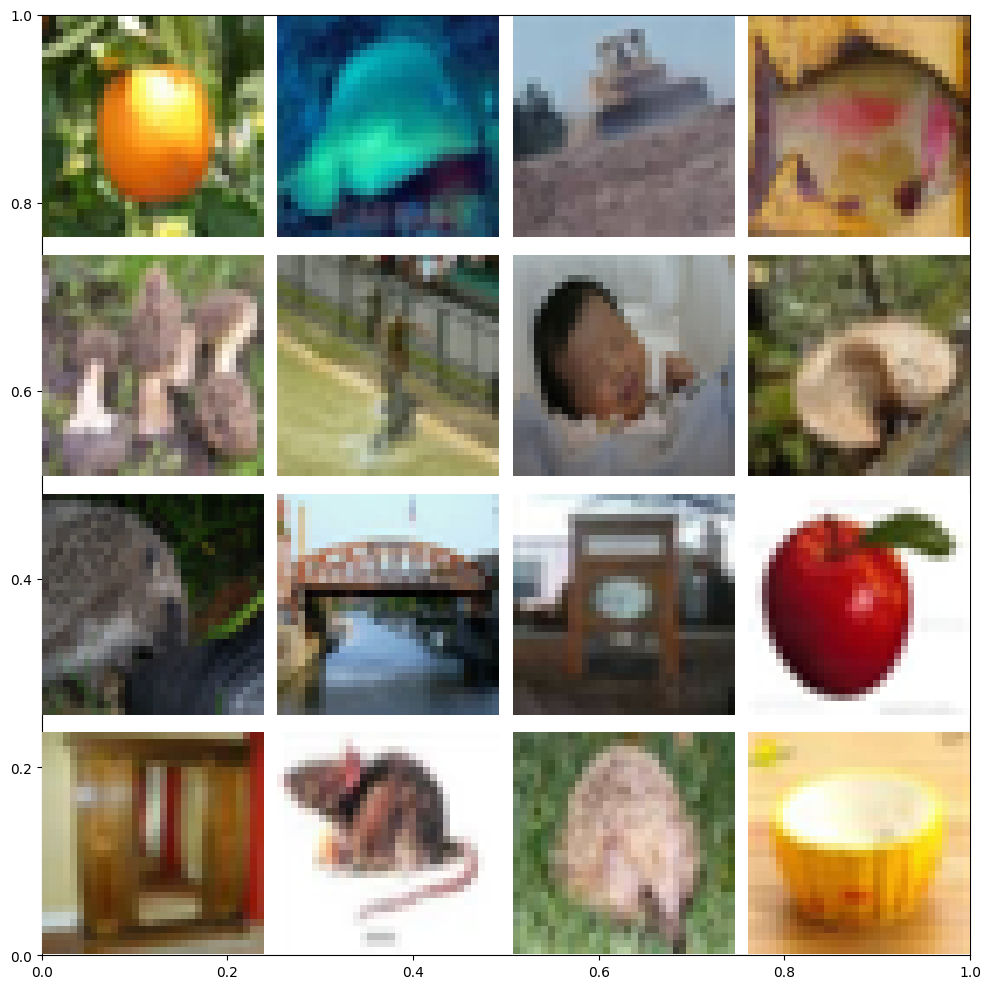

labels[21791].shape: (1,)
imgs[21791].shape: (32, 32, 3)


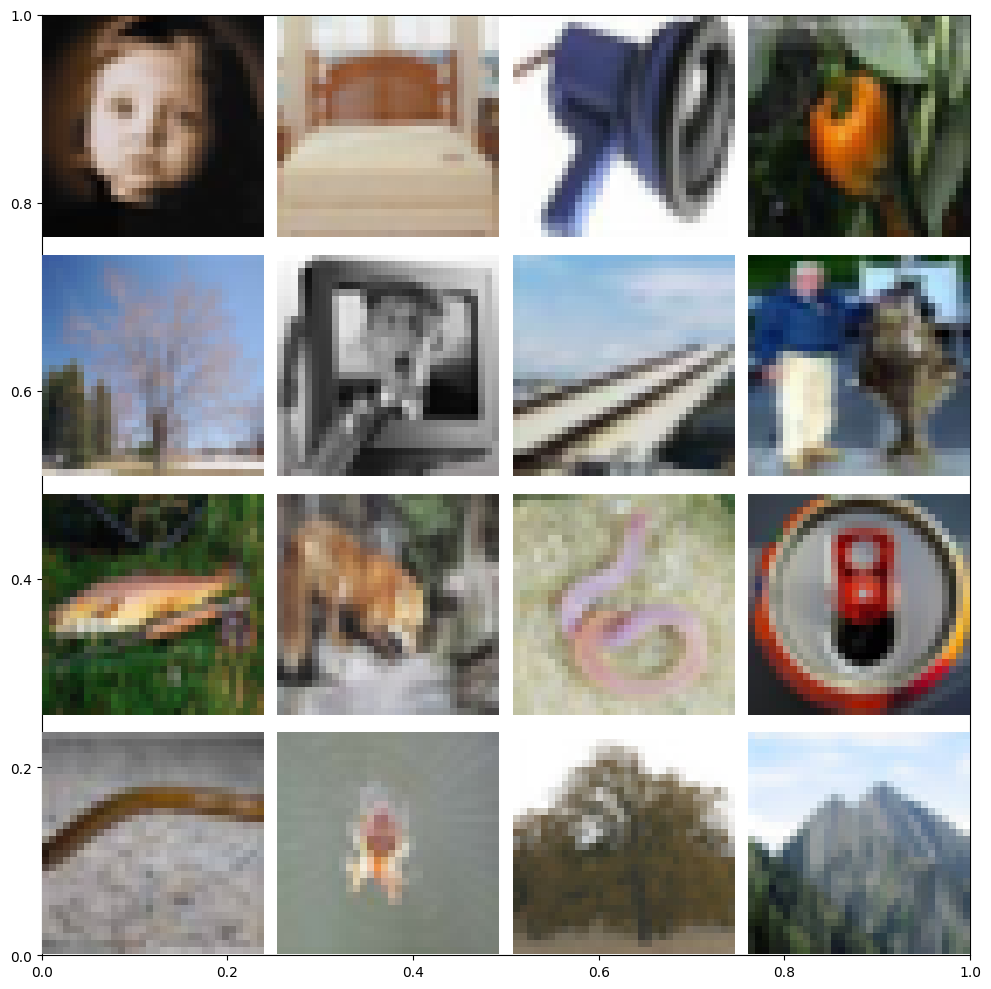

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


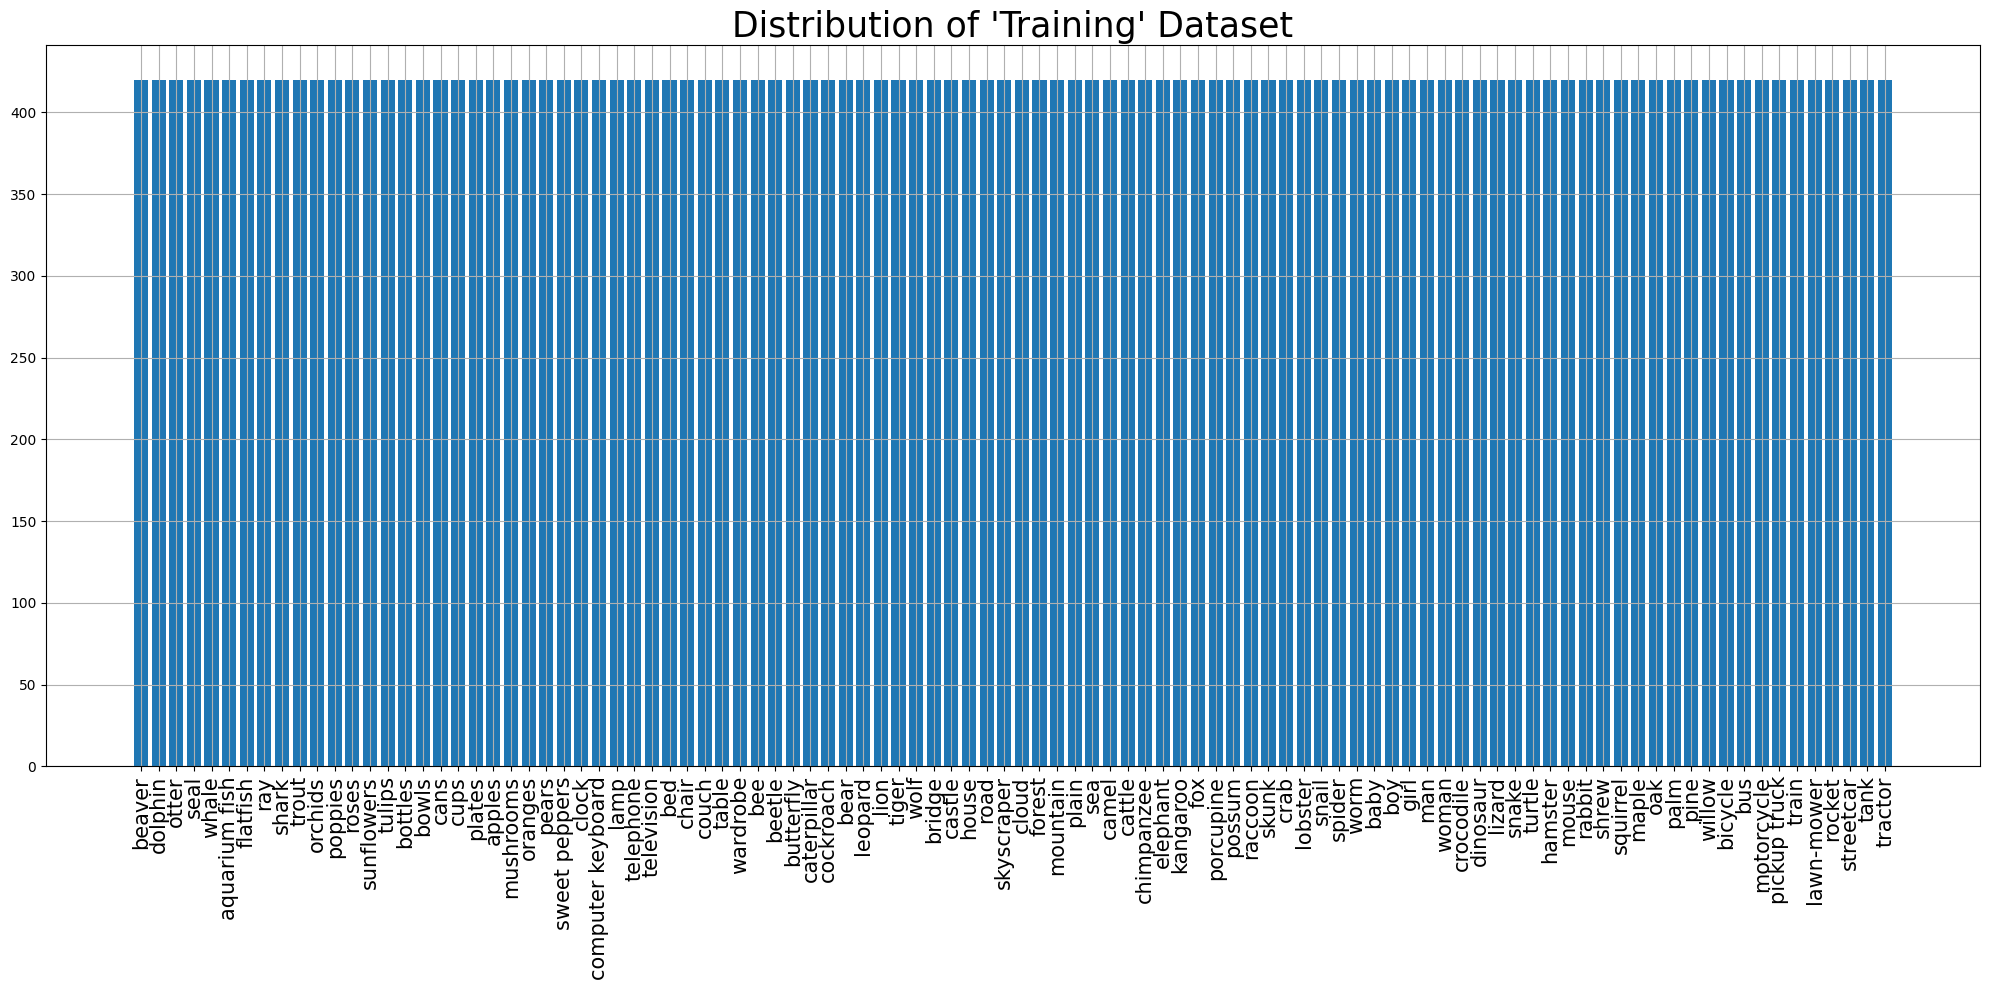

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


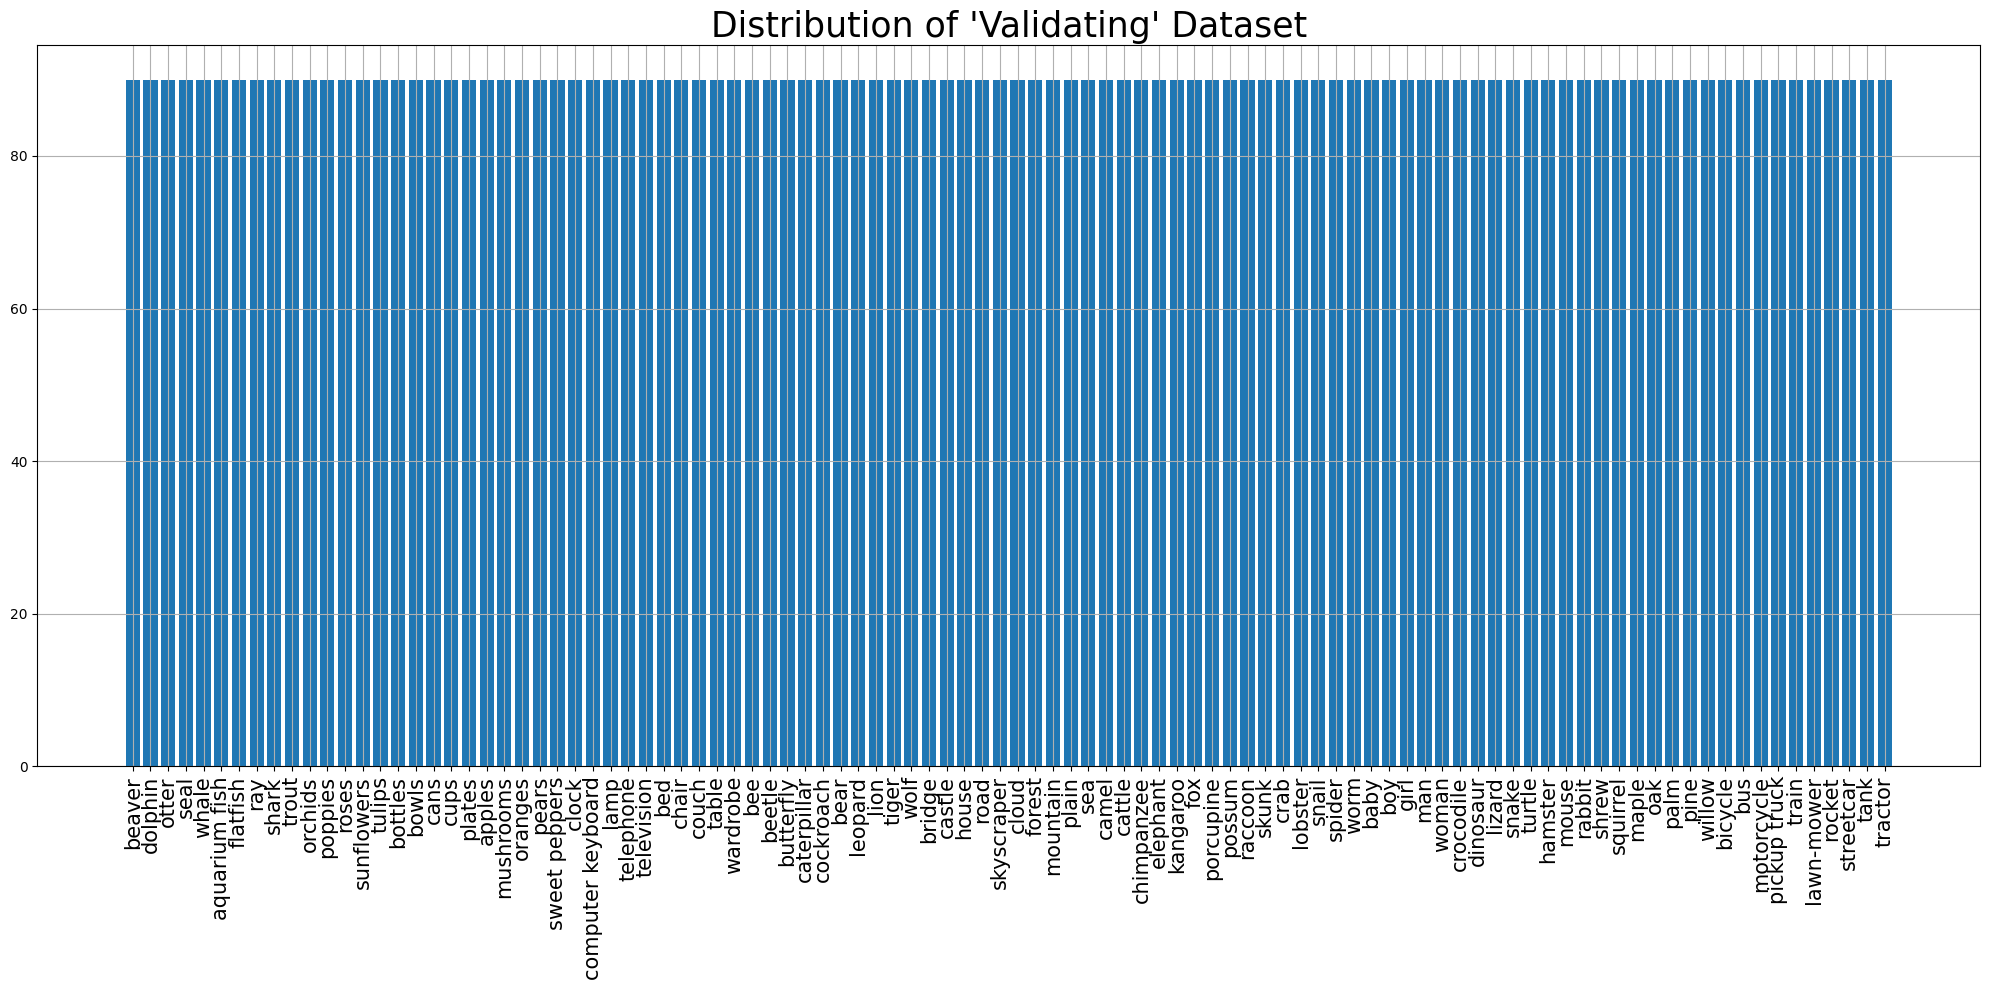

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


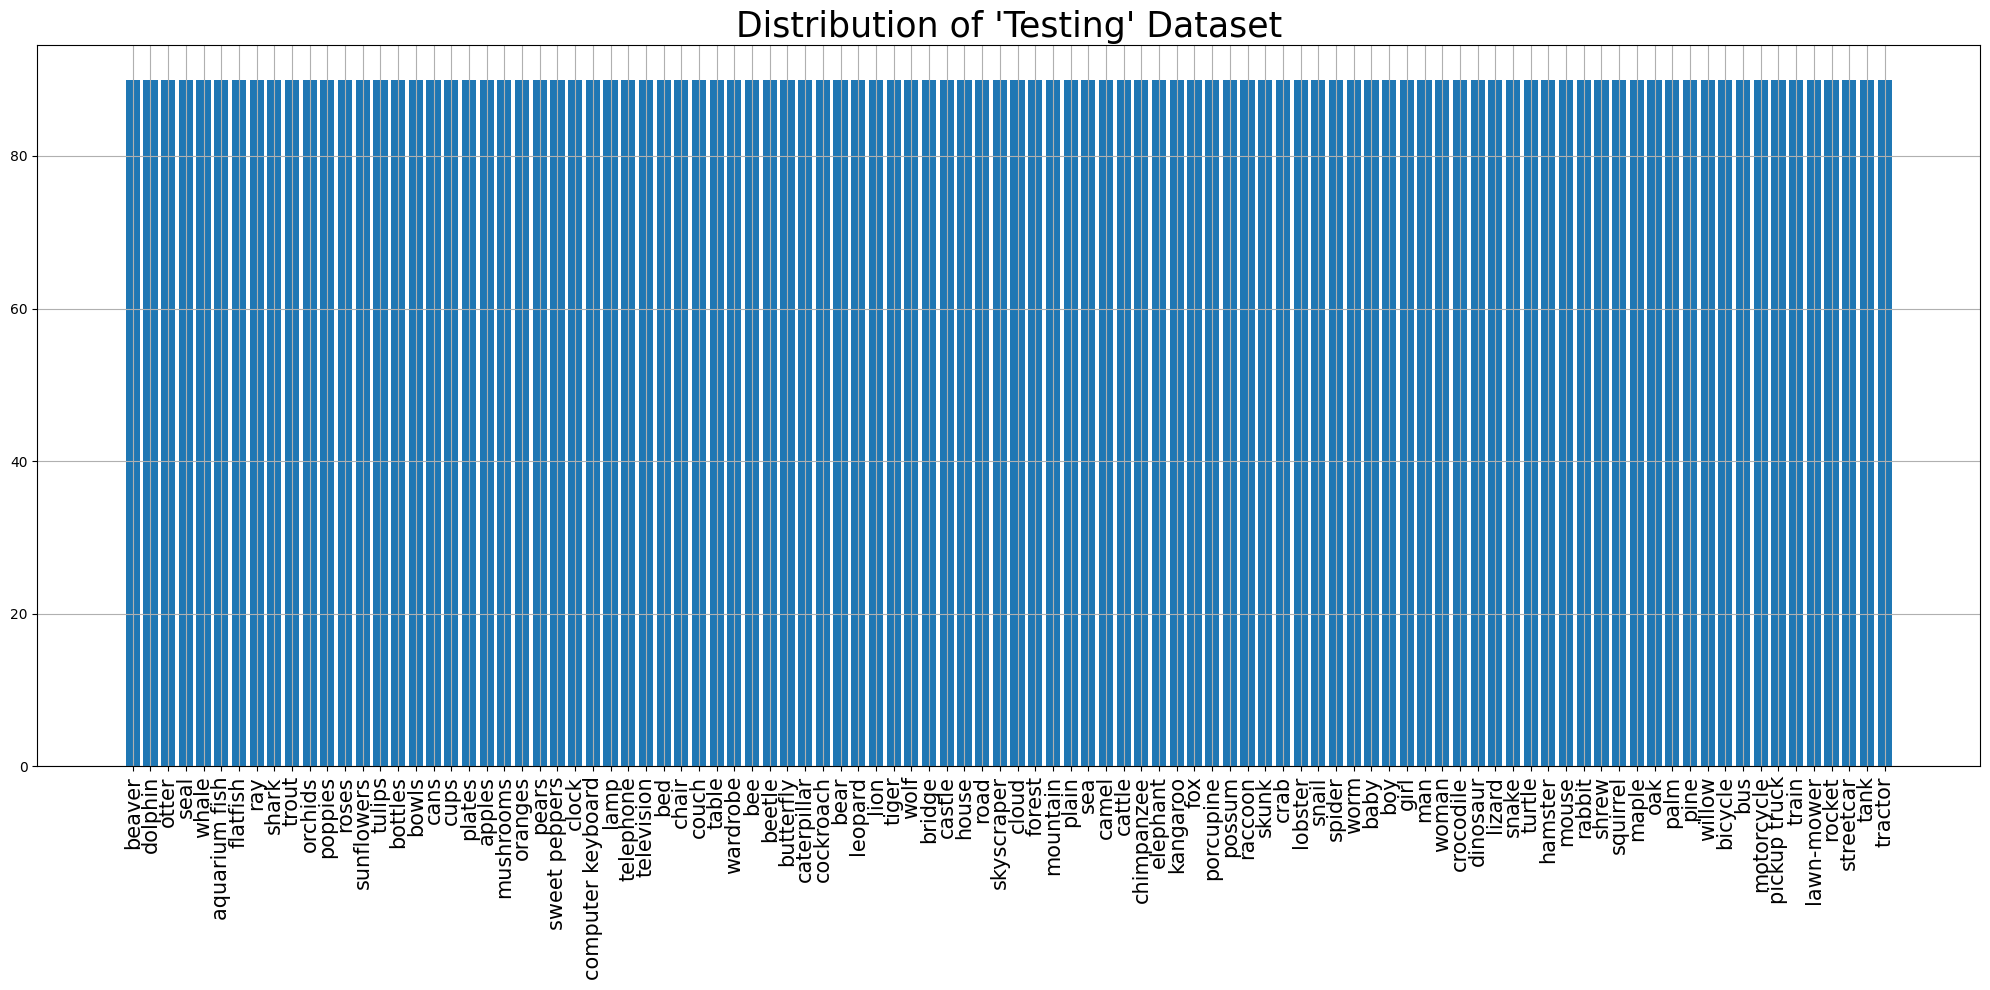

Training dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Validation dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Testing dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<class 'tuple'>
2
<class 'tensorflow.python.framework.ops.EagerTensor'> <class 'tensorflow.python.framework.ops.EagerTensor'>
(64, 224, 224, 3)
(64, 100)
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 100)
2
<class 'numpy.nda

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,665,188 (94.09 MB)

 Trainable params: 1,100,388 (4.20 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/25
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3153 - f1_score: 0.3096 - loss: 2.9239 - precision: 0.6580
Epoch 1: val_loss improved from inf to 1.52481, saving model to best_model_v3.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.3154 - f1_score: 0.3097 - loss: 2.9230 - precision: 0.6581 - val_accuracy: 0.5848 - val_f1_score: 0.5807 - val_loss: 1.5248 - val_precision: 0.8240 - learning_rate: 0.0010
Epoch 2/25
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5279 - f1_score: 0.5238 - loss: 1.7301 - precision: 0.7500
Epoch 2: val_loss improved from 1.52481 to 1.40151, saving model to best_model_v3.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.5279 - f1_score: 0.5238 - loss: 1.7300 - precision: 0.7501 - val_accuracy: 0.6110 - val_f1_score: 0.6068 - val_loss: 1.4015 - val_precision: 0.8134 - learning_rate: 0.0010
Epoch 3/25
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5643 - f1_score: 0.5604 - loss: 1.5580 - precision:

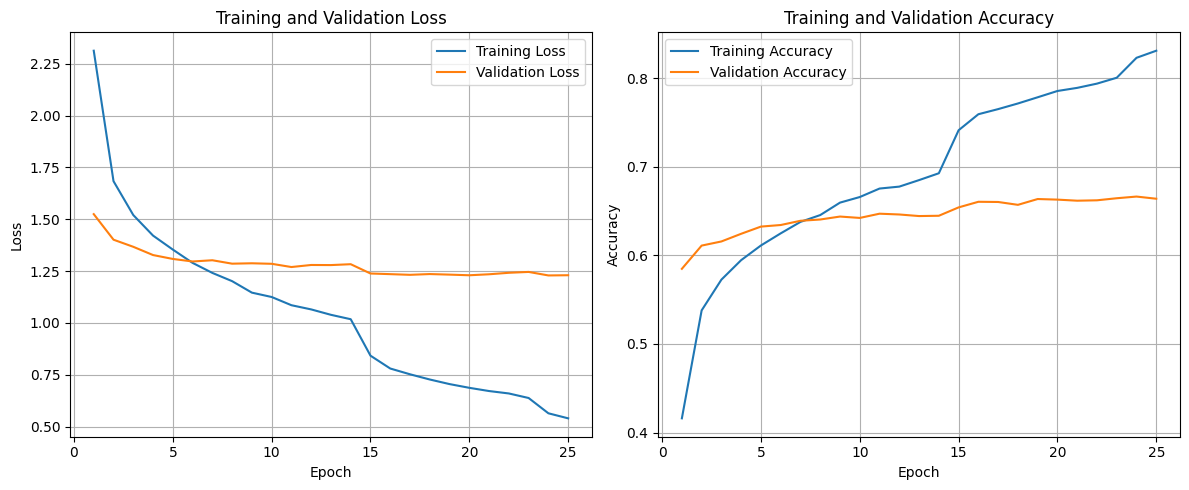

141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.6603 - f1_score: 0.6528 - loss: 1.2323 - precision: 0.7771
Test Accuracy: 67.19%
Test Loss: 1.2073662281036377
Test Precision: 78.48%
Test F1 Scores (Per Class): [85.39326  82.97872  54.945045 47.67441  35.15151  70.85714  65.62499
 71.50838  79.761894 80.446915 71.08433  44.808735 69.87952  61.53846
 65.92178  60.571426 78.723404 77.59562  61.538452 58.536575 84.21052
 74.8663   79.09604  81.31868  82.608696 68.208084 56.32183  50.56179
 80.21389  70.731705 59.036137 70.17543  53.571423 56.744183 71.13402
 44.31137  69.31818  59.793808 54.878044 89.77272  67.70833  81.24999
 61.01694  73.33333  47.663544 50.549446 51.891888 61.90476  82.35293
 79.99999  41.269836 68.783066 64.893616 88.76403  72.916664 32.72727
 81.35593  73.224045 79.761894 59.770107 79.54544  75.82417  69.23077
 65.53671  49.999992 55.95237  65.060234 56.842102 89.385475 86.48647
 72.18934  74.8663   39.52095  61.375652 38.38383  83.33333  85.263145
 60.1227  

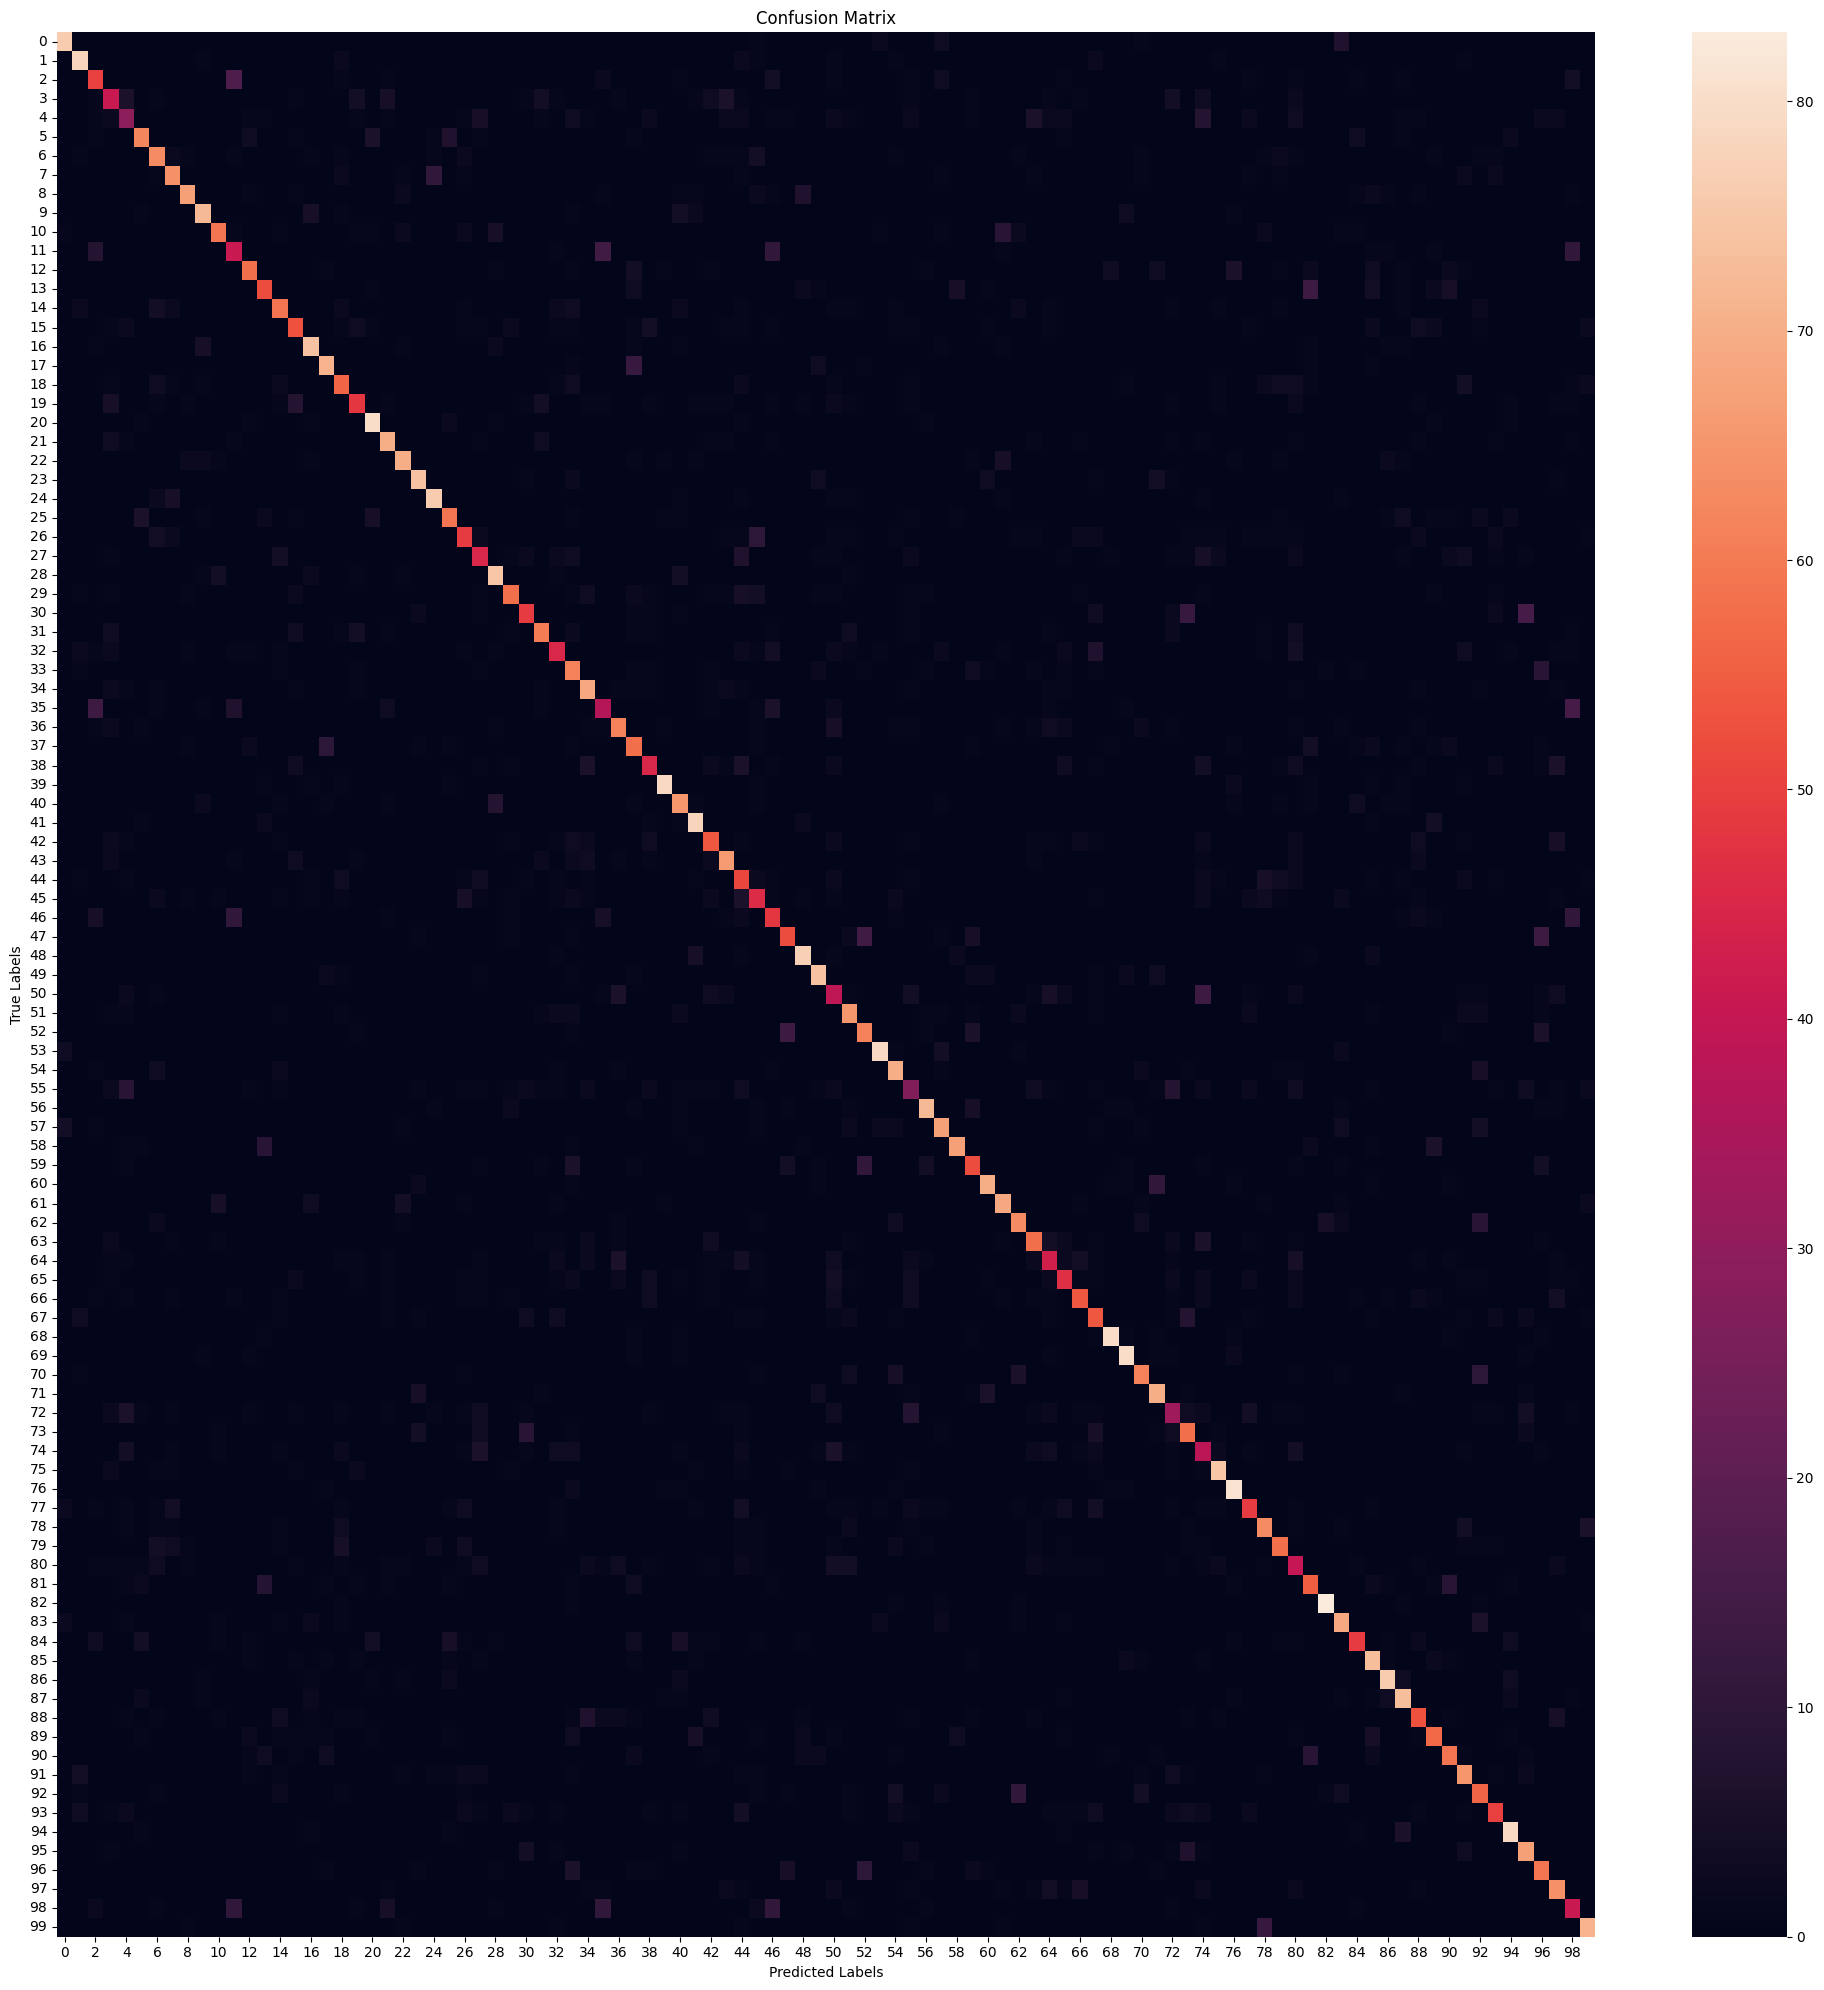

                   precision    recall  f1-score   support

           beaver       0.86      0.84      0.85        90
          dolphin       0.80      0.87      0.83        90
            otter       0.54      0.56      0.55        90
             seal       0.50      0.46      0.48        90
            whale       0.39      0.32      0.35        90
    aquarium fish       0.73      0.69      0.71        90
         flatfish       0.62      0.70      0.66        90
              ray       0.72      0.71      0.72        90
            shark       0.86      0.74      0.80        90
            trout       0.81      0.80      0.80        90
          orchids       0.78      0.66      0.71        90
          poppies       0.44      0.46      0.45        90
            roses       0.76      0.64      0.70        90
       sunflowers       0.66      0.58      0.62        90
           tulips       0.66      0.66      0.66        90
          bottles       0.62      0.59      0.61       

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,665,188 (94.09 MB)

 Trainable params: 1,100,388 (4.20 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/25
1313/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8164 - f1_score: 0.8155 - loss: 0.5882 - precision: 0.8973
Epoch 1: val_loss improved from inf to 1.20597, saving model to best_model_fine_tune_v3.keras
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 56s 34ms/step - accuracy: 0.8164 - f1_score: 0.8155 - loss: 0.5883 - precision: 0.8972 - val_accuracy: 0.6683 - val_f1_score: 0.6666 - val_loss: 1.2060 - val_precision: 0.7850 - learning_rate: 1.0000e-05
Epoch 2/25
1313/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8294 - f1_score: 0.8283 - loss: 0.5580 - precision: 0.9095
Epoch 2: val_loss improved from 1.20597 to 1.20072, saving model to best_model_fine_tune_v3.keras
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - accuracy: 0.8293 - f1_score: 0.8283 - loss: 0.5581 - precision: 0.9095 - val_accuracy: 0.6702 - val_f1_score: 0.6684 - val_loss: 1.2007 - val_precision: 0.7873 - learning_rate: 1.0000e-05
Epoch 3/25
1312/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8333 - f1_sco

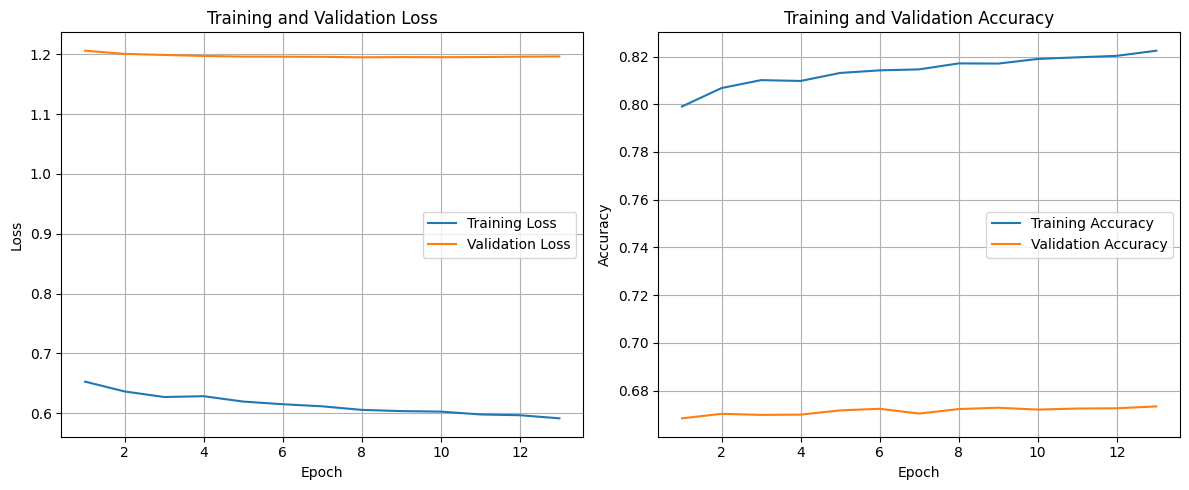

141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.6676 - f1_score: 0.6588 - loss: 1.2010 - precision: 0.7866
Test Accuracy: 67.57%
Test Loss: 1.1776788234710693
Test Precision: 79.41%
Test F1 Scores (Per Class): [84.26965  81.05263  56.544495 49.71751  36.756752 71.03825  65.62499
 73.56321  79.28994  80.       67.415726 46.66666  71.26436  63.09523
 66.28571  60.227264 77.89473  75.675674 60.67415  60.60605  82.608696
 75.93583  80.21977  81.11111  84.32432  69.047615 56.043945 47.567562
 80.66298  68.67469  64.739876 71.764694 56.097557 61.38614  67.6923
 43.093918 70.05649  60.31745  54.748596 90.28571  69.430046 82.53968
 61.87845  76.74419  46.31578  55.05617  51.72413  61.9883   82.53968
 82.41757  44.848476 74.86033  65.97938  87.15083  70.35175  32.558136
 81.39534  75.55555  81.6568   59.39393  81.56424  74.157295 69.94535
 65.517235 50.602406 56.084652 63.73626  59.999996 88.770035 85.10638
 72.41379  75.40983  39.053246 62.032085 42.10526  81.72042  85.10638
 60.71427

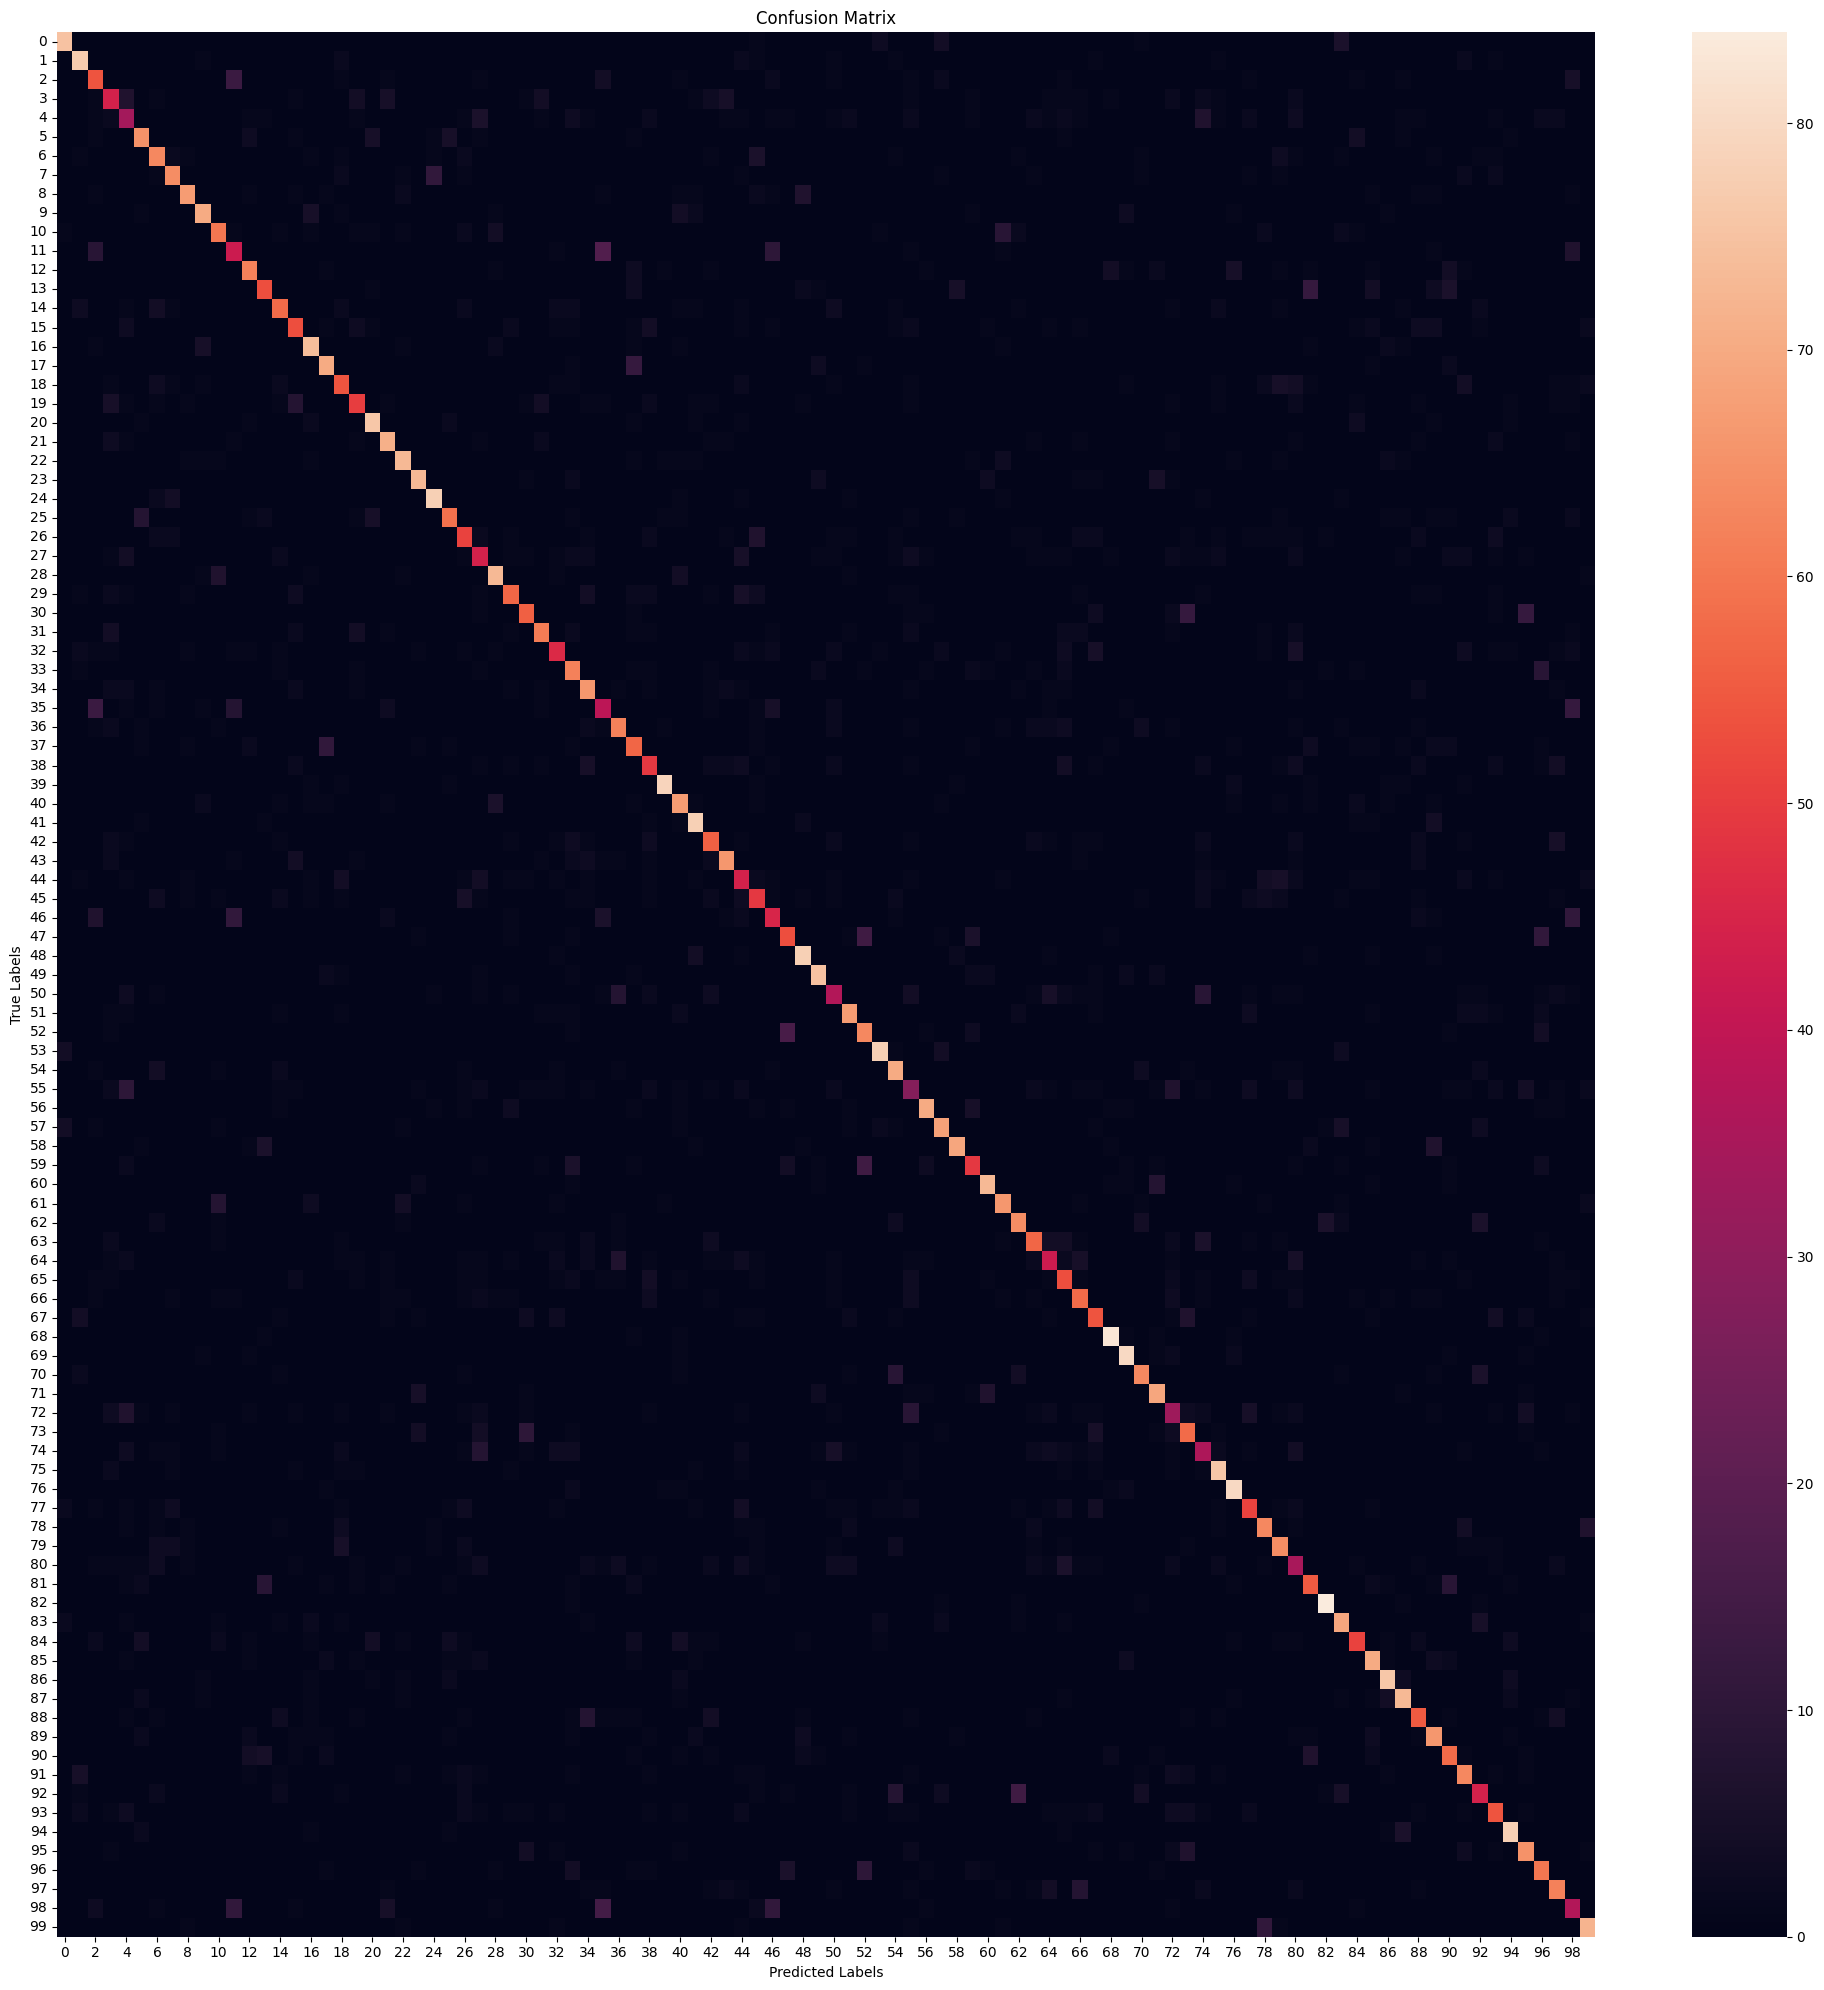

                   precision    recall  f1-score   support

           beaver       0.85      0.83      0.84        90
          dolphin       0.77      0.86      0.81        90
            otter       0.53      0.60      0.57        90
             seal       0.51      0.49      0.50        90
            whale       0.36      0.38      0.37        90
    aquarium fish       0.70      0.72      0.71        90
         flatfish       0.62      0.70      0.66        90
              ray       0.76      0.71      0.74        90
            shark       0.85      0.74      0.79        90
            trout       0.82      0.78      0.80        90
          orchids       0.68      0.67      0.67        90
          poppies       0.47      0.47      0.47        90
            roses       0.74      0.69      0.71        90
       sunflowers       0.68      0.59      0.63        90
           tulips       0.68      0.64      0.66        90
          bottles       0.62      0.59      0.60       

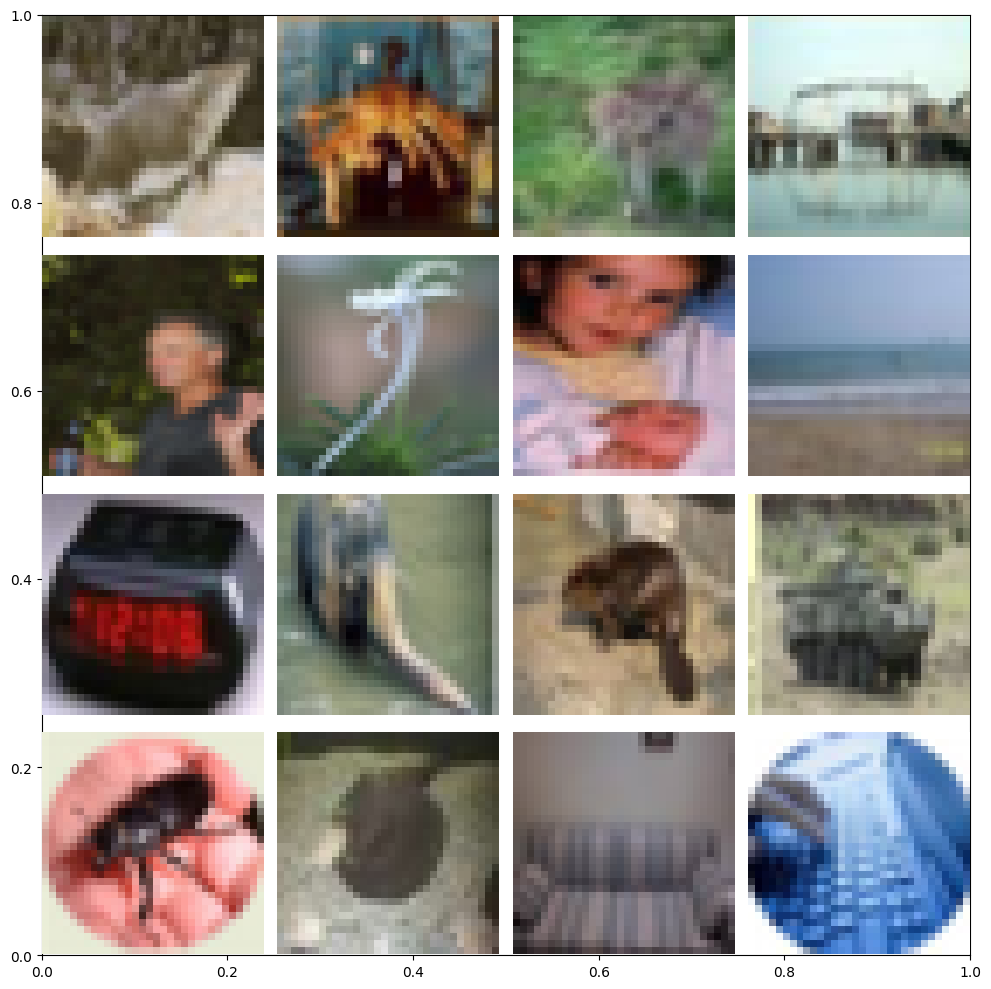

labels[34923].shape: (1,)
imgs[34923].shape: (32, 32, 3)


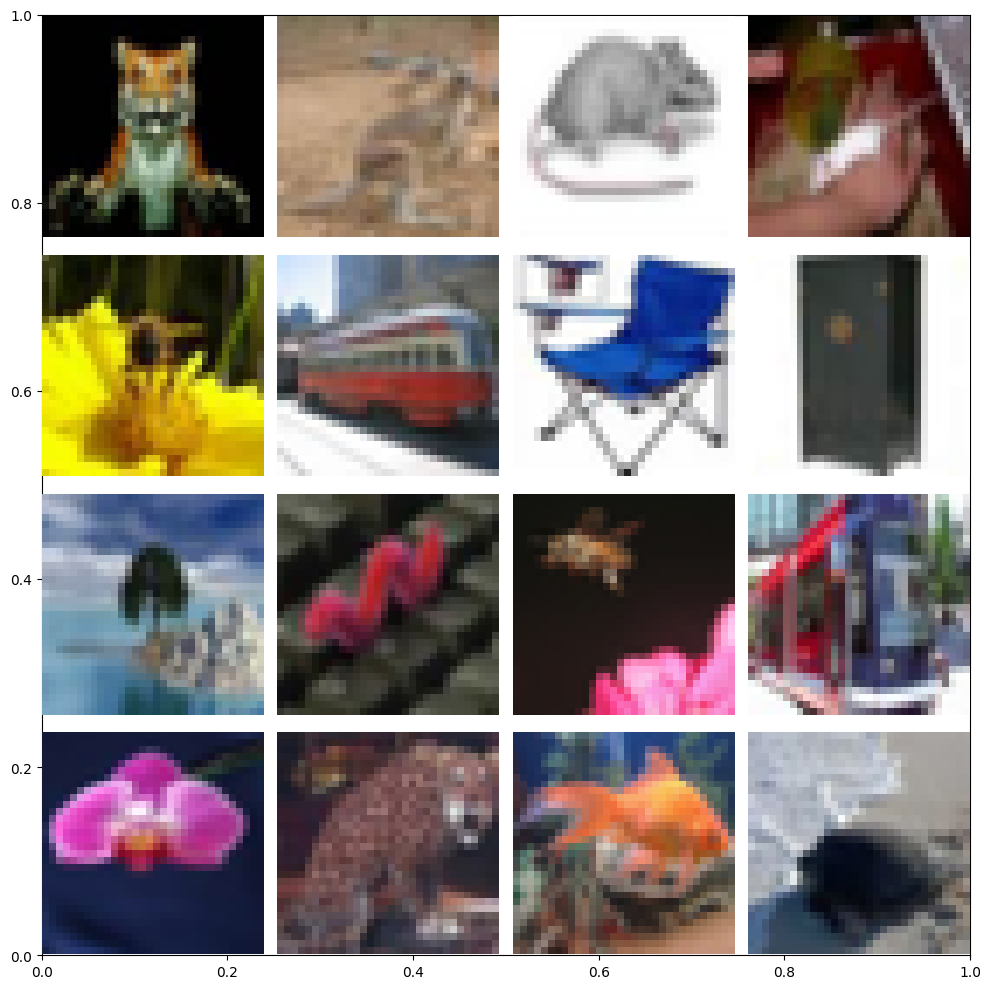

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


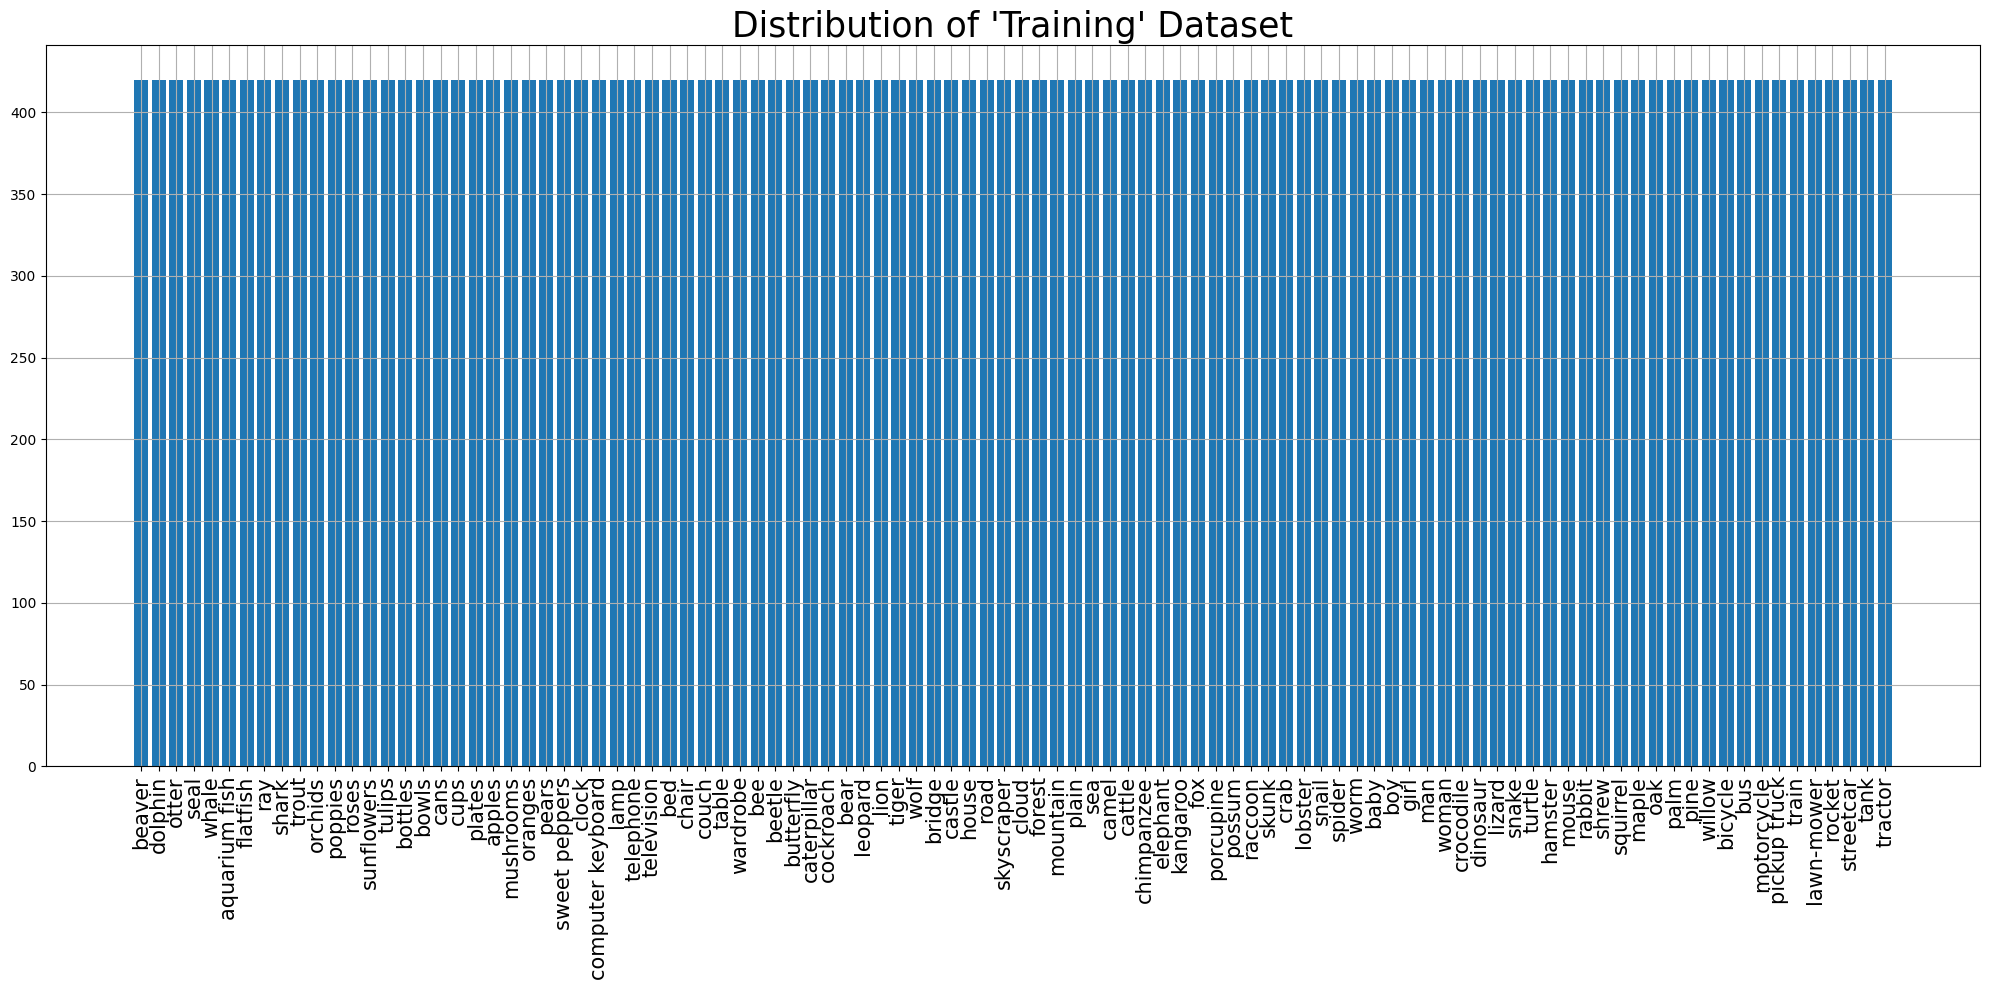

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


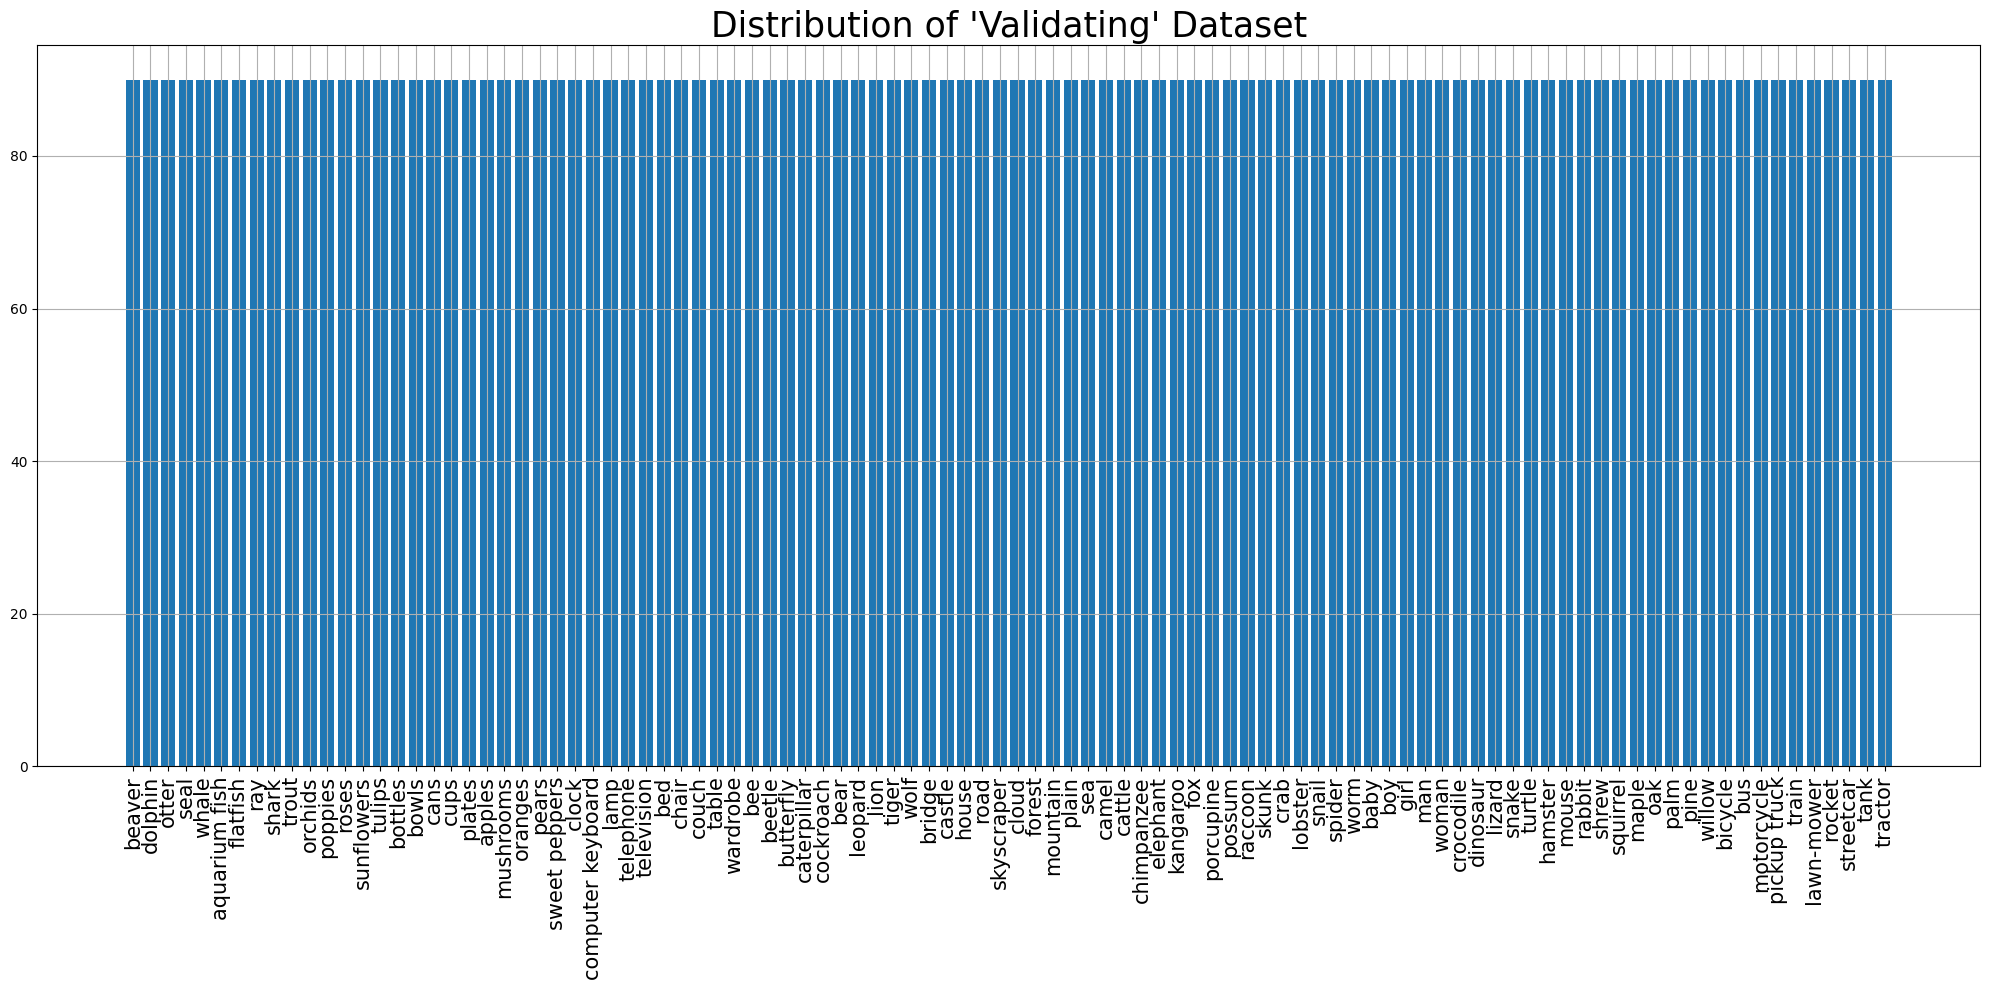

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


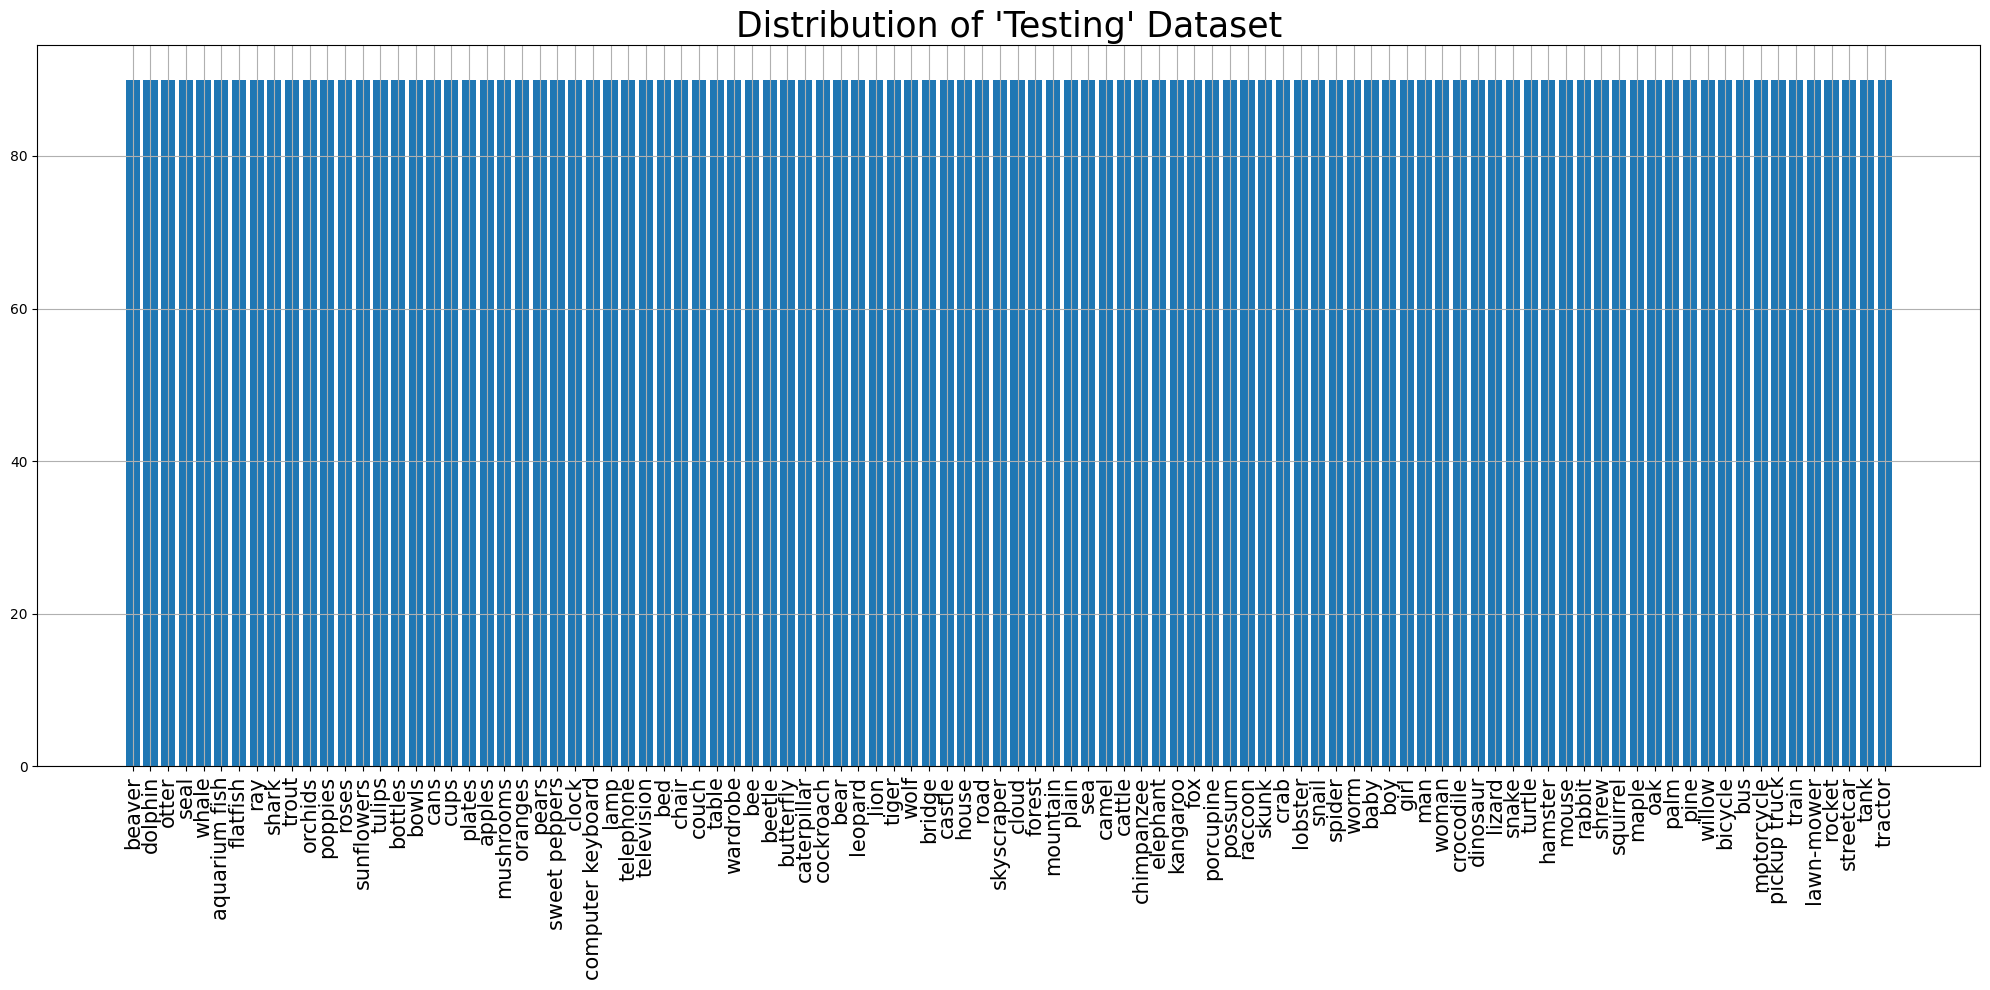

Training dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Validation dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Testing dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)
<class 'tuple'>
2
<class 'tensorflow.python.framework.ops.EagerTensor'> <class 'tensorflow.python.framework.ops.EagerTensor'>
(64, 224, 224, 3)
(64, 100)
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 100)
2
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(64, 224, 224, 3) (6

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,665,188 (94.09 MB)

 Trainable params: 1,100,388 (4.20 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/25
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3190 - f1_score: 0.3141 - loss: 2.8938 - precision: 0.6685
Epoch 1: val_loss improved from inf to 1.51700, saving model to best_model_v3.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.3192 - f1_score: 0.3142 - loss: 2.8929 - precision: 0.6686 - val_accuracy: 0.5859 - val_f1_score: 0.5770 - val_loss: 1.5170 - val_precision: 0.8235 - learning_rate: 0.0010
Epoch 2/25
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5241 - f1_score: 0.5202 - loss: 1.7370 - precision: 0.7475
Epoch 2: val_loss improved from 1.51700 to 1.41212, saving model to best_model_v3.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.5241 - f1_score: 0.5202 - loss: 1.7369 - precision: 0.7475 - val_accuracy: 0.6101 - val_f1_score: 0.6061 - val_loss: 1.4121 - val_precision: 0.8082 - learning_rate: 0.0010
Epoch 3/25
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5691 - f1_score: 0.5655 - loss: 1.5513 - precision:

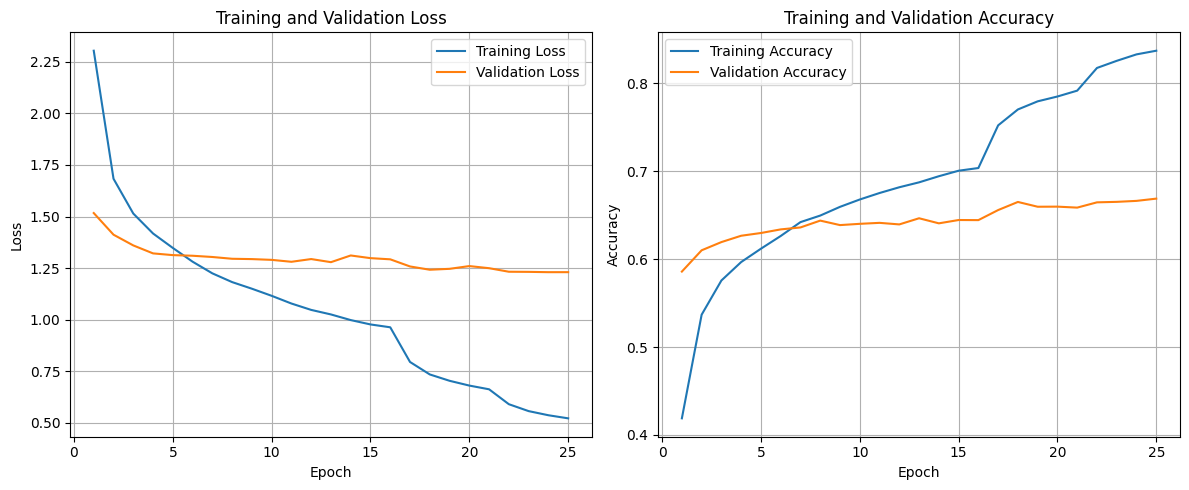

141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.6609 - f1_score: 0.6529 - loss: 1.2480 - precision: 0.7791
Test Accuracy: 67.01%
Test Loss: 1.2199194431304932
Test Precision: 78.83%
Test F1 Scores (Per Class): [83.615814 77.227715 62.14689  49.999992 39.999996 65.43209  59.259247
 71.50838  82.08092  83.33333  65.14285  55.555553 65.53671  61.9883
 68.888885 63.33333  74.87179  78.53403  62.29508  57.499992 84.37499
 75.13227  80.22598  78.85714  83.422455 65.30612  51.999992 49.49494
 80.66298  66.66666  60.1227   71.73912  49.689434 58.878494 67.34693
 31.847128 71.18643  65.16853  50.588226 89.265526 67.74193  86.33879
 66.666664 74.117645 49.999992 49.122803 53.124992 60.24096  82.90154
 80.       38.74345  71.35134  66.66666  90.90909  70.29703  35.999996
 80.89887  72.34043  79.99999  59.523804 81.14285  73.74301  66.666664
 68.67469  46.06741  52.380943 63.905323 63.541664 87.64044  88.04347
 71.26436  75.12689  42.162155 59.259247 43.181812 84.26965  88.17203
 58.75705

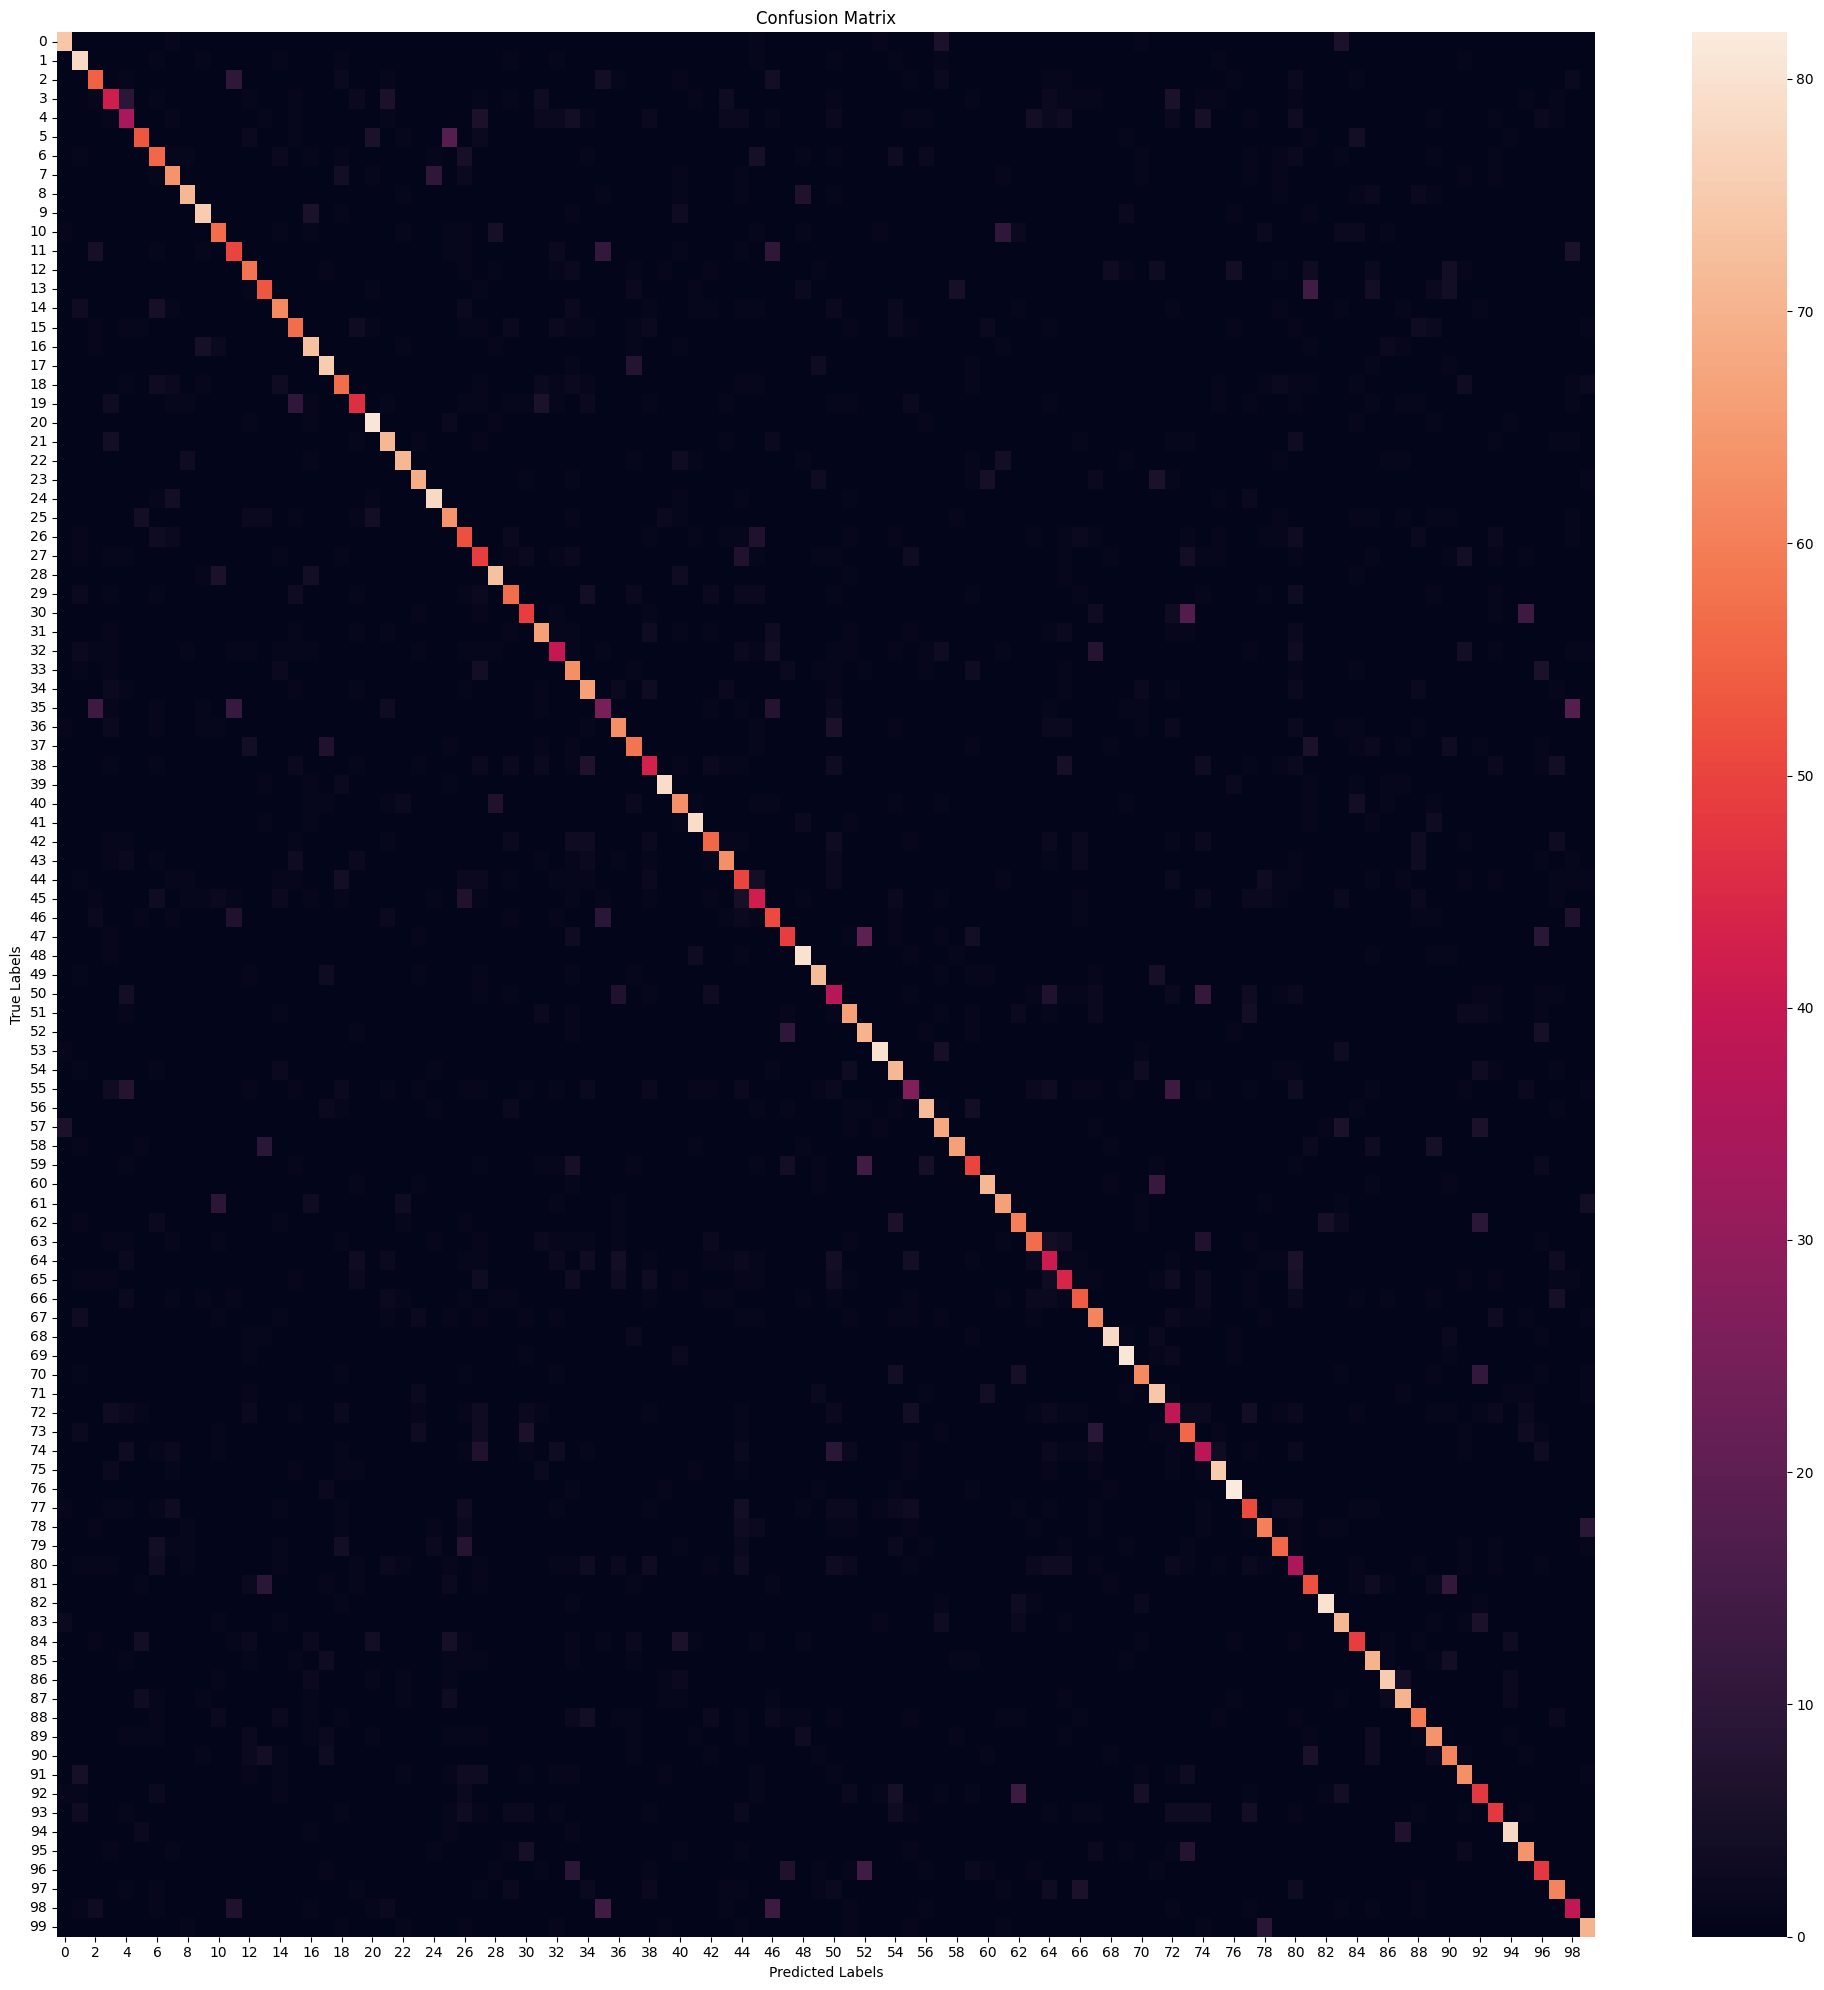

                   precision    recall  f1-score   support

           beaver       0.85      0.82      0.84        90
          dolphin       0.70      0.87      0.77        90
            otter       0.63      0.61      0.62        90
             seal       0.54      0.47      0.50        90
            whale       0.42      0.38      0.40        90
    aquarium fish       0.74      0.59      0.65        90
         flatfish       0.57      0.62      0.59        90
              ray       0.72      0.71      0.72        90
            shark       0.86      0.79      0.82        90
            trout       0.83      0.83      0.83        90
          orchids       0.67      0.63      0.65        90
          poppies       0.56      0.56      0.56        90
            roses       0.67      0.64      0.66        90
       sunflowers       0.65      0.59      0.62        90
           tulips       0.69      0.69      0.69        90
          bottles       0.63      0.63      0.63       

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,665,188 (94.09 MB)

 Trainable params: 1,100,388 (4.20 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8244 - f1_score: 0.8232 - loss: 0.5680 - precision: 0.9036
Epoch 1: val_loss improved from inf to 1.21142, saving model to best_model_fine_tune_v3.keras
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 56s 35ms/step - accuracy: 0.8244 - f1_score: 0.8232 - loss: 0.5680 - precision: 0.9036 - val_accuracy: 0.6700 - val_f1_score: 0.6688 - val_loss: 1.2114 - val_precision: 0.7926 - learning_rate: 1.0000e-05
Epoch 2/25
1313/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8345 - f1_score: 0.8334 - loss: 0.5459 - precision: 0.9133
Epoch 2: val_loss improved from 1.21142 to 1.20769, saving model to best_model_fine_tune_v3.keras
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - accuracy: 0.8344 - f1_score: 0.8334 - loss: 0.5460 - precision: 0.9133 - val_accuracy: 0.6699 - val_f1_score: 0.6687 - val_loss: 1.2077 - val_precision: 0.7935 - learning_rate: 1.0000e-05
Epoch 3/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8366 - f1_sco

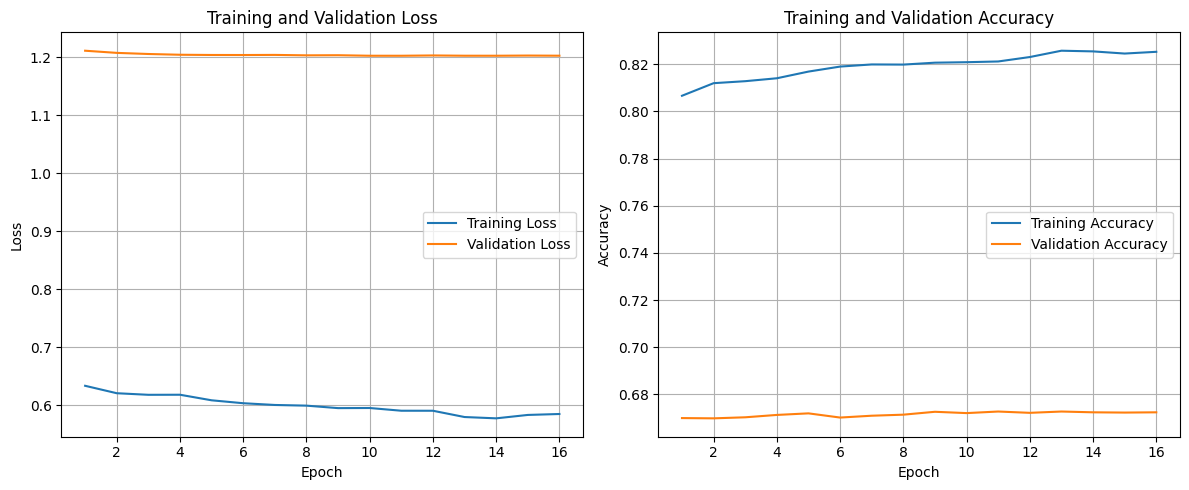

141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6626 - f1_score: 0.6543 - loss: 1.2195 - precision: 0.7891
Test Accuracy: 67.58%
Test Loss: 1.1938602924346924
Test Precision: 79.74%
Test F1 Scores (Per Class): [84.44444  77.61194  62.63736  47.953213 42.328033 70.329666 61.702126
 69.71428  83.04093  82.22221  66.29213  52.439022 65.14285  60.919537
 68.208084 62.06896  74.8663   79.14438  60.63829  60.1227   84.04254
 76.8421   81.56424  77.9661   82.7957   67.77777  56.043945 52.261307
 80.87432  70.658676 59.770107 73.56321  51.851852 61.16504  68.508286
 36.809814 68.888885 62.032085 52.127655 90.28571  66.99999  85.55555
 69.71428  71.91011  49.72375  50.847454 51.891888 62.275444 82.47422
 80.       38.55421  74.59459  66.31015  91.01122  71.35678  37.426895
 81.14285  74.31693  79.04191  61.9883   80.446915 74.4186   67.37968
 69.36415  44.97041  54.748596 62.499992 62.85714  88.17203  86.48647
 72.83237  77.65957  42.937847 60.73298  41.142853 83.33333  89.72973
 58.10

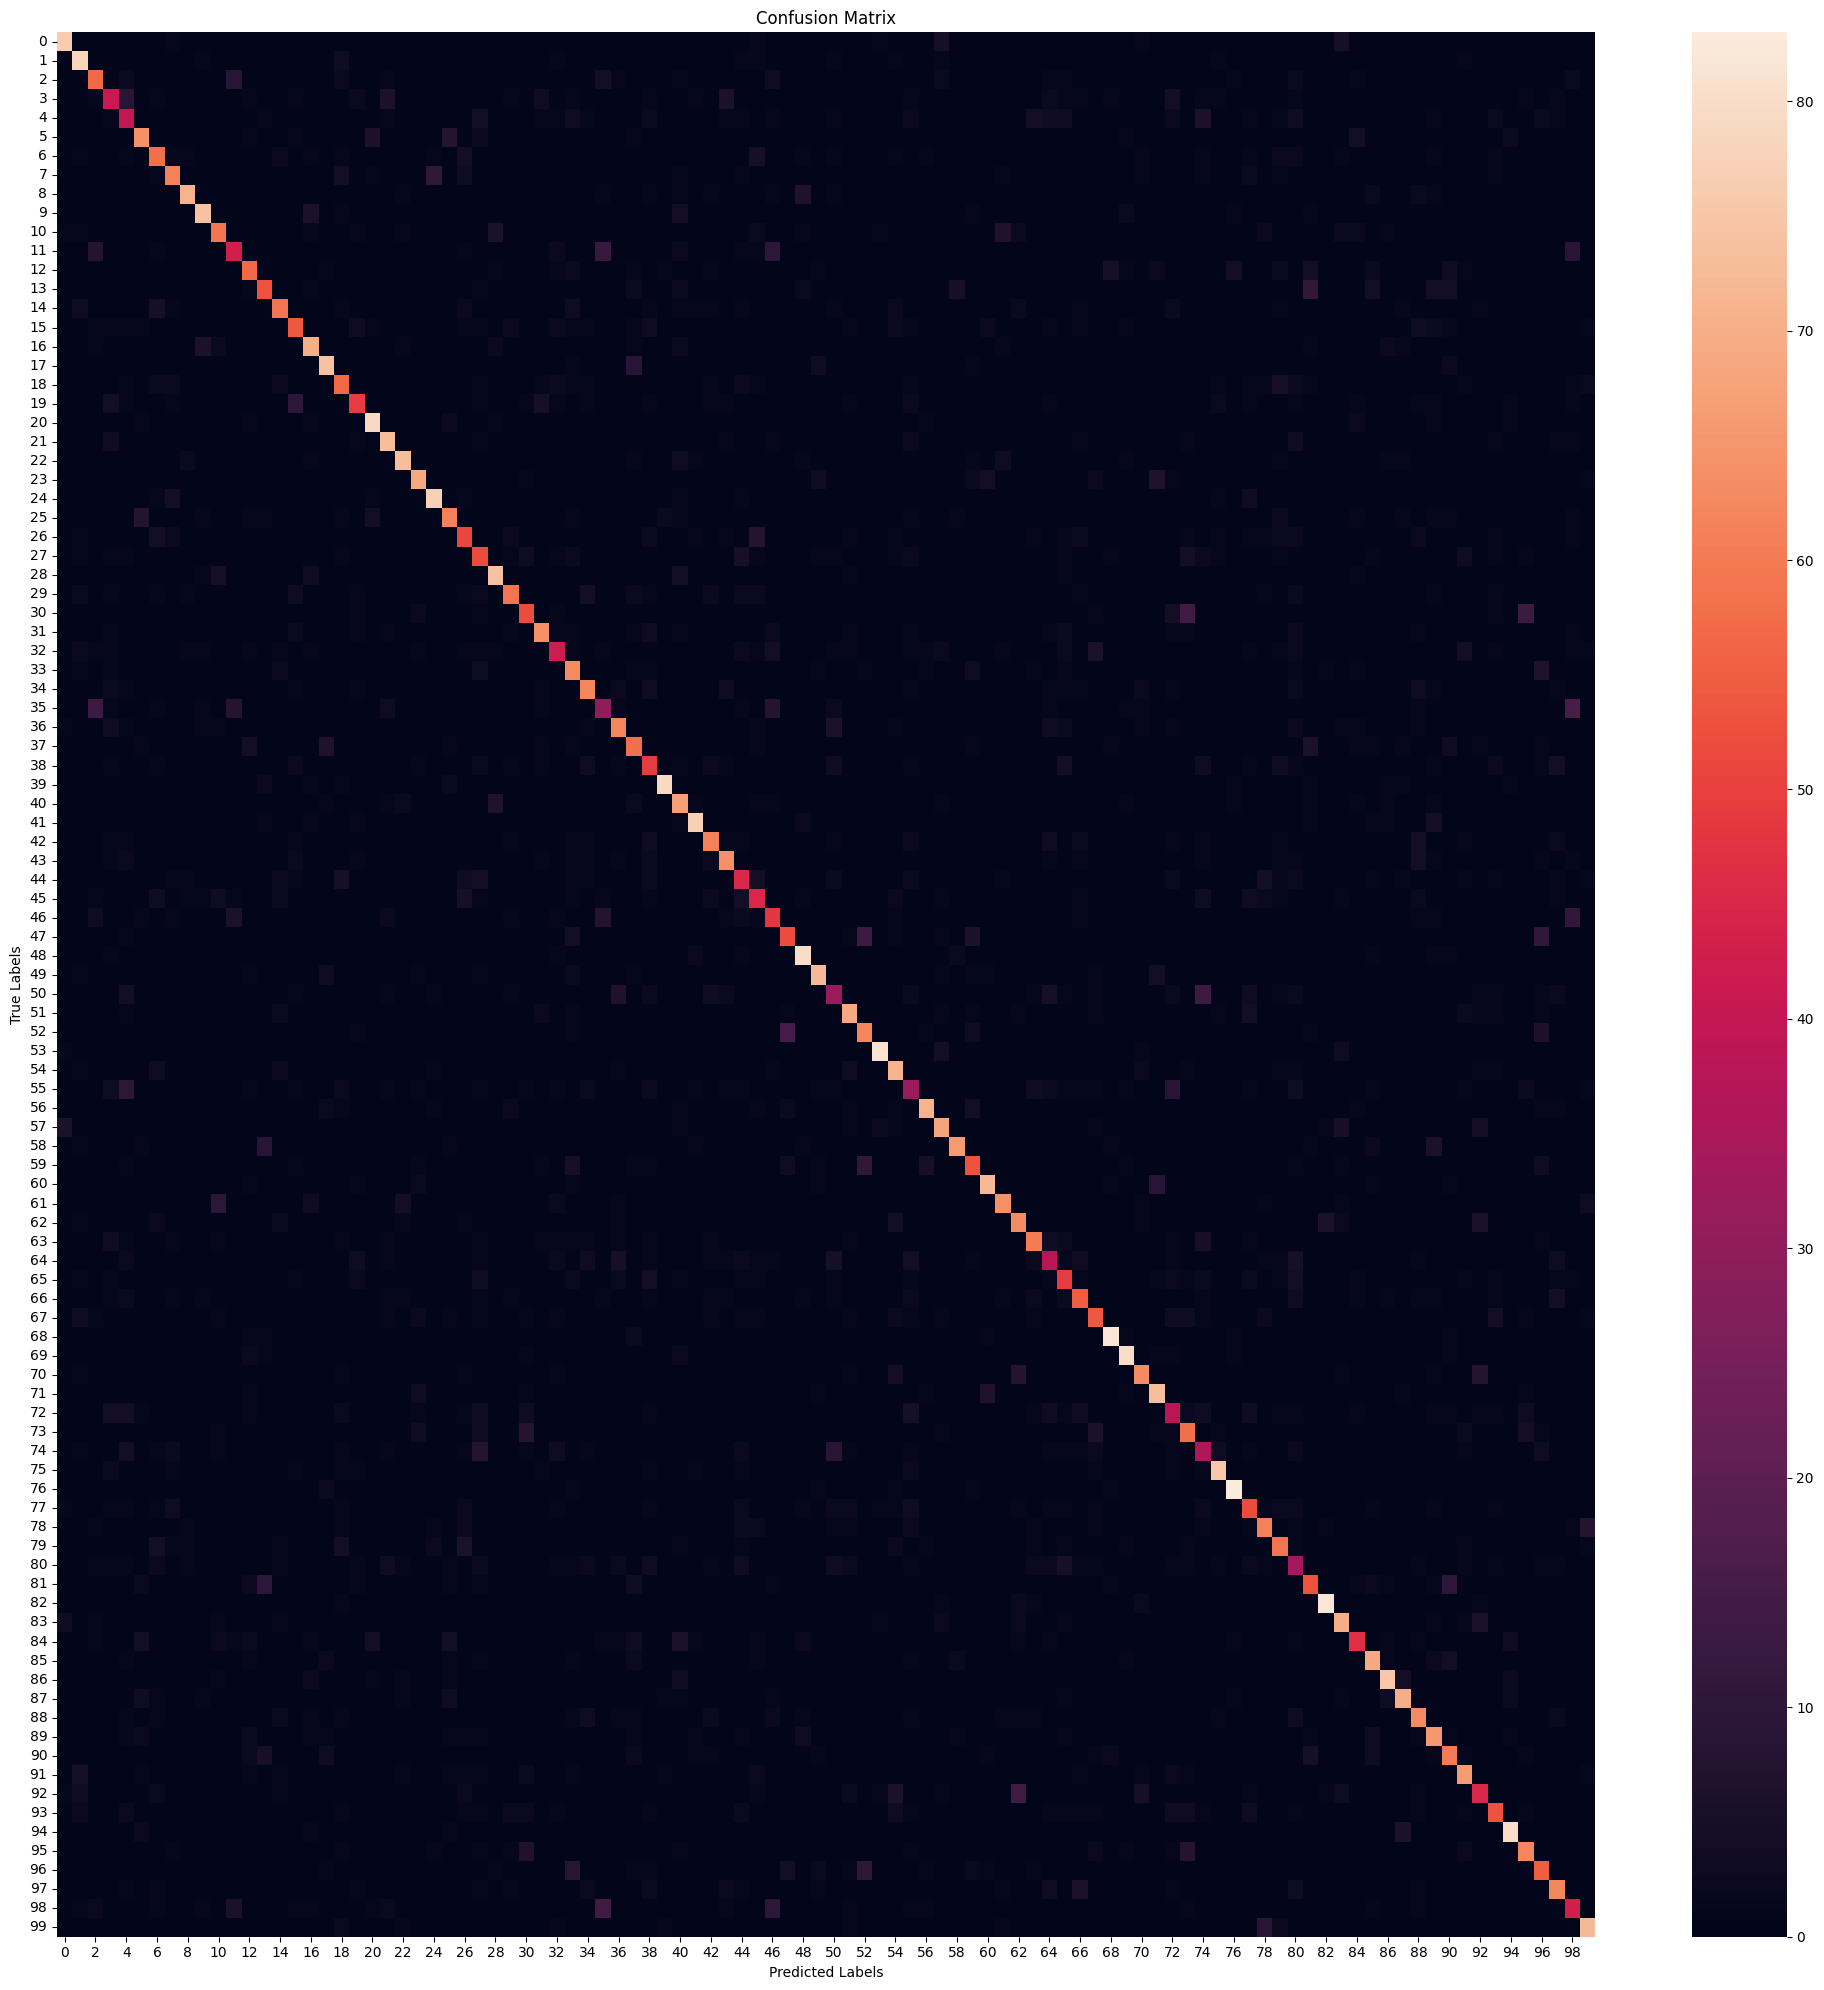

                   precision    recall  f1-score   support

           beaver       0.84      0.84      0.84        90
          dolphin       0.70      0.87      0.78        90
            otter       0.61      0.63      0.62        90
             seal       0.51      0.46      0.48        90
            whale       0.40      0.44      0.42        90
    aquarium fish       0.70      0.71      0.70        90
         flatfish       0.59      0.64      0.62        90
              ray       0.72      0.68      0.70        90
            shark       0.88      0.79      0.83        90
            trout       0.82      0.82      0.82        90
          orchids       0.67      0.66      0.66        90
          poppies       0.58      0.48      0.52        90
            roses       0.67      0.63      0.65        90
       sunflowers       0.63      0.59      0.61        90
           tulips       0.71      0.66      0.68        90
          bottles       0.64      0.60      0.62       

In [7]:
for repeat_2_times in range(2):
    #### <<<<<<<<<<Load and process data>>>>>>>>>>
    # Load CIFAR-100 dataset
    (X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode='fine')

    # Split (8000) of training data into temporary set
    X_temp, X_train, y_temp, y_train = train_test_split(X_train, y_train, test_size=0.84, stratify=y_train, random_state=42)
    print(f"X_temp.shape: {X_temp.shape}\n")

    # Split temp data into equal validation (4000) and testing (4000) data
    X_temp_val, X_temp_test, y_temp_val, y_temp_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
    print(f"X_temp_val.shape: {X_temp_val.shape}")
    print(f"y_temp_val.shape: {y_temp_val.shape}")
    print(f"X_temp_test.shape: {X_temp_test.shape}")
    print(f"y_temp_test.shape: {y_temp_test.shape}\n")

    # Split test data into validation (5000) and testing (5000)
    X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=42)

    # Add temp_val to validation (9000) and temp_test to testing (9000) to get a 70/15/15 data split
    X_val = np.concatenate((X_val, X_temp_val), axis=0)
    y_val = np.concatenate((y_val, y_temp_val), axis=0)
    X_test = np.concatenate((X_test, X_temp_test), axis=0)
    y_test = np.concatenate((y_test, y_temp_test), axis=0)

    print(f"X_train.shape: {X_train.shape}")
    print(f"y_train.shape: {y_train.shape}")
    print(f"X_val.shape: {X_val.shape}")
    print(f"y_val.shape: {y_val.shape}")
    print(f"X_test.shape: {X_test.shape}")
    print(f"y_test.shape: {y_test.shape}\n")

    display_imgs(X_train, y_train)

    # Normalise images (scale to range [0, 1]) - Improves convergence speed & accuracy
    X_train, X_val, X_test = X_train / 255.0, X_val / 255.0, X_test / 255.0
    display_imgs(X_train, y_train)

    labels_names = ['beaver','dolphin','otter','seal','whale','aquarium fish','flatfish','ray','shark','trout',
                   'orchids','poppies','roses','sunflowers','tulips','bottles','bowls','cans','cups','plates',
                   'apples','mushrooms','oranges','pears','sweet peppers','clock','computer keyboard','lamp',
                   'telephone','television','bed','chair','couch','table','wardrobe','bee','beetle','butterfly',
                   'caterpillar','cockroach','bear','leopard','lion','tiger','wolf','bridge','castle','house',
                   'road','skyscraper','cloud','forest','mountain','plain','sea','camel','cattle','chimpanzee',
                   'elephant','kangaroo','fox','porcupine','possum','raccoon','skunk','crab','lobster','snail',
                   'spider','worm','baby','boy','girl','man','woman','crocodile','dinosaur','lizard','snake',
                   'turtle','hamster','mouse','rabbit','shrew','squirrel','maple','oak','palm','pine','willow',
                   'bicycle','bus','motorcycle','pickup truck','train','lawn-mower','rocket','streetcar','tank',
                   'tractor']

    class_distrib(y_train, labels_names, "Training")
    class_distrib(y_val, labels_names, "Validating")
    class_distrib(y_test, labels_names, "Testing")

    # Create TensorFlow datasets

    batch_size = 64

    train_dataset_ = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
                     .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                        tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
                     .batch(batch_size)
                     .prefetch(tf.data.experimental.AUTOTUNE))

    # DEBUG augment
    #train_dataset_aug = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
    #                 .map(augment_dataset, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    #                 .batch(batch_size)
    #                 .prefetch(tf.data.experimental.AUTOTUNE))

    # Combine the original dataset and the augmented dataset
    train_dataset = train_dataset_#.concatenate(train_dataset_aug)

    val_dataset = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
                   .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                      tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
                   .batch(batch_size)
                   .prefetch(tf.data.experimental.AUTOTUNE))

    test_dataset = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
                     .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                        tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
                    .batch(batch_size)
                    .prefetch(tf.data.experimental.AUTOTUNE))

    print(f"Training dataset:\n {train_dataset}")
    for img, lbl in train_dataset.take(1):
        #if isinstance(batch, tuple) and len(batch) == 2:
        print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
        print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
        del img,lbl
    print(f"\nValidation dataset:\n {val_dataset}")
    for img, lbl in val_dataset.take(1):
        #if isinstance(batch, tuple) and len(batch) == 2:
        print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
        print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
        del img,lbl
    print(f"\nTesting dataset:\n {test_dataset}")
    for img, lbl in test_dataset.take(1):
        #if isinstance(batch, tuple) and len(batch) == 2:
        print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
        print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
        del img,lbl


    #### <<<<<<<<<<Pre-trained model>>>>>>>>>>
    # Load ResNet50 pre-trained on ImageNet (w/out the top classification layer which is designed for ImageNet (diff dataset))
    resnet_50_base = tf.keras.applications.ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Freeze the layers of VGG16 so they don't get updated during training - can unfreeze for fine tuning later
    resnet_50_base.trainable = False

    for layer in resnet_50_base.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            layer.kernel_regularizer = tf.keras.regularizers.l2(1e-1) # DEBUG l2

    # Add custom classification layers for CIFAR-100 (100 classes) - adapt model to CIFAR-100
    model = models.Sequential([
        resnet_50_base,
        layers.GlobalAveragePooling2D(), # Better for ResNet than Flatten
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.6), # DEBUG dropout
        layers.Dense(100, activation='softmax')  # CIFAR-100 has 100 classes
    ])

    for sample in test_dataset.take(1):
        print(type(sample))  # Should be <class 'tuple'>
        print(len(sample))  # Should be 2
        print(type(sample[0]), type(sample[1]))  # Both should be <class 'tensorflow.Tensor'>
        print(sample[0].shape)  # Should be (batch_size, 224, 224, 3)
        print(sample[1].shape)  # Should be (batch_size, 100)
    print(f"Model input shape: {model.input_shape}")
    print(f"Model output shape: {model.output_shape}")
    sample = next(iter(test_dataset.as_numpy_iterator()))
    print(len(sample))  # Should be 2
    print(type(sample[0]), type(sample[1]))  # Both should be <class 'numpy.ndarray'>
    print(sample[0].shape, sample[1].shape)  # Should match model input and output
    print("\n")
    #for x, y in test_dataset.take(1):
    #    print(type(x), type(y))  # Both should be <class 'tensorflow.Tensor'>
    #for x_batch, y_batch in test_dataset.take(1):
    #    test_loss, test_acc = model.evaluate(x_batch, y_batch)
    #    print(f"Test Loss: {test_loss}, Test Accuracy: {test_acc}")

    # Compile the model
    #tensorboard_callback = keras.callbacks.TensorBoard(log_dir="./logs")
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3, weight_decay=1e-1), # DEBUG weight
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 'precision', 'f1_score'])

    model.summary()

    #### <<<<<<<<<<Train Model & Track Training/Validation Error>>>>>>>>>>
    early_stopping = EarlyStopping(monitor='val_loss', # or val_accuracy
                                   patience=5, # Num. epochs with no improvements - help void overfitting
                                   restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', # or val_accuracy
                                  factor=0.5, # Reduce lr by a factor
                                  patience=3, # Num epochs w/ no improvement
                                  min_lr=1e-6, # Min lr
                                  verbose=1)
    #tensorboard = TensorBoard(log_dir='./logs', # Logs directory
    #                         histogram_freq=1, # Logs histograms for weights/activations
    #                         write_graph=True, # Logs graph of model
    #                         write_images=True) # Log images like weight histogram
    checkpoint = ModelCheckpoint('best_model_v3.keras', # Path where the best model will be saved
                                 monitor='val_loss', # What to monitor (validation loss)
                                 save_best_only=True, # Only save model when validation loss improves
                                 mode='min', # Looking to minimse the validation loss
                                 verbose=1) # Print out message when saving model
    checkpoint_fine_tune = ModelCheckpoint('best_model_fine_tune_v3.keras', # Path where the best model will be saved
                                 monitor='val_loss', # What to monitor (validation loss)
                                 save_best_only=True, # Only save model when validation loss improves
                                 mode='min', # Looking to minimse the validation loss
                                 verbose=1) # Print out message when saving model
    #cvs_logger = CSVLogger('training_log.csv', seperator=',', append=True) # Save train metrics to analyse

    # Train the model
    history = model.fit(train_dataset, validation_data=val_dataset, epochs=25,
                        batch_size=batch_size, callbacks=[checkpoint, reduce_lr, early_stopping], verbose=1)

    #### <<<<<<<<<<Plot Training & Validation Error>>>>>>>>>>

    # Extract loss and accuracy
    epochs = range(1,len(history.history['loss'])+1)
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    plot_evidence(epochs, train_loss, val_loss, train_acc, val_acc)

    #### <<<<<<<<<<Evaluate Model on Test Data>>>>>>>>>>

    # Evaluate on test data
    model = load_model('best_model_v3.keras')
    results = model.evaluate(test_dataset)
    test_loss = results[0]
    test_acc = results[1]
    test_precision = results[2]
    test_f1_scores = results[3]
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"Test Loss: {test_loss}")
    print(f"Test Precision: {test_precision*100:.2f}%")
    print(f"Test F1 Scores (Per Class): {test_f1_scores.numpy()*100}")
    print(f"Average Test F1 Scores:{np.average(test_f1_scores.numpy()*100):.2f}\n")

    #### <<<<<<<<<<Generate Confusion Matrix>>>>>>>>>>

    # Get predictions
    X_test_revised = tf.image.resize(X_test, (224, 224))
    y_pred = model.predict(X_test_revised)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = y_test.flatten()

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

    # Plot confusion matrix
    plt.figure(figsize=(20, 20))
    sns.heatmap(conf_matrix) #cmap='Blues', fmt='d'
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true_classes, y_pred_classes, target_names=labels_names))
    #tensorboard --logdir==path_to_your_logs

    # Create a DataFrame from the history of the training and store the epoch values.
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    # Finally, display the hist DataFrame.
    hist

    #### <<<<<<<<<<Fine-Tune>>>>>>>>>>
    # Adapt Model
    for layer in resnet_50_base.layers:
        layer.trainable = True # Allow layers to be updated

    # Compile again w/ lower learning rate (prevents destroying learned features)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 'precision', 'f1_score'])

    model.summary()

    #### <<<<<<<<<<Modify Dataset>>>>>>>>>>


    # DEBUG augment
    train_dataset_aug_ = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
                     .map(augment_dataset, num_parallel_calls=tf.data.experimental.AUTOTUNE)
                     .batch(batch_size)
                     .prefetch(tf.data.experimental.AUTOTUNE))

    # Combine the original dataset and the augmented dataset
    train_dataset_aug = train_dataset.concatenate(train_dataset_aug_) # Not val or test as augment train helps generalise better, but want to provide consistent benchmark for eval perf

    #### <<<<<<<<<<Train Model & Track Training/Validation Error>>>>>>>>>>

    # Train the model
    history_fine_tune = model.fit(train_dataset_aug, validation_data=val_dataset, epochs=25,
                                  batch_size=batch_size, callbacks=[checkpoint_fine_tune, reduce_lr, early_stopping], verbose=1)

    #### <<<<<<<<<<Plot Training & Validation Error>>>>>>>>>>

    # Extract loss and accuracy
    epochs = range(1,len(history_fine_tune.history['loss'])+1)
    train_loss = history_fine_tune.history['loss']
    val_loss = history_fine_tune.history['val_loss']
    train_acc = history_fine_tune.history['accuracy']
    val_acc = history_fine_tune.history['val_accuracy']

    plot_evidence(epochs, train_loss, val_loss, train_acc, val_acc)

    #### <<<<<<<<<<Evaluate Model on Test Data>>>>>>>>>>

    # Evaluate on test data
    model_fine_tune = load_model('best_model_fine_tune_v3.keras')
    results = model_fine_tune.evaluate(test_dataset)
    test_loss = results[0]
    test_acc = results[1]
    test_precision = results[2]
    test_f1_scores = results[3]
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"Test Loss: {test_loss}")
    print(f"Test Precision: {test_precision*100:.2f}%")
    print(f"Test F1 Scores (Per Class): {test_f1_scores.numpy()*100}")
    print(f"Average Test F1 Scores:{np.average(test_f1_scores.numpy()*100):.2f}\n")

    #### <<<<<<<<<<Generate Confusion Matrix>>>>>>>>>>

    # Get predictions
    X_test_revised = tf.image.resize(X_test, (224, 224))
    y_pred = model_fine_tune.predict(X_test_revised)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = y_test.flatten()

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

    # Plot confusion matrix
    plt.figure(figsize=(20, 20))
    sns.heatmap(conf_matrix) #cmap='Blues', fmt='d'
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true_classes, y_pred_classes, target_names=labels_names))

    # Create a DataFrame from the history of the training and store the epoch values.
    hist = pd.DataFrame(history_fine_tune.history)
    hist['epoch'] = history_fine_tune.epoch

    # Finally, display the hist DataFrame.
    hist

# Dropout(0.5), weight_decay(5e-2), l2(5e-2), lr

X_temp.shape: (8000, 32, 32, 3)

X_temp_val.shape: (4000, 32, 32, 3)
y_temp_val.shape: (4000, 1)
X_temp_test.shape: (4000, 32, 32, 3)
y_temp_test.shape: (4000, 1)

X_train.shape: (42000, 32, 32, 3)
y_train.shape: (42000, 1)
X_val.shape: (9000, 32, 32, 3)
y_val.shape: (9000, 1)
X_test.shape: (9000, 32, 32, 3)
y_test.shape: (9000, 1)

labels[36952].shape: (1,)
imgs[36952].shape: (32, 32, 3)


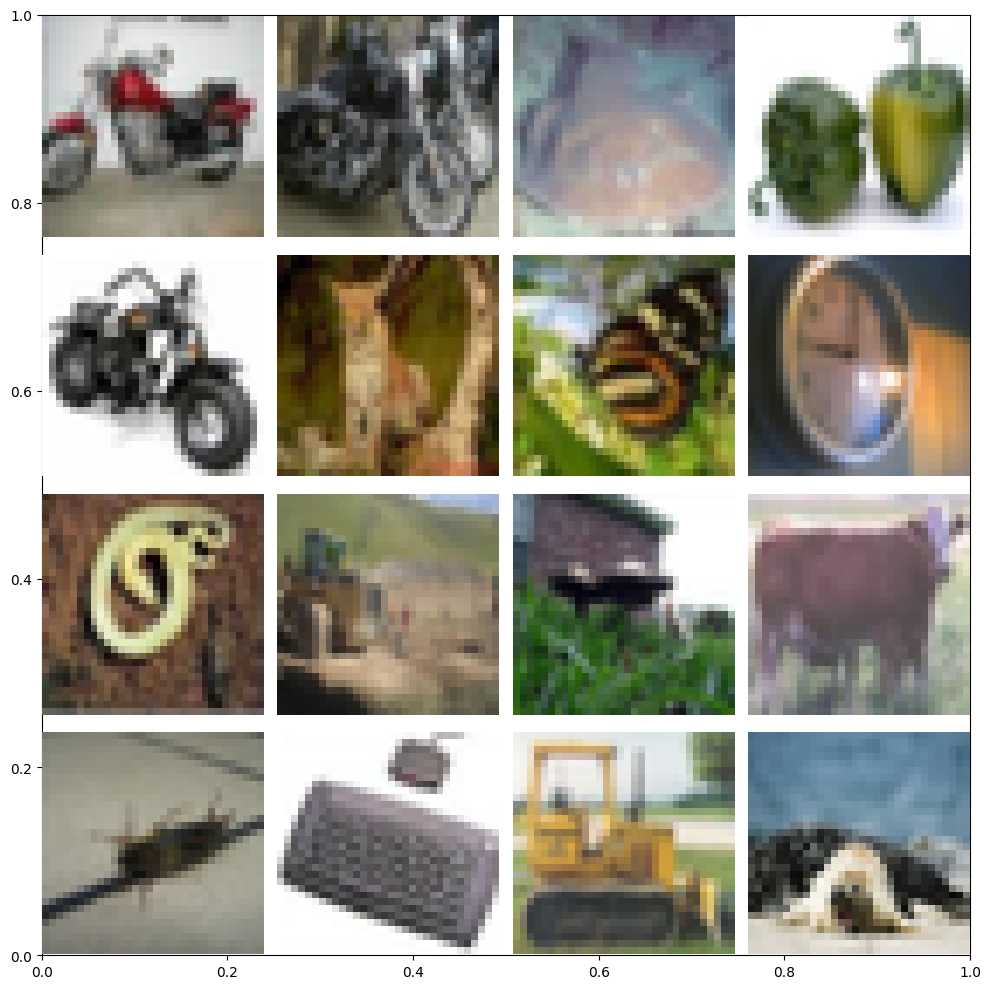

labels[14092].shape: (1,)
imgs[14092].shape: (32, 32, 3)


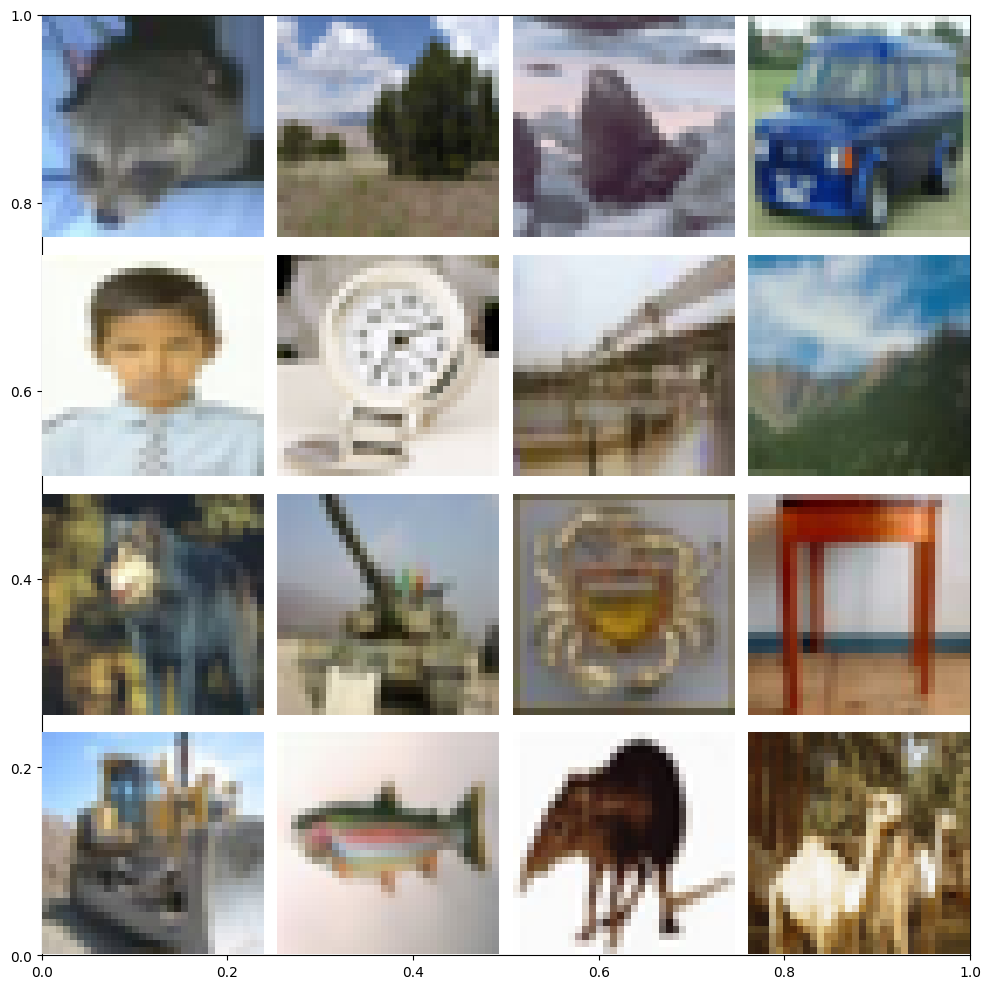

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


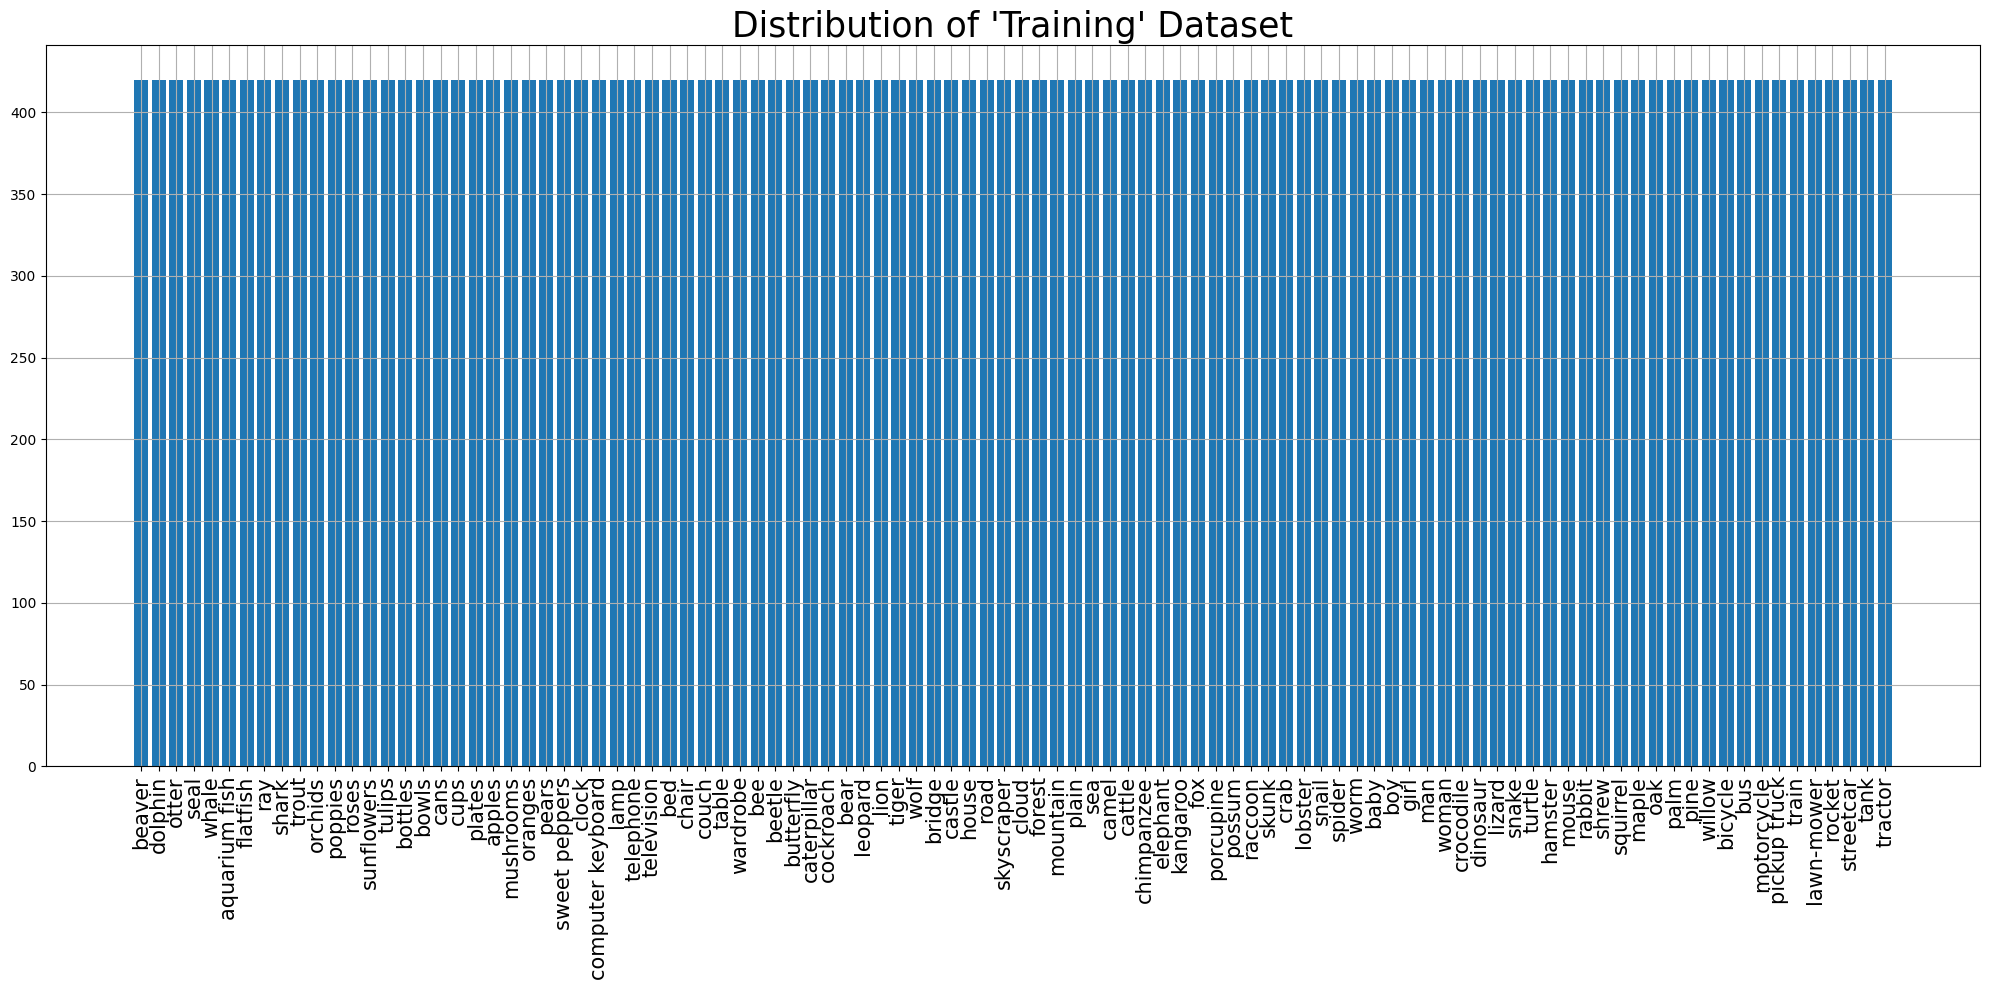

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


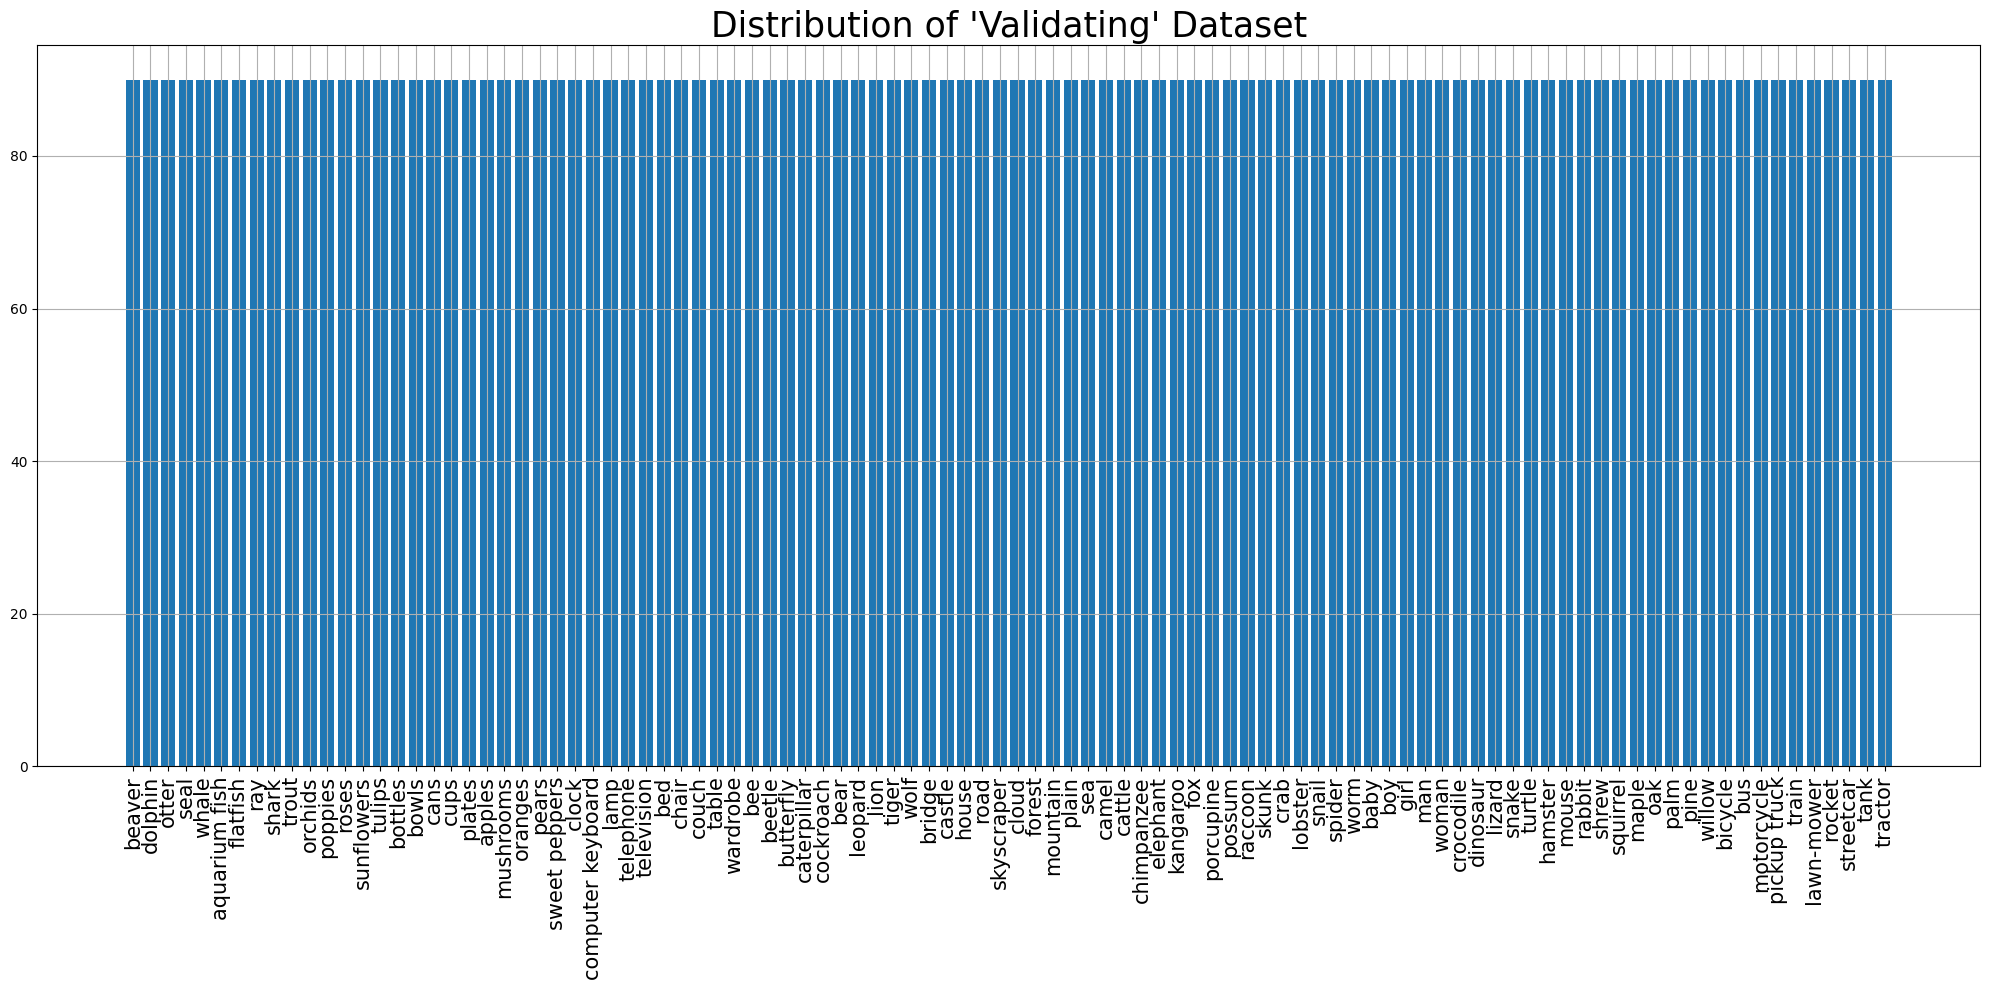

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


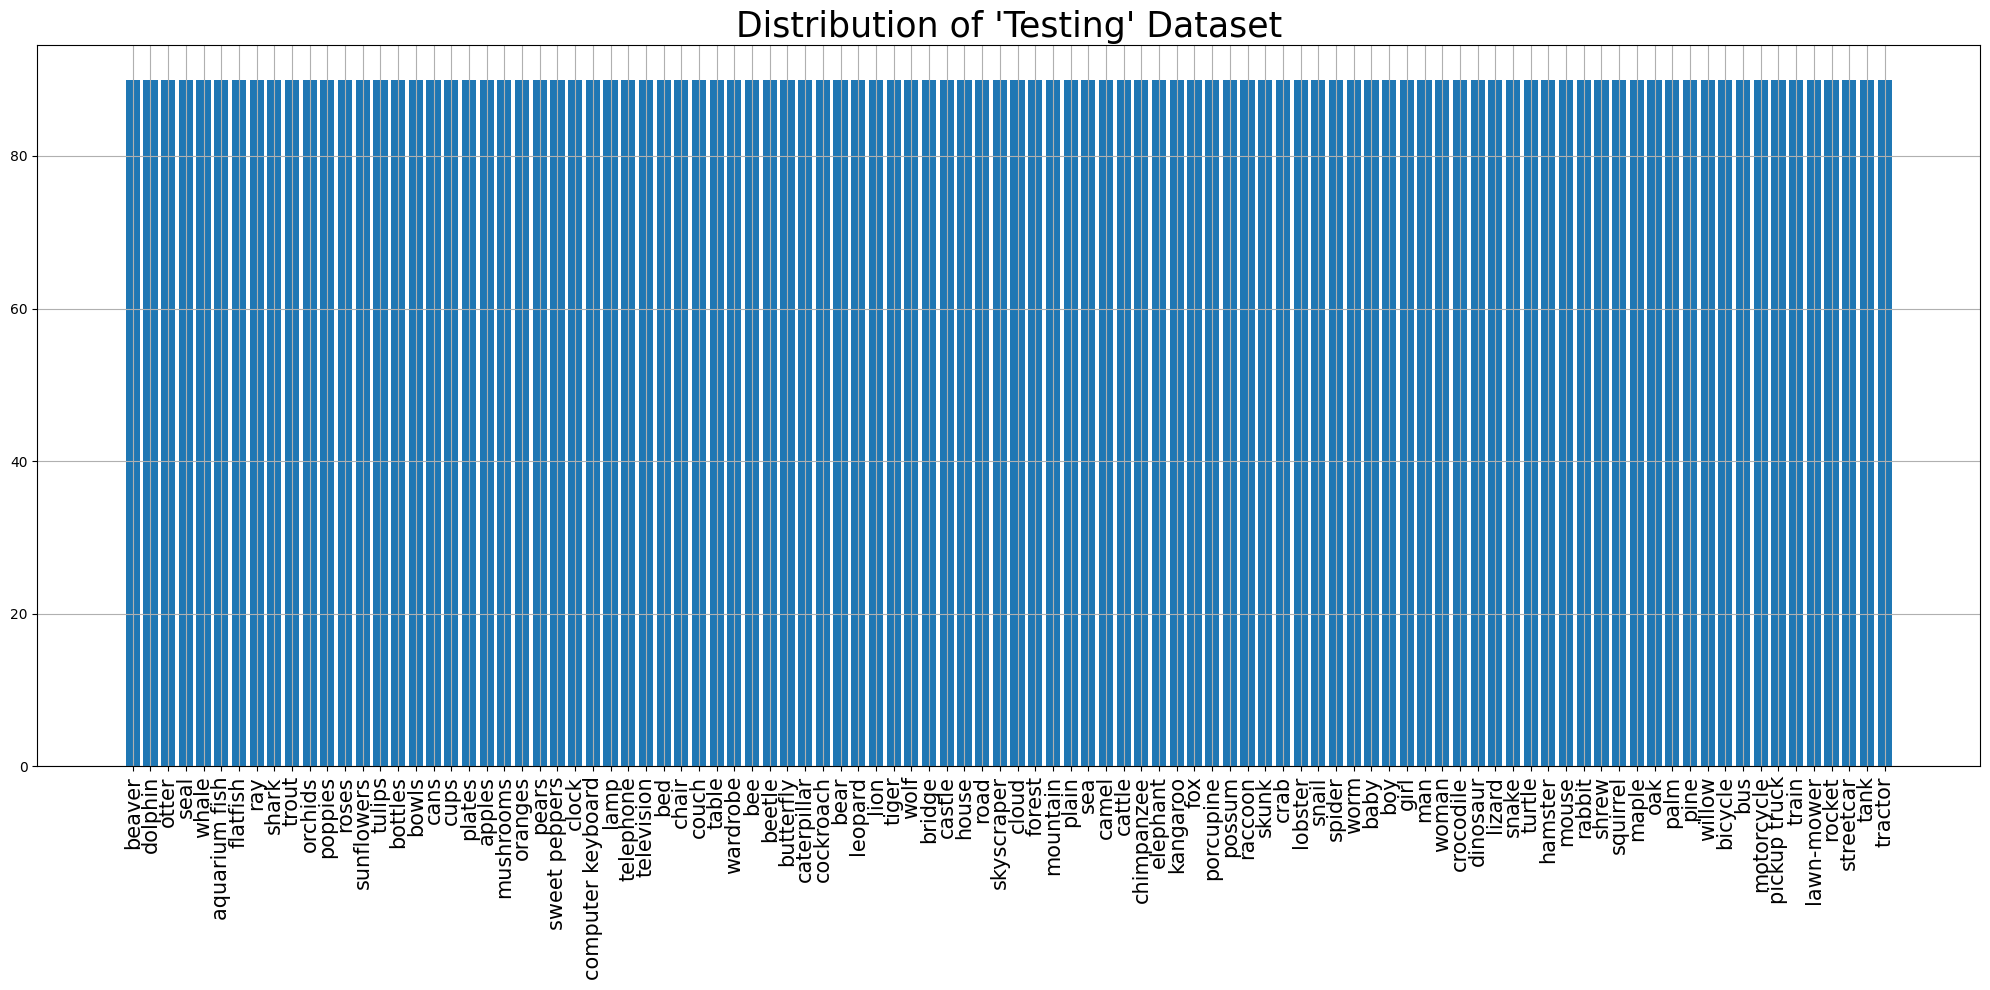

Training dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Validation dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Testing dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)
<class 'tuple'>
2
<class 'tensorflow.python.framework.ops.EagerTensor'> <class 'tensorflow.python.framework.ops.EagerTensor'>
(64, 224, 224, 3)
(64, 100)
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 100)
2
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(64, 224, 224, 3) (6

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,665,188 (94.09 MB)

 Trainable params: 1,100,388 (4.20 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/25
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3538 - f1_score: 0.3488 - loss: 2.6949 - precision: 0.6913
Epoch 1: val_loss improved from inf to 1.47143, saving model to best_model_v4.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.3539 - f1_score: 0.3489 - loss: 2.6941 - precision: 0.6914 - val_accuracy: 0.5913 - val_f1_score: 0.5871 - val_loss: 1.4714 - val_precision: 0.8048 - learning_rate: 0.0010
Epoch 2/25
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5662 - f1_score: 0.5623 - loss: 1.5745 - precision: 0.7630
Epoch 2: val_loss improved from 1.47143 to 1.37340, saving model to best_model_v4.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.5662 - f1_score: 0.5624 - loss: 1.5743 - precision: 0.7630 - val_accuracy: 0.6134 - val_f1_score: 0.6096 - val_loss: 1.3734 - val_precision: 0.8034 - learning_rate: 0.0010
Epoch 3/25
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6028 - f1_score: 0.5997 - loss: 1.3842 - precision:

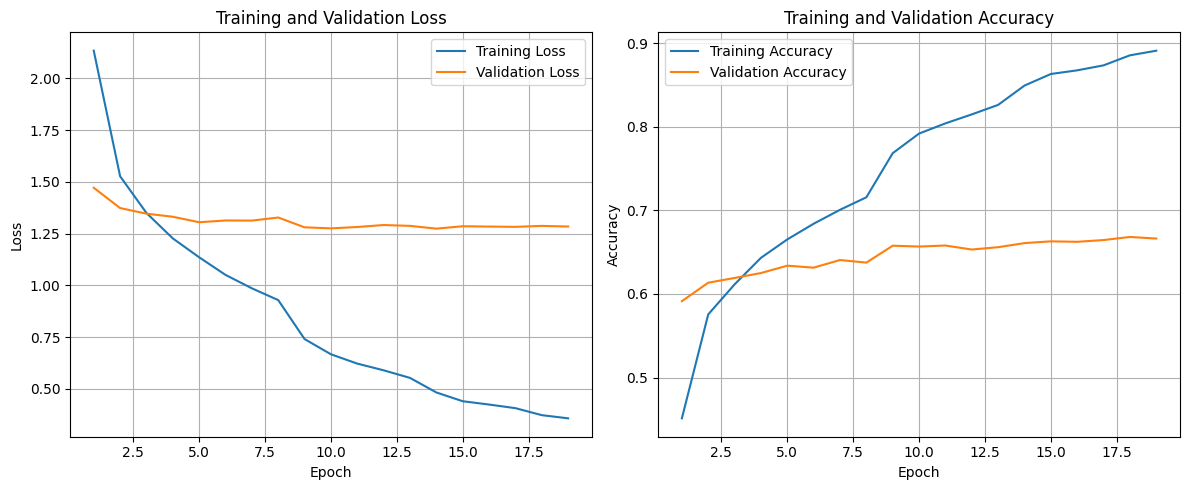

141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.6545 - f1_score: 0.6467 - loss: 1.3005 - precision: 0.7638
Test Accuracy: 66.28%
Test Loss: 1.2741423845291138
Test Precision: 77.12%
Test F1 Scores (Per Class): [85.405396 78.07486  55.789463 49.999992 40.211636 69.87952  61.458332
 69.47368  79.768776 77.24867  66.666664 43.575413 71.856285 57.777775
 67.92453  62.72189  78.723404 77.15736  59.113293 58.682625 83.422455
 78.49462  79.78141  79.775276 83.798874 68.888885 47.727264 44.692734
 80.22598  65.14285  62.72189  69.27374  50.299393 57.731956 68.42105
 29.999996 70.05649  59.685856 54.117645 88.888885 67.3913   80.628265
 62.06896  70.05649  48.756214 51.64835  46.92737  58.139526 81.72042
 82.68156  34.285706 75.28088  64.921455 88.50574  72.04301  42.28571
 83.24323  78.02197  79.75459  60.1227   77.34807  69.430046 68.263466
 65.88235  45.783127 59.036137 62.650597 59.886997 86.02149  83.59788
 70.303024 76.92307  44.444443 62.29508  37.349392 82.41757  87.91208
 57.1

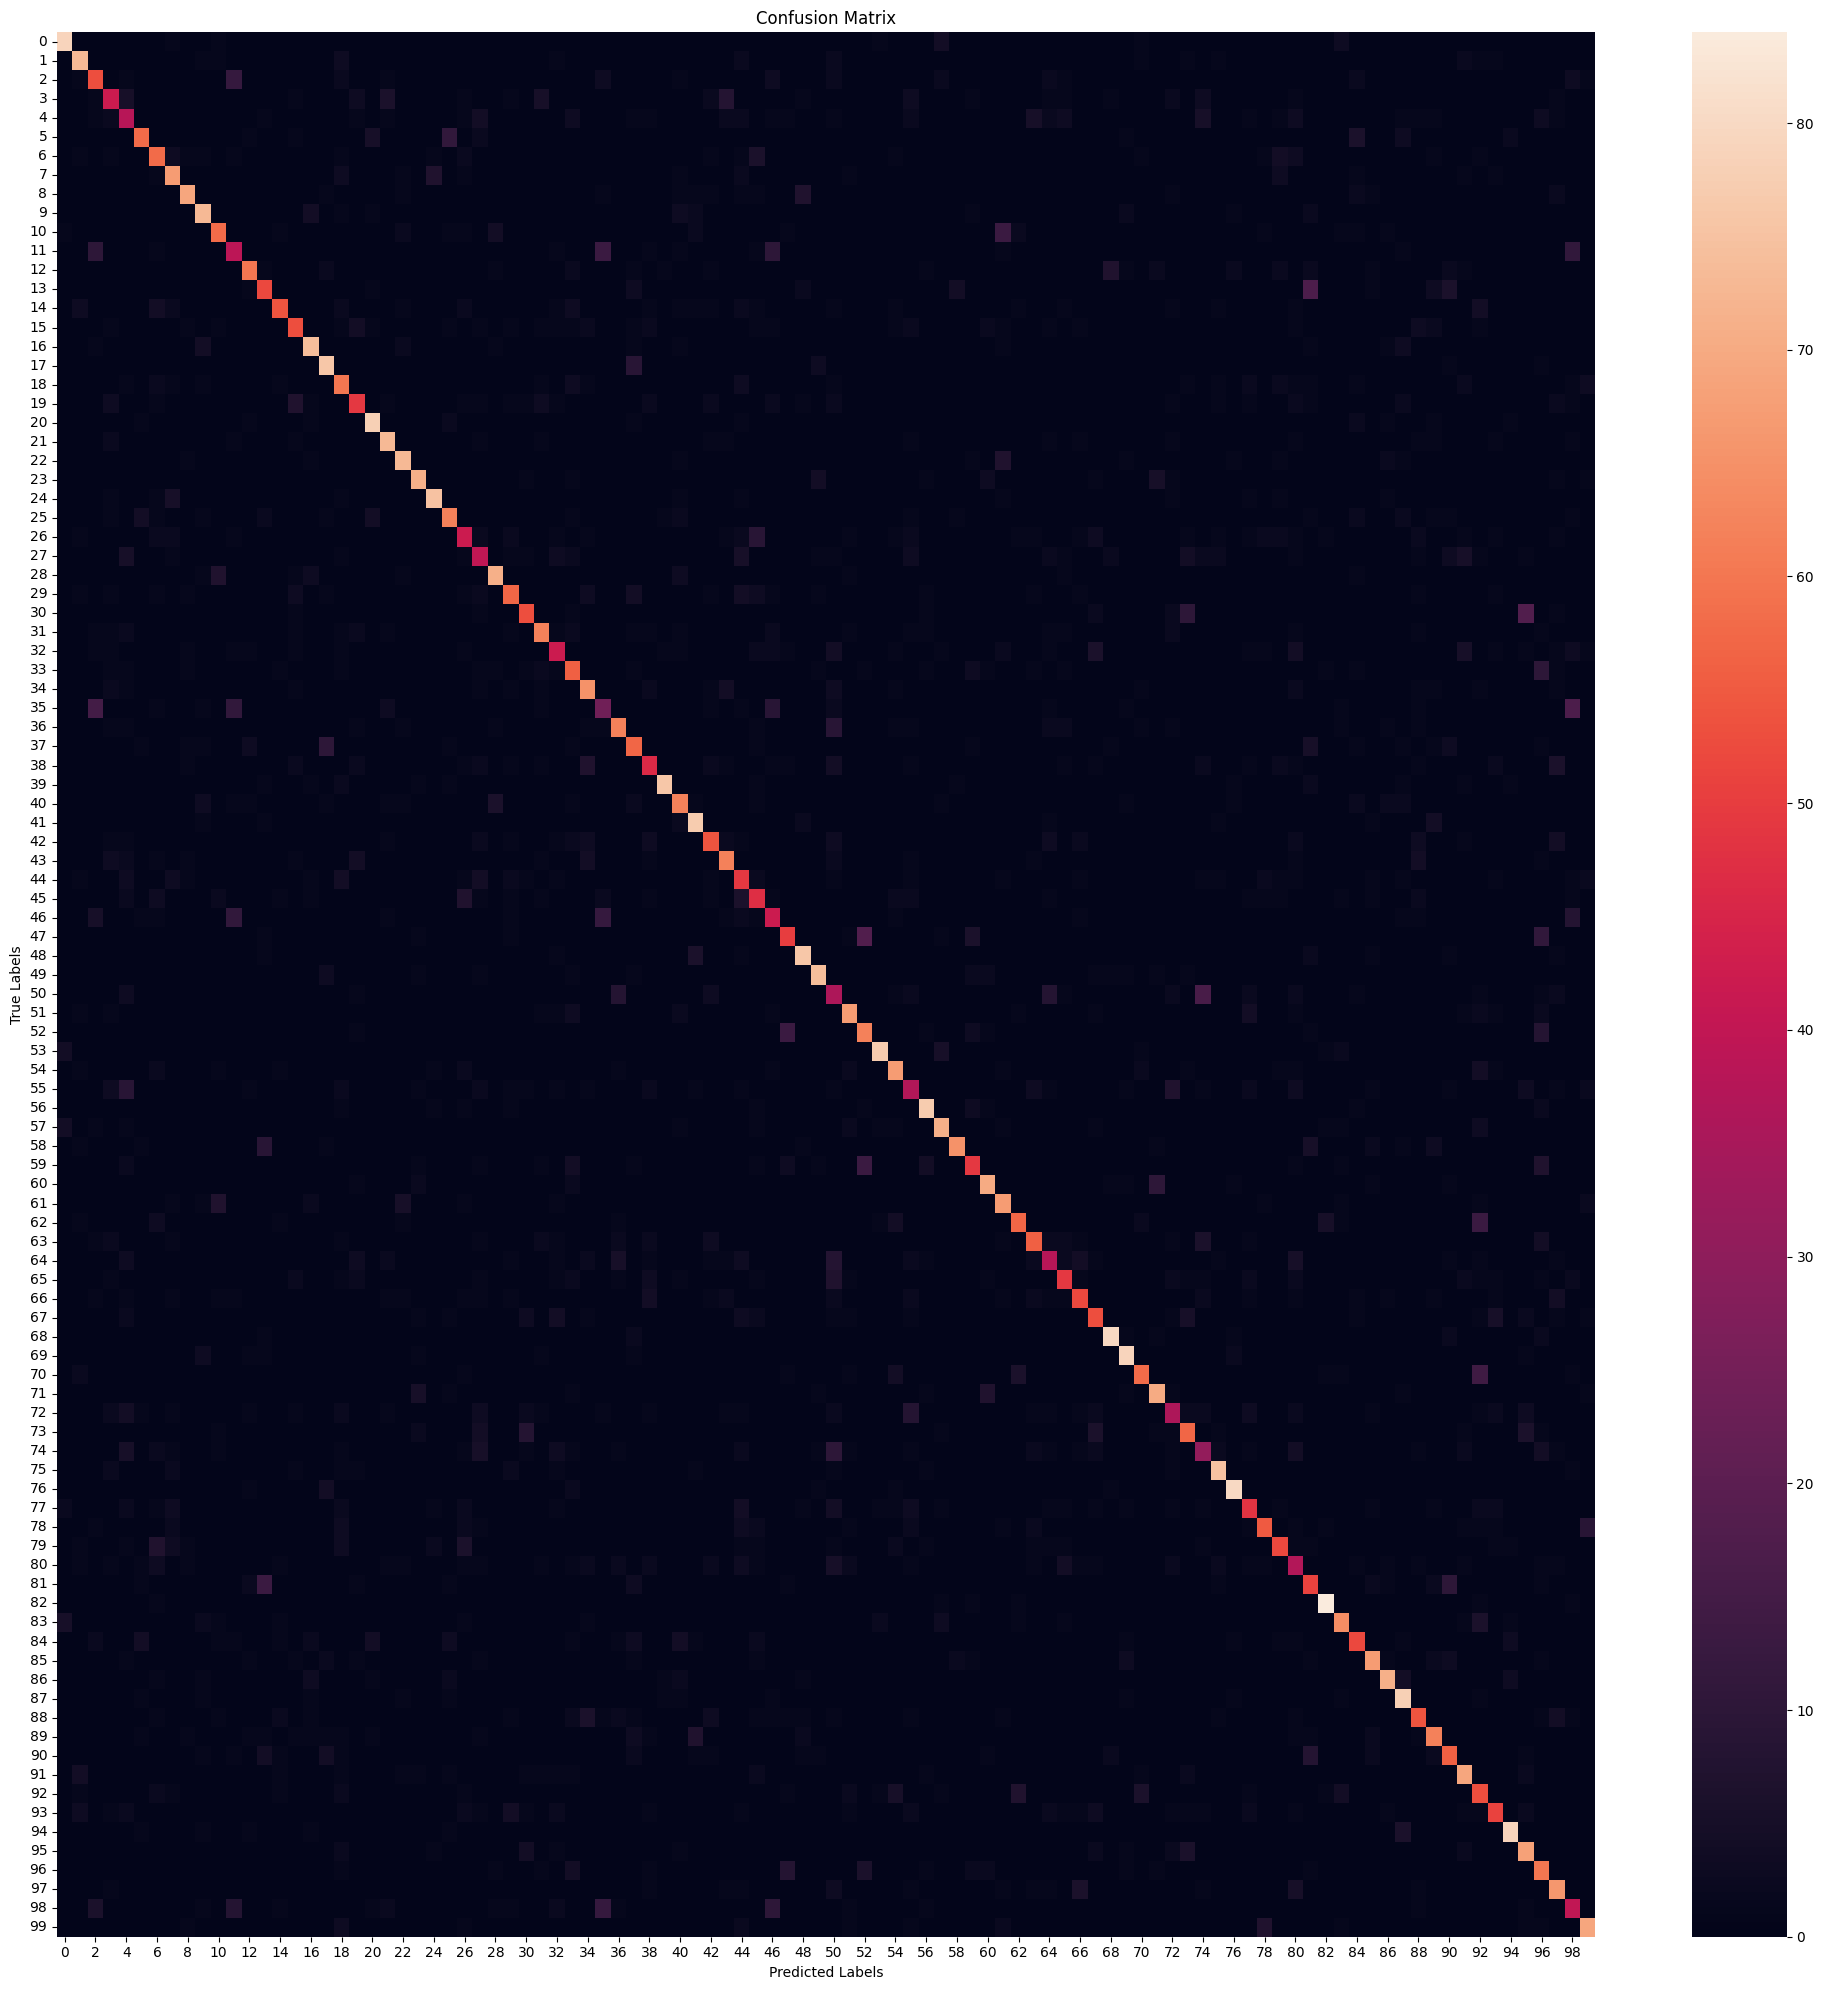

                   precision    recall  f1-score   support

           beaver       0.83      0.88      0.85        90
          dolphin       0.75      0.81      0.78        90
            otter       0.53      0.59      0.56        90
             seal       0.54      0.47      0.50        90
            whale       0.38      0.42      0.40        90
    aquarium fish       0.76      0.64      0.70        90
         flatfish       0.57      0.64      0.61        90
              ray       0.66      0.74      0.70        90
            shark       0.83      0.77      0.80        90
            trout       0.74      0.81      0.77        90
          orchids       0.69      0.64      0.67        90
          poppies       0.44      0.43      0.44        90
            roses       0.78      0.67      0.72        90
       sunflowers       0.58      0.58      0.58        90
           tulips       0.78      0.60      0.68        90
          bottles       0.66      0.59      0.62       

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,665,188 (94.09 MB)

 Trainable params: 1,100,388 (4.20 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/25
1313/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8433 - f1_score: 0.8424 - loss: 0.5059 - precision: 0.9082
Epoch 1: val_loss improved from inf to 1.25277, saving model to best_model_fine_tune_v4.keras
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 55s 34ms/step - accuracy: 0.8432 - f1_score: 0.8424 - loss: 0.5060 - precision: 0.9082 - val_accuracy: 0.6617 - val_f1_score: 0.6607 - val_loss: 1.2528 - val_precision: 0.7727 - learning_rate: 1.0000e-05
Epoch 2/25
1313/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8565 - f1_score: 0.8555 - loss: 0.4757 - precision: 0.9209
Epoch 2: val_loss improved from 1.25277 to 1.24883, saving model to best_model_fine_tune_v4.keras
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - accuracy: 0.8564 - f1_score: 0.8555 - loss: 0.4758 - precision: 0.9209 - val_accuracy: 0.6637 - val_f1_score: 0.6627 - val_loss: 1.2488 - val_precision: 0.7736 - learning_rate: 1.0000e-05
Epoch 3/25
1312/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8572 - f1_sco

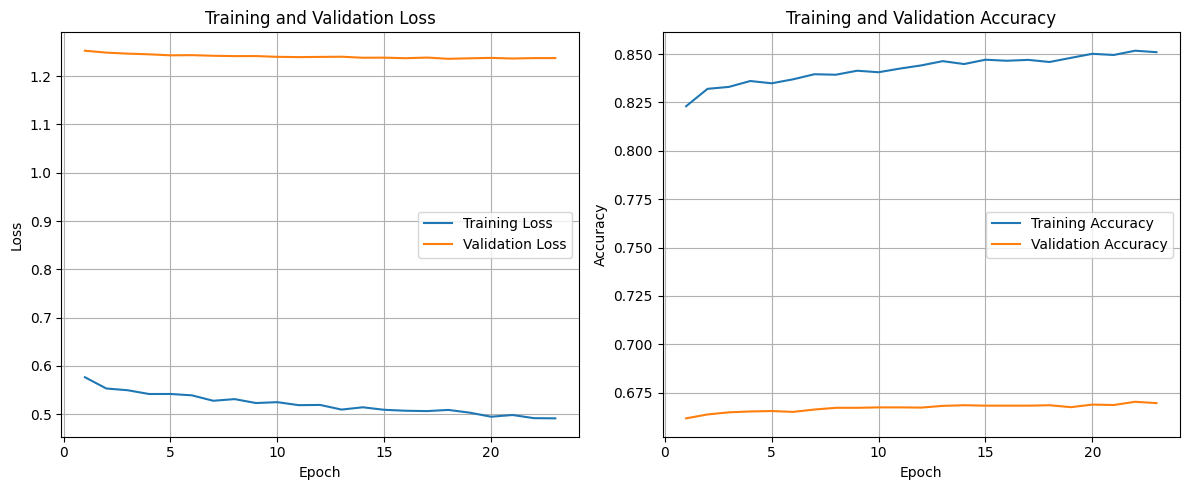

141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6623 - f1_score: 0.6541 - loss: 1.2552 - precision: 0.7754
Test Accuracy: 67.08%
Test Loss: 1.2318534851074219
Test Precision: 78.07%
Test F1 Scores (Per Class): [86.81318  77.948715 54.639168 50.847454 38.91891  72.04301  60.31745
 71.428566 82.75862  81.60919  64.44444  42.352932 70.93022  60.571426
 67.46988  60.227264 82.35293  78.12499  63.387978 56.140347 83.87096
 78.30688  81.481476 80.459755 82.22221  67.85713  51.685387 45.595848
 79.54544  70.58823  65.49707  66.27907  51.497    59.66851  71.428566
 34.883713 71.91011  60.33519  58.333324 89.41175  67.01031  82.16216
 62.63736  70.520226 47.05882  50.267376 48.235287 60.919537 81.91489
 81.52173  37.931026 77.173904 64.51612  87.49999  69.95074  44.571423
 85.22727  77.31957  82.352936 56.97674  79.329605 71.00591  62.569828
 65.55555  48.235287 56.66666  64.36781  61.176468 87.23404  84.81675
 68.263466 79.14438  43.02325  64.210526 43.02325  83.69564  88.52458
 57.14

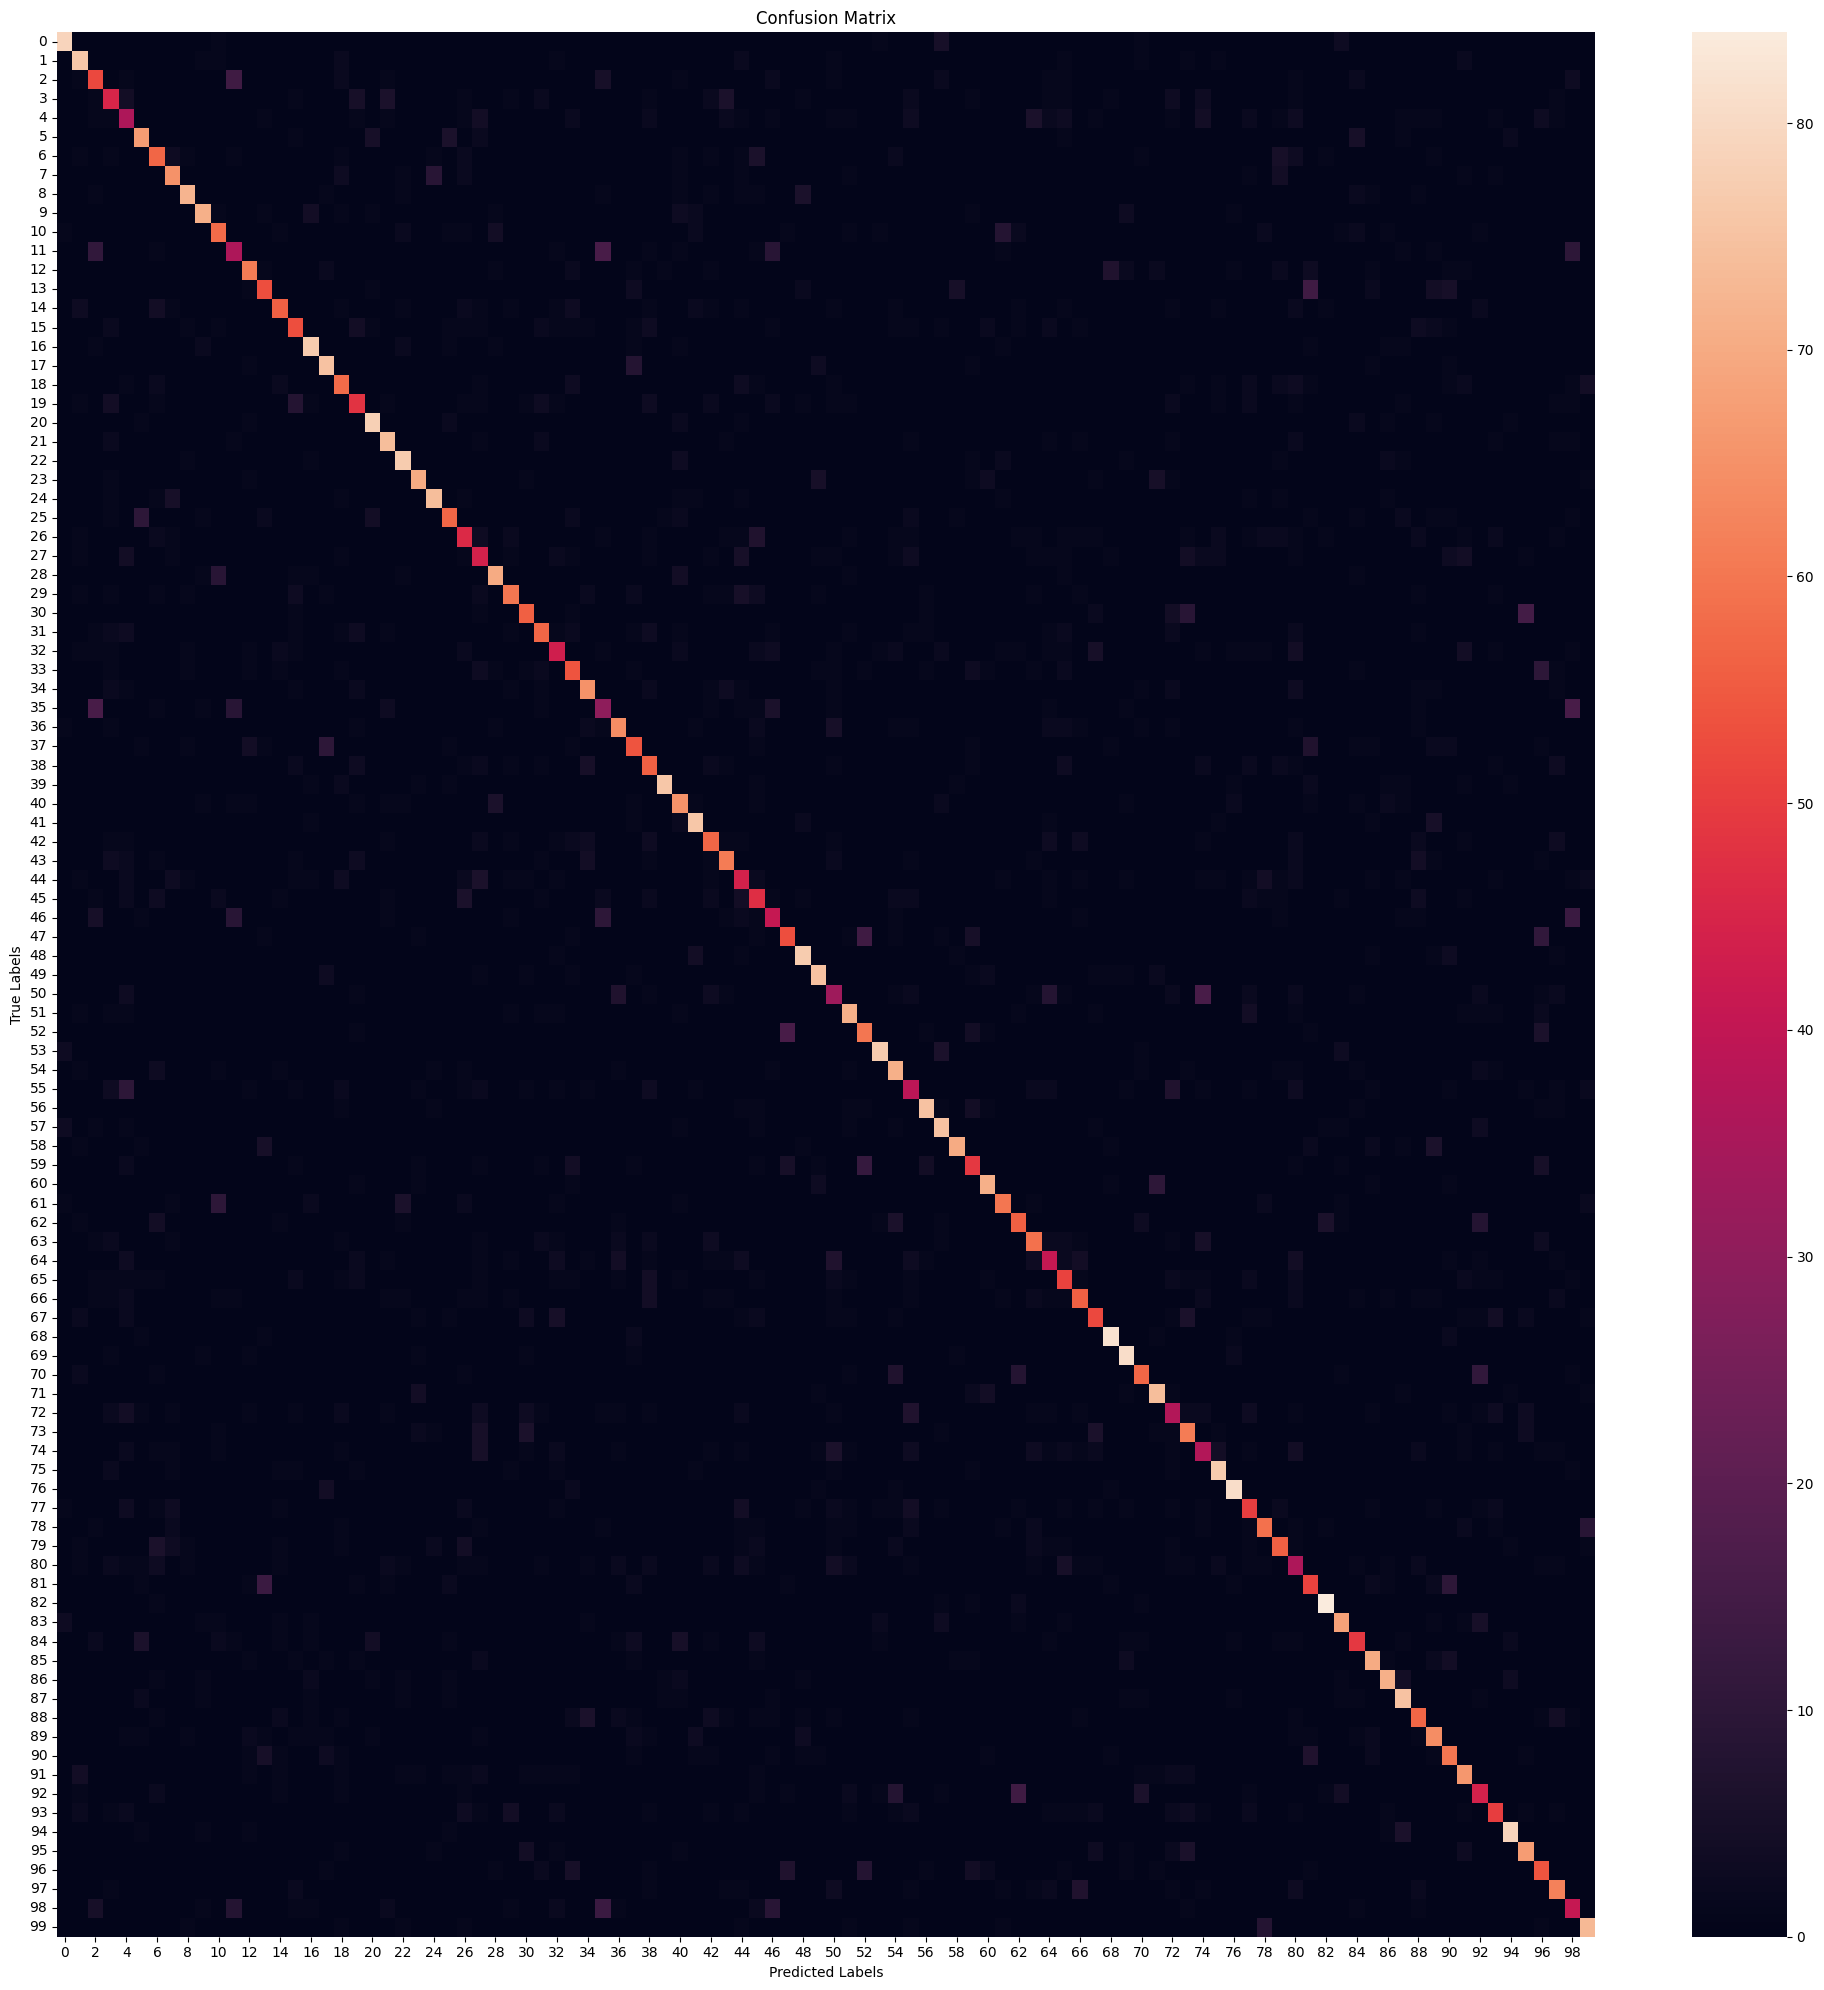

                   precision    recall  f1-score   support

           beaver       0.86      0.88      0.87        90
          dolphin       0.73      0.84      0.78        90
            otter       0.50      0.58      0.54        90
             seal       0.52      0.50      0.51        90
            whale       0.38      0.40      0.39        90
    aquarium fish       0.70      0.74      0.72        90
         flatfish       0.58      0.63      0.60        90
              ray       0.71      0.72      0.71        90
            shark       0.86      0.80      0.83        90
            trout       0.85      0.79      0.82        90
          orchids       0.64      0.64      0.64        90
          poppies       0.44      0.40      0.42        90
            roses       0.74      0.68      0.71        90
       sunflowers       0.62      0.59      0.61        90
           tulips       0.74      0.62      0.67        90
          bottles       0.62      0.59      0.60       

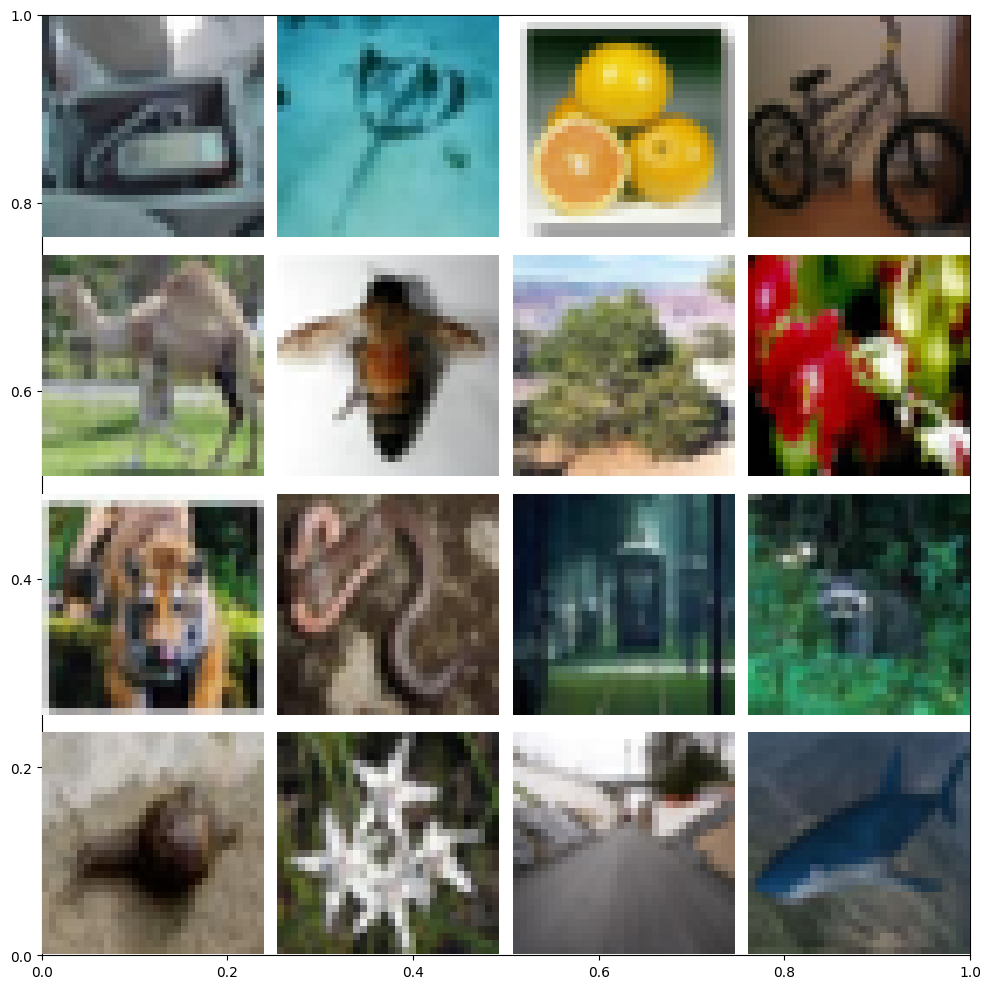

labels[34835].shape: (1,)
imgs[34835].shape: (32, 32, 3)


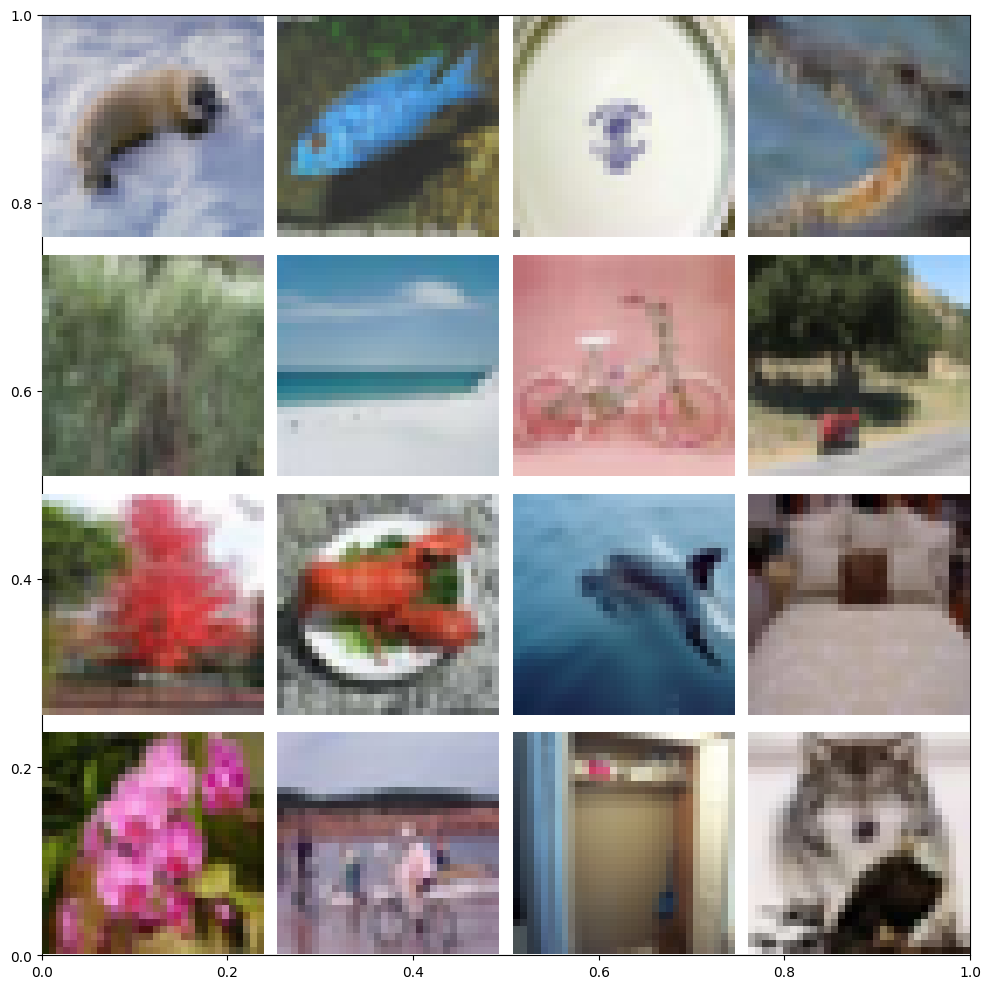

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


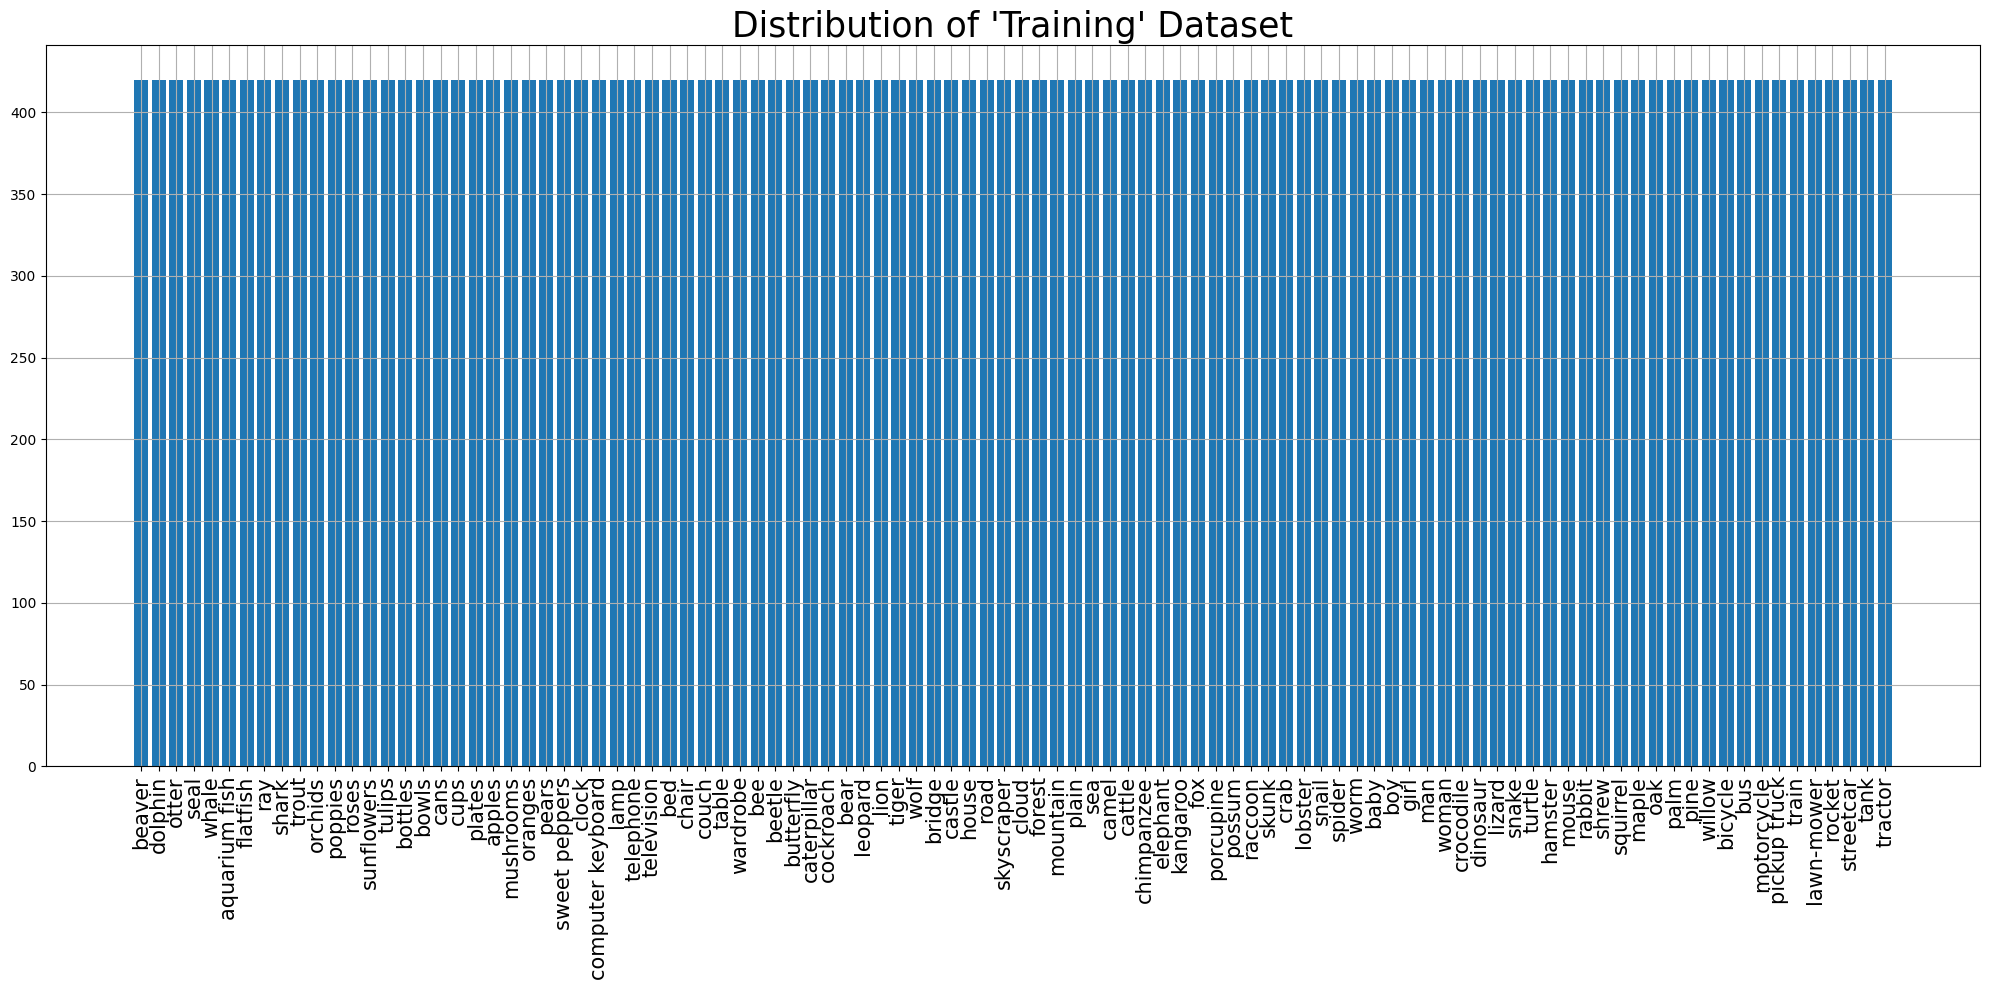

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


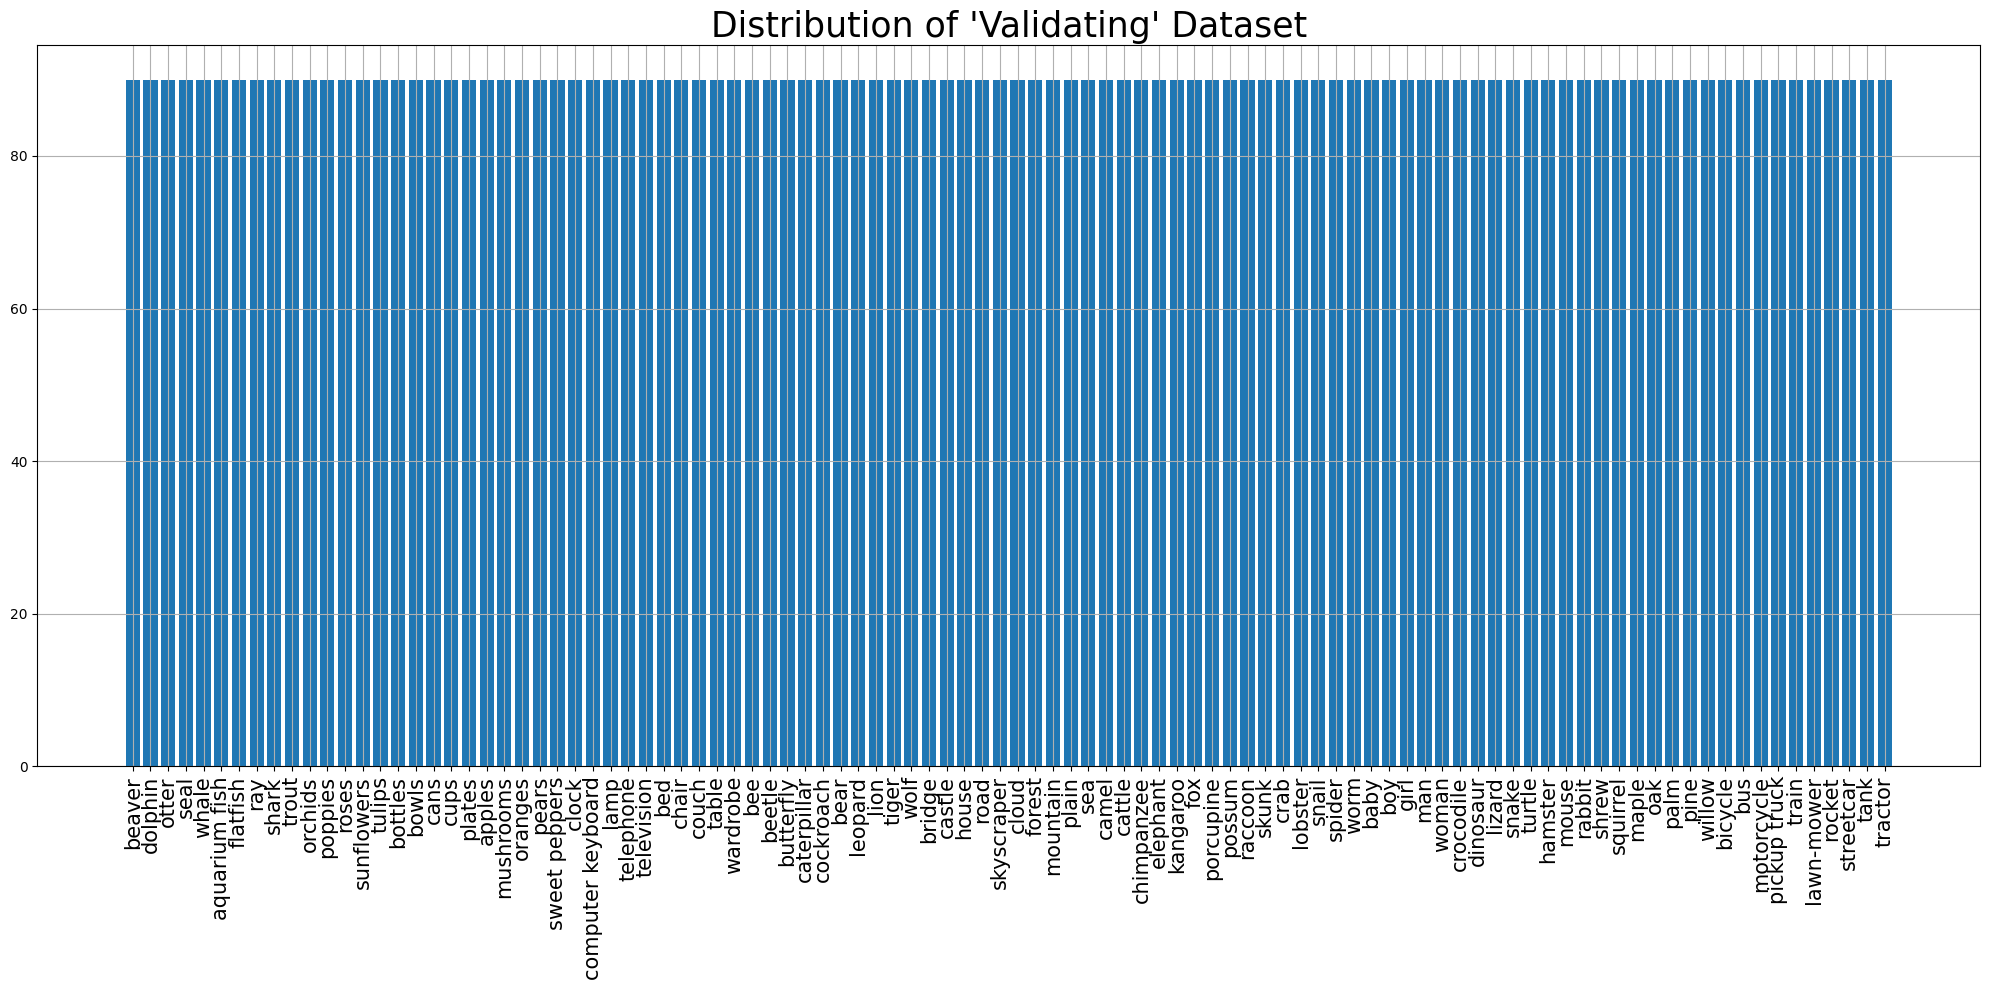

<ipython-input-4-78561581887d>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


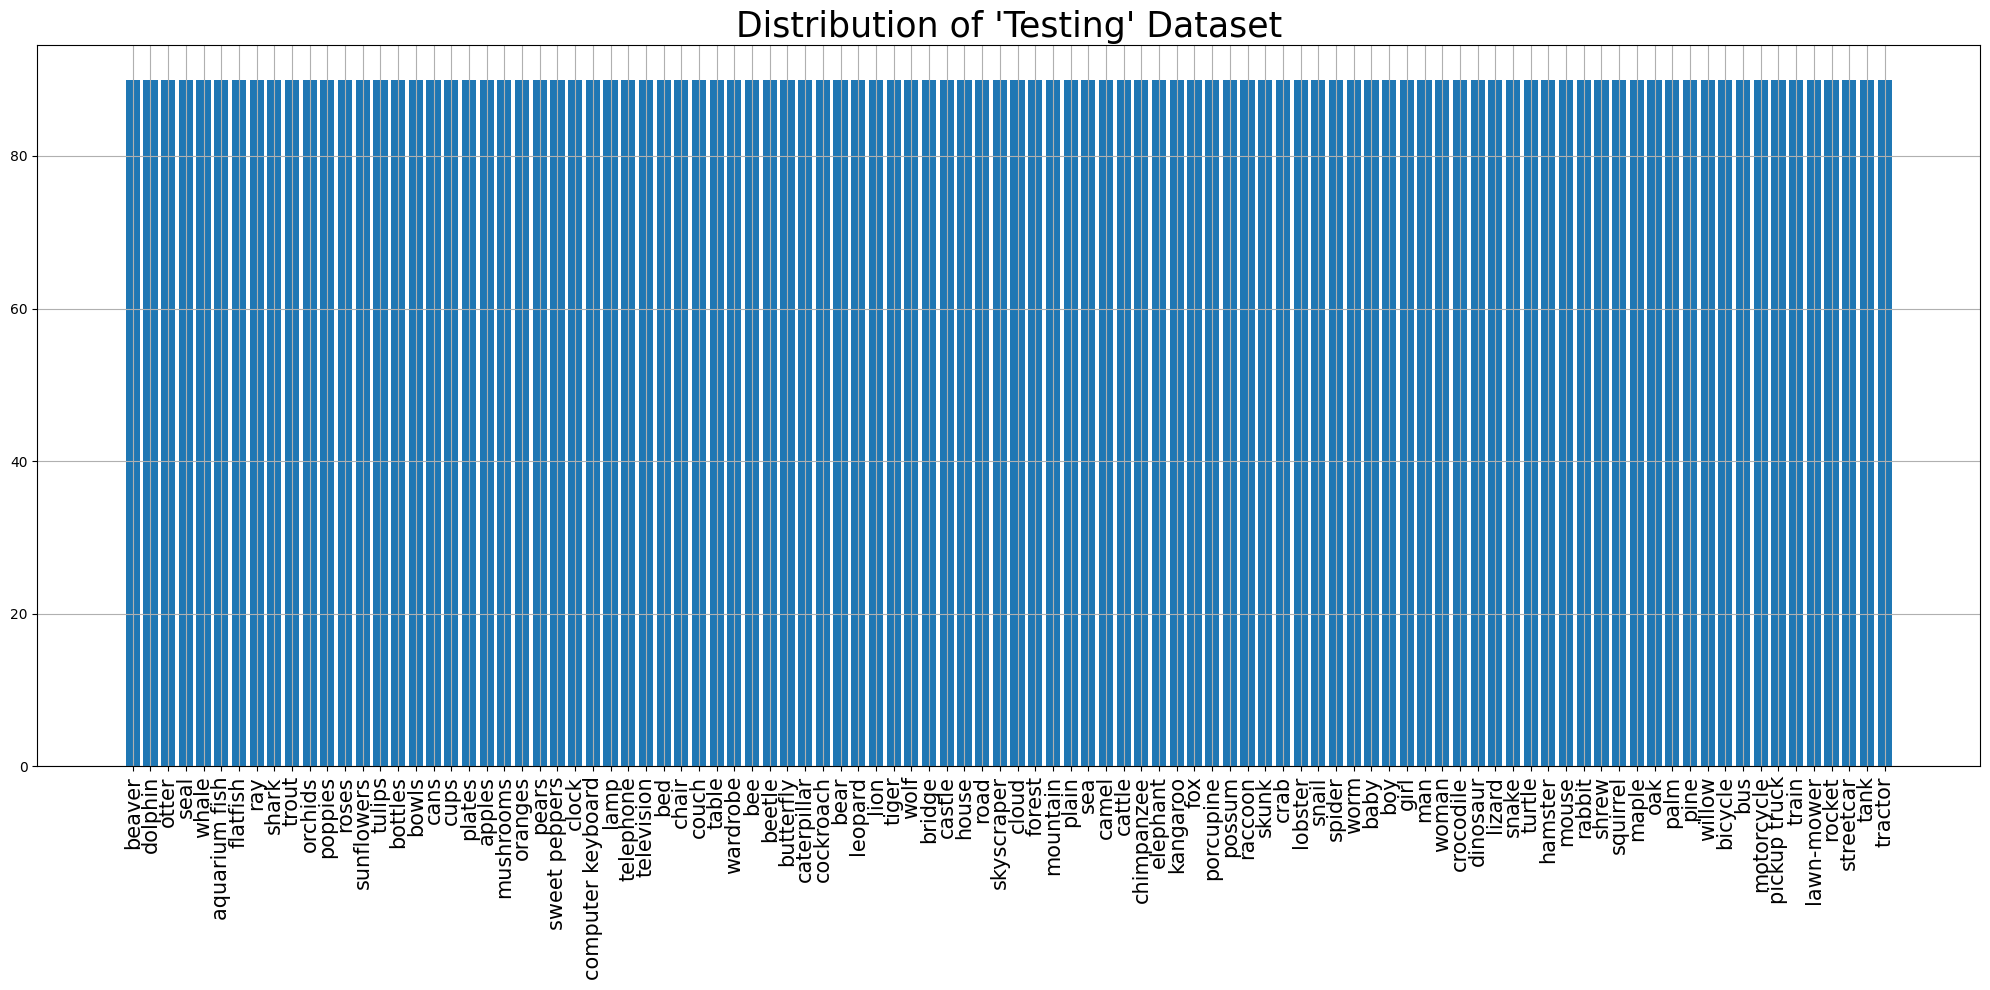

Training dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Validation dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Testing dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)
<class 'tuple'>
2
<class 'tensorflow.python.framework.ops.EagerTensor'> <class 'tensorflow.python.framework.ops.EagerTensor'>
(64, 224, 224, 3)
(64, 100)
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 100)
2
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(64, 224, 224, 3) (6

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_5           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,665,188 (94.09 MB)

 Trainable params: 1,100,388 (4.20 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/25
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3549 - f1_score: 0.3505 - loss: 2.6885 - precision: 0.6847
Epoch 1: val_loss improved from inf to 1.47821, saving model to best_model_v4.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.3551 - f1_score: 0.3507 - loss: 2.6876 - precision: 0.6848 - val_accuracy: 0.5862 - val_f1_score: 0.5806 - val_loss: 1.4782 - val_precision: 0.7955 - learning_rate: 0.0010
Epoch 2/25
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5645 - f1_score: 0.5611 - loss: 1.5718 - precision: 0.7656
Epoch 2: val_loss improved from 1.47821 to 1.36866, saving model to best_model_v4.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.5645 - f1_score: 0.5611 - loss: 1.5717 - precision: 0.7656 - val_accuracy: 0.6181 - val_f1_score: 0.6139 - val_loss: 1.3687 - val_precision: 0.8056 - learning_rate: 0.0010
Epoch 3/25
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6068 - f1_score: 0.6032 - loss: 1.3731 - precision:

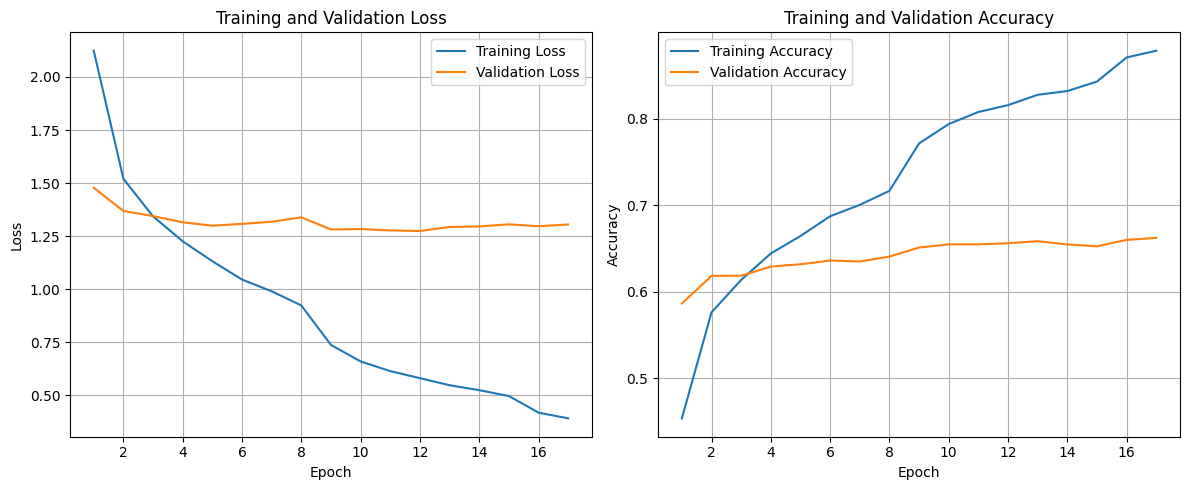

141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6479 - f1_score: 0.6398 - loss: 1.2926 - precision: 0.7621
Test Accuracy: 65.99%
Test Loss: 1.2699257135391235
Test Precision: 77.05%
Test F1 Scores (Per Class): [87.42514  75.49018  53.038673 50.86705  40.659336 72.94117  62.569828
 68.39378  81.96721  83.33333  65.55555  42.937847 71.95121  60.227264
 67.83625  64.44444  79.787224 77.08333  62.499992 56.969696 78.02197
 74.444435 82.68156  79.761894 83.51647  65.60846  49.197857 49.0566
 76.50272  69.23077  61.290314 68.53932  49.162006 57.142853 62.5641
 32.298134 71.428566 59.067356 50.51546  90.17341  71.16564  83.798874
 58.441555 69.090904 47.66839  51.336895 50.526314 53.40909  82.872925
 79.347824 42.391296 72.41379  58.883244 88.63635  70.14217  35.555546
 78.61271  70.243904 76.543205 57.309933 80.92485  72.222206 64.51612
 67.07316  51.572315 58.385086 70.80744  58.064507 86.18784  86.20689
 68.35443  74.6114   36.363632 59.428566 35.22012  79.58114  85.56149
 55.7575

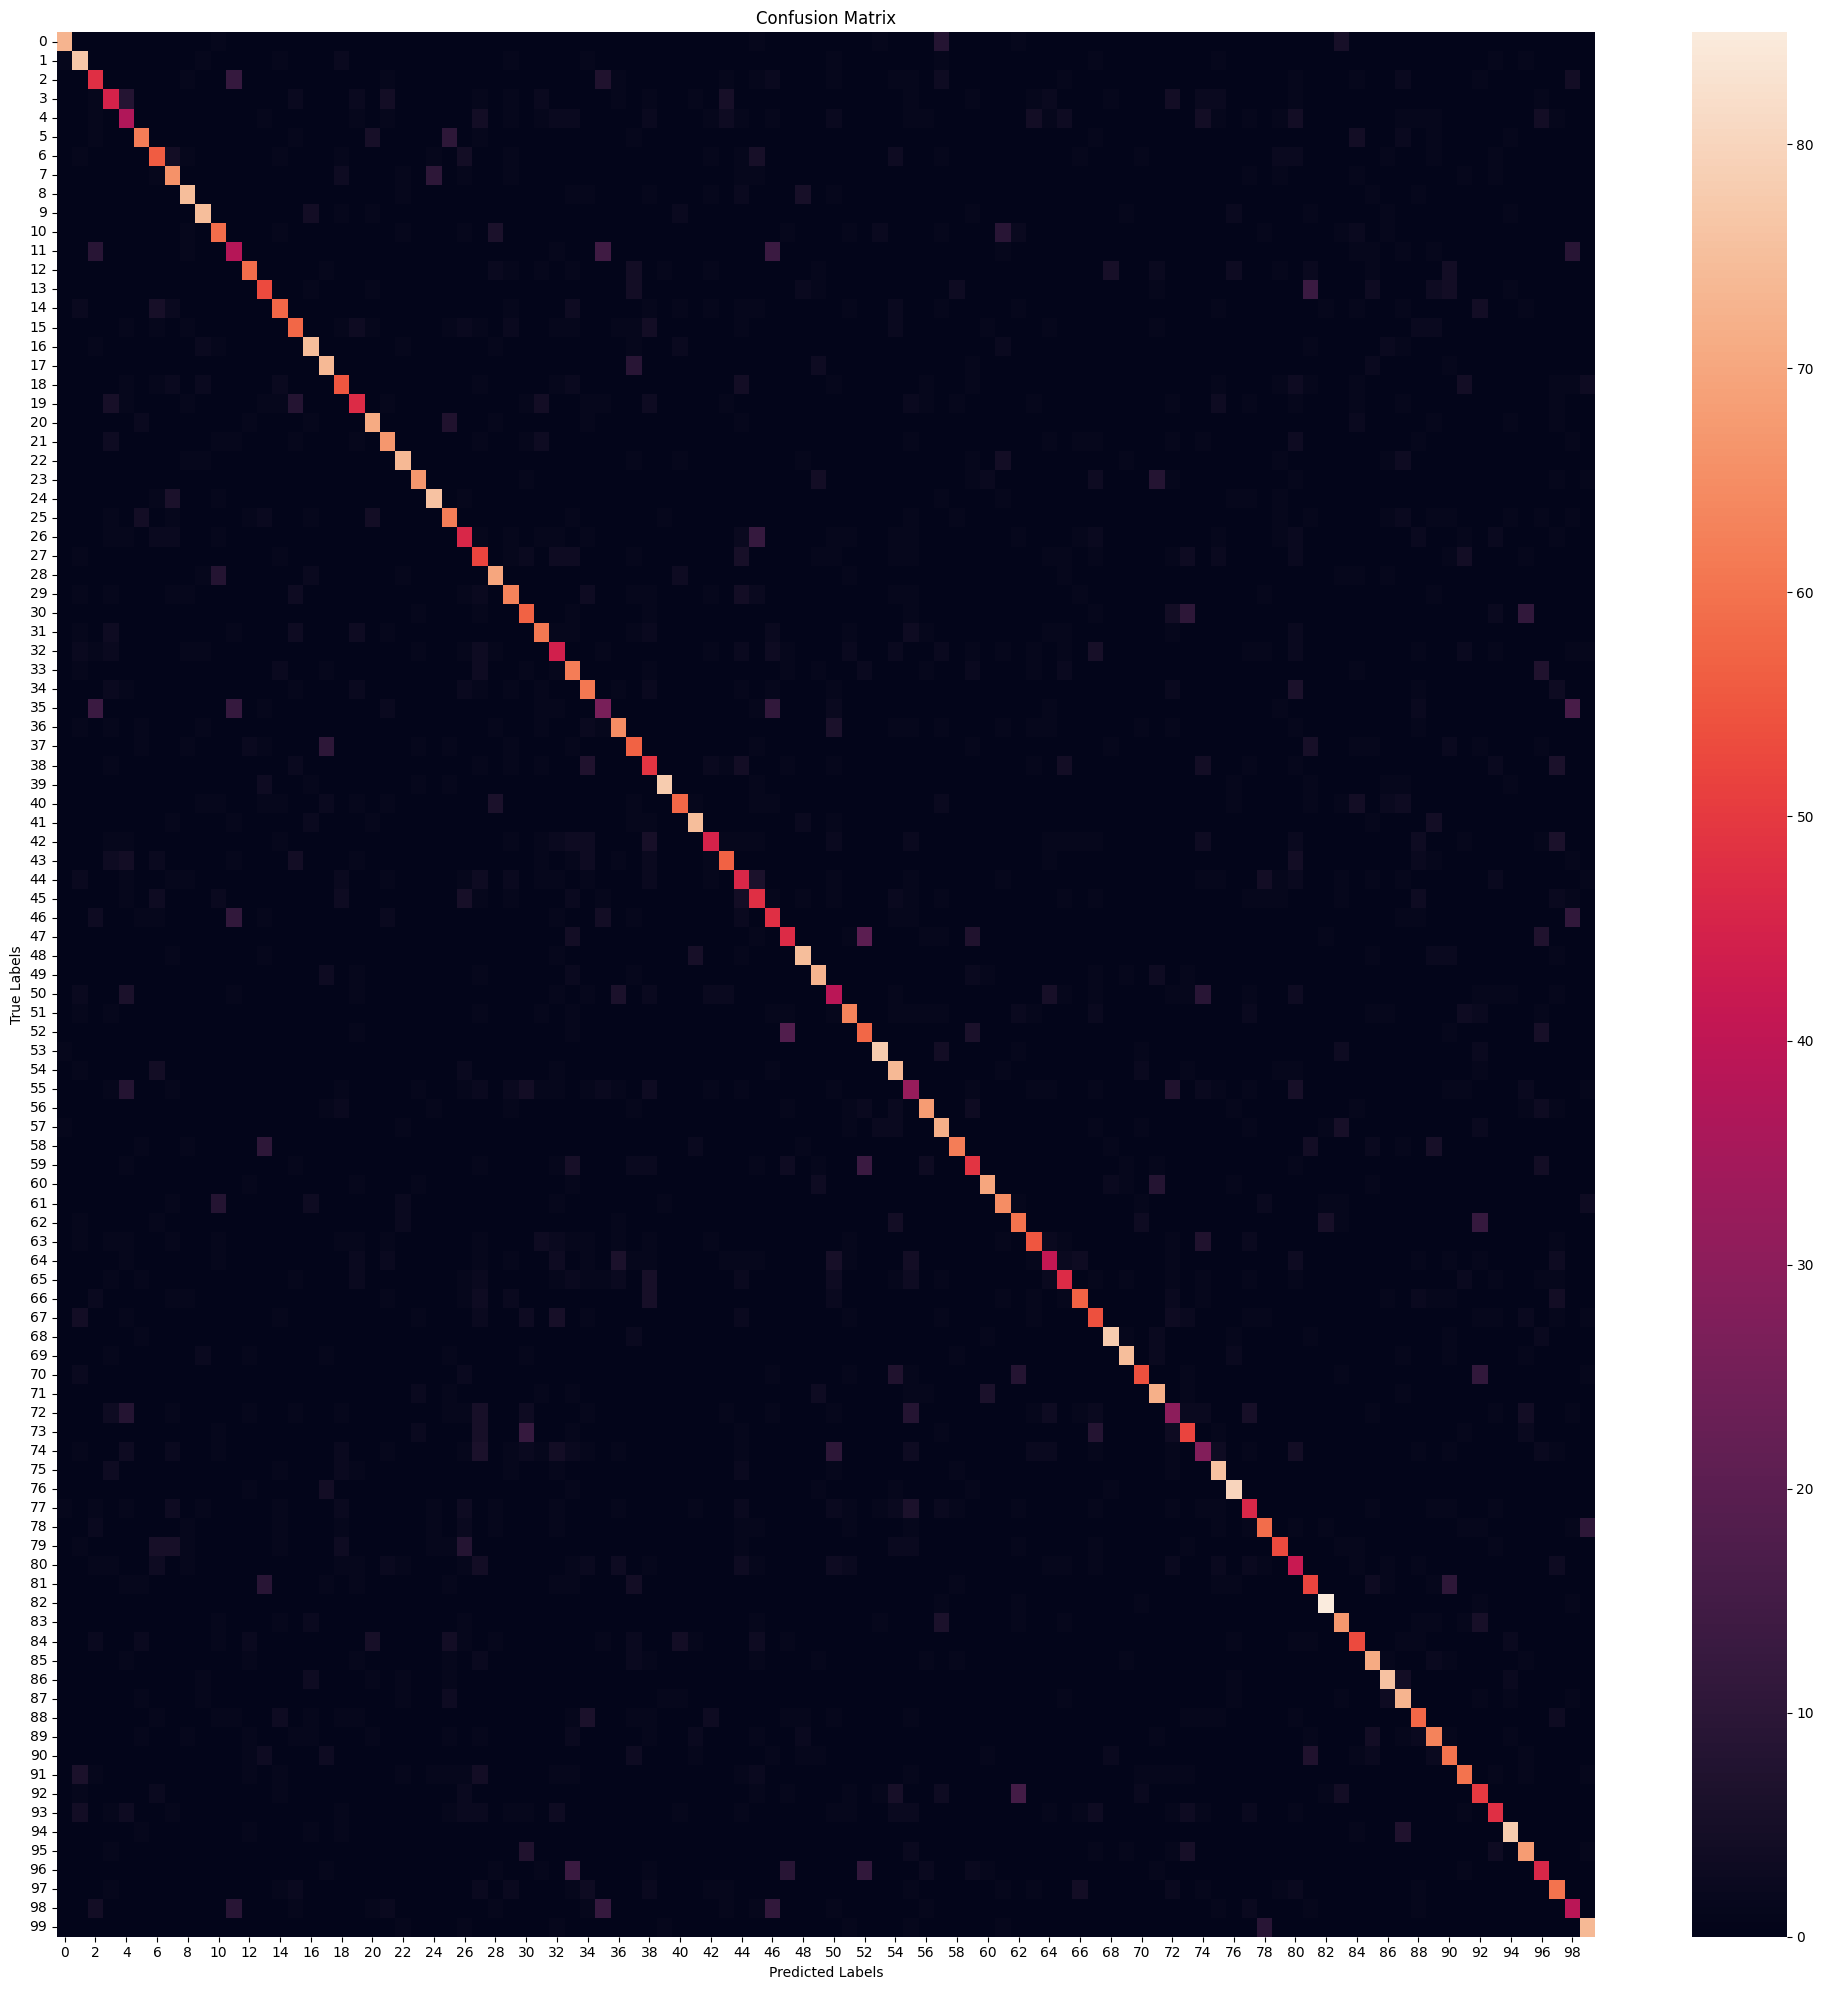

                   precision    recall  f1-score   support

           beaver       0.95      0.81      0.87        90
          dolphin       0.68      0.86      0.75        90
            otter       0.53      0.53      0.53        90
             seal       0.54      0.50      0.52        90
            whale       0.40      0.41      0.41        90
    aquarium fish       0.78      0.69      0.73        90
         flatfish       0.63      0.62      0.63        90
              ray       0.64      0.73      0.68        90
            shark       0.82      0.83      0.82        90
            trout       0.83      0.83      0.83        90
          orchids       0.66      0.66      0.66        90
          poppies       0.43      0.42      0.43        90
            roses       0.80      0.66      0.72        90
       sunflowers       0.61      0.59      0.60        90
           tulips       0.72      0.64      0.68        90
          bottles       0.64      0.64      0.64       

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_5           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,665,188 (94.09 MB)

 Trainable params: 1,100,388 (4.20 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8151 - f1_score: 0.8140 - loss: 0.5919 - precision: 0.8934
Epoch 1: val_loss improved from inf to 1.24255, saving model to best_model_fine_tune_v4.keras
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 55s 34ms/step - accuracy: 0.8151 - f1_score: 0.8140 - loss: 0.5919 - precision: 0.8934 - val_accuracy: 0.6620 - val_f1_score: 0.6606 - val_loss: 1.2426 - val_precision: 0.7788 - learning_rate: 1.0000e-05
Epoch 2/25
1313/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8356 - f1_score: 0.8347 - loss: 0.5408 - precision: 0.9078
Epoch 2: val_loss improved from 1.24255 to 1.23747, saving model to best_model_fine_tune_v4.keras
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - accuracy: 0.8356 - f1_score: 0.8347 - loss: 0.5409 - precision: 0.9078 - val_accuracy: 0.6644 - val_f1_score: 0.6629 - val_loss: 1.2375 - val_precision: 0.7812 - learning_rate: 1.0000e-05
Epoch 3/25
1313/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8391 - f1_sco

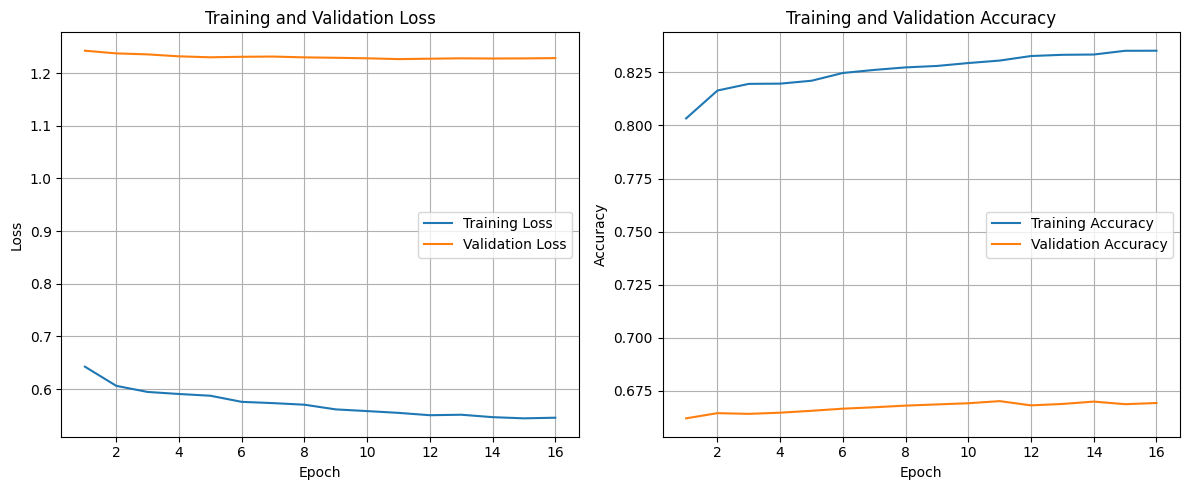

141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.6638 - f1_score: 0.6552 - loss: 1.2445 - precision: 0.7743
Test Accuracy: 67.17%
Test Loss: 1.2226710319519043
Test Precision: 78.19%
Test F1 Scores (Per Class): [86.36363  79.99999  57.14285  53.179188 43.478252 72.92817  61.538452
 69.61325  82.558136 84.090904 64.77273  44.44444  71.99999  62.352936
 69.71428  62.63736  80.64516  76.041664 61.01694  58.620686 80.64516
 73.40425  81.52173  80.22598  84.21052  67.04545  50.549446 50.74626
 77.59562  66.666664 64.44444  71.51515  50.61728  62.5      65.57377
 37.714283 70.39106  61.111103 54.05405  89.534874 73.513504 84.74575
 61.6279   68.15642  48.93617  51.366108 50.588226 56.64739  84.491974
 80.       38.596485 75.268814 61.052628 89.99999  72.3618   38.043476
 81.17647  71.73912  78.362564 56.470577 80.89887  73.988434 68.53932
 69.005844 48.520706 56.830597 66.304344 58.757053 87.91208  86.17021
 73.14285  73.79678  38.150284 60.33519  43.575413 84.61538  88.39778
 57.471

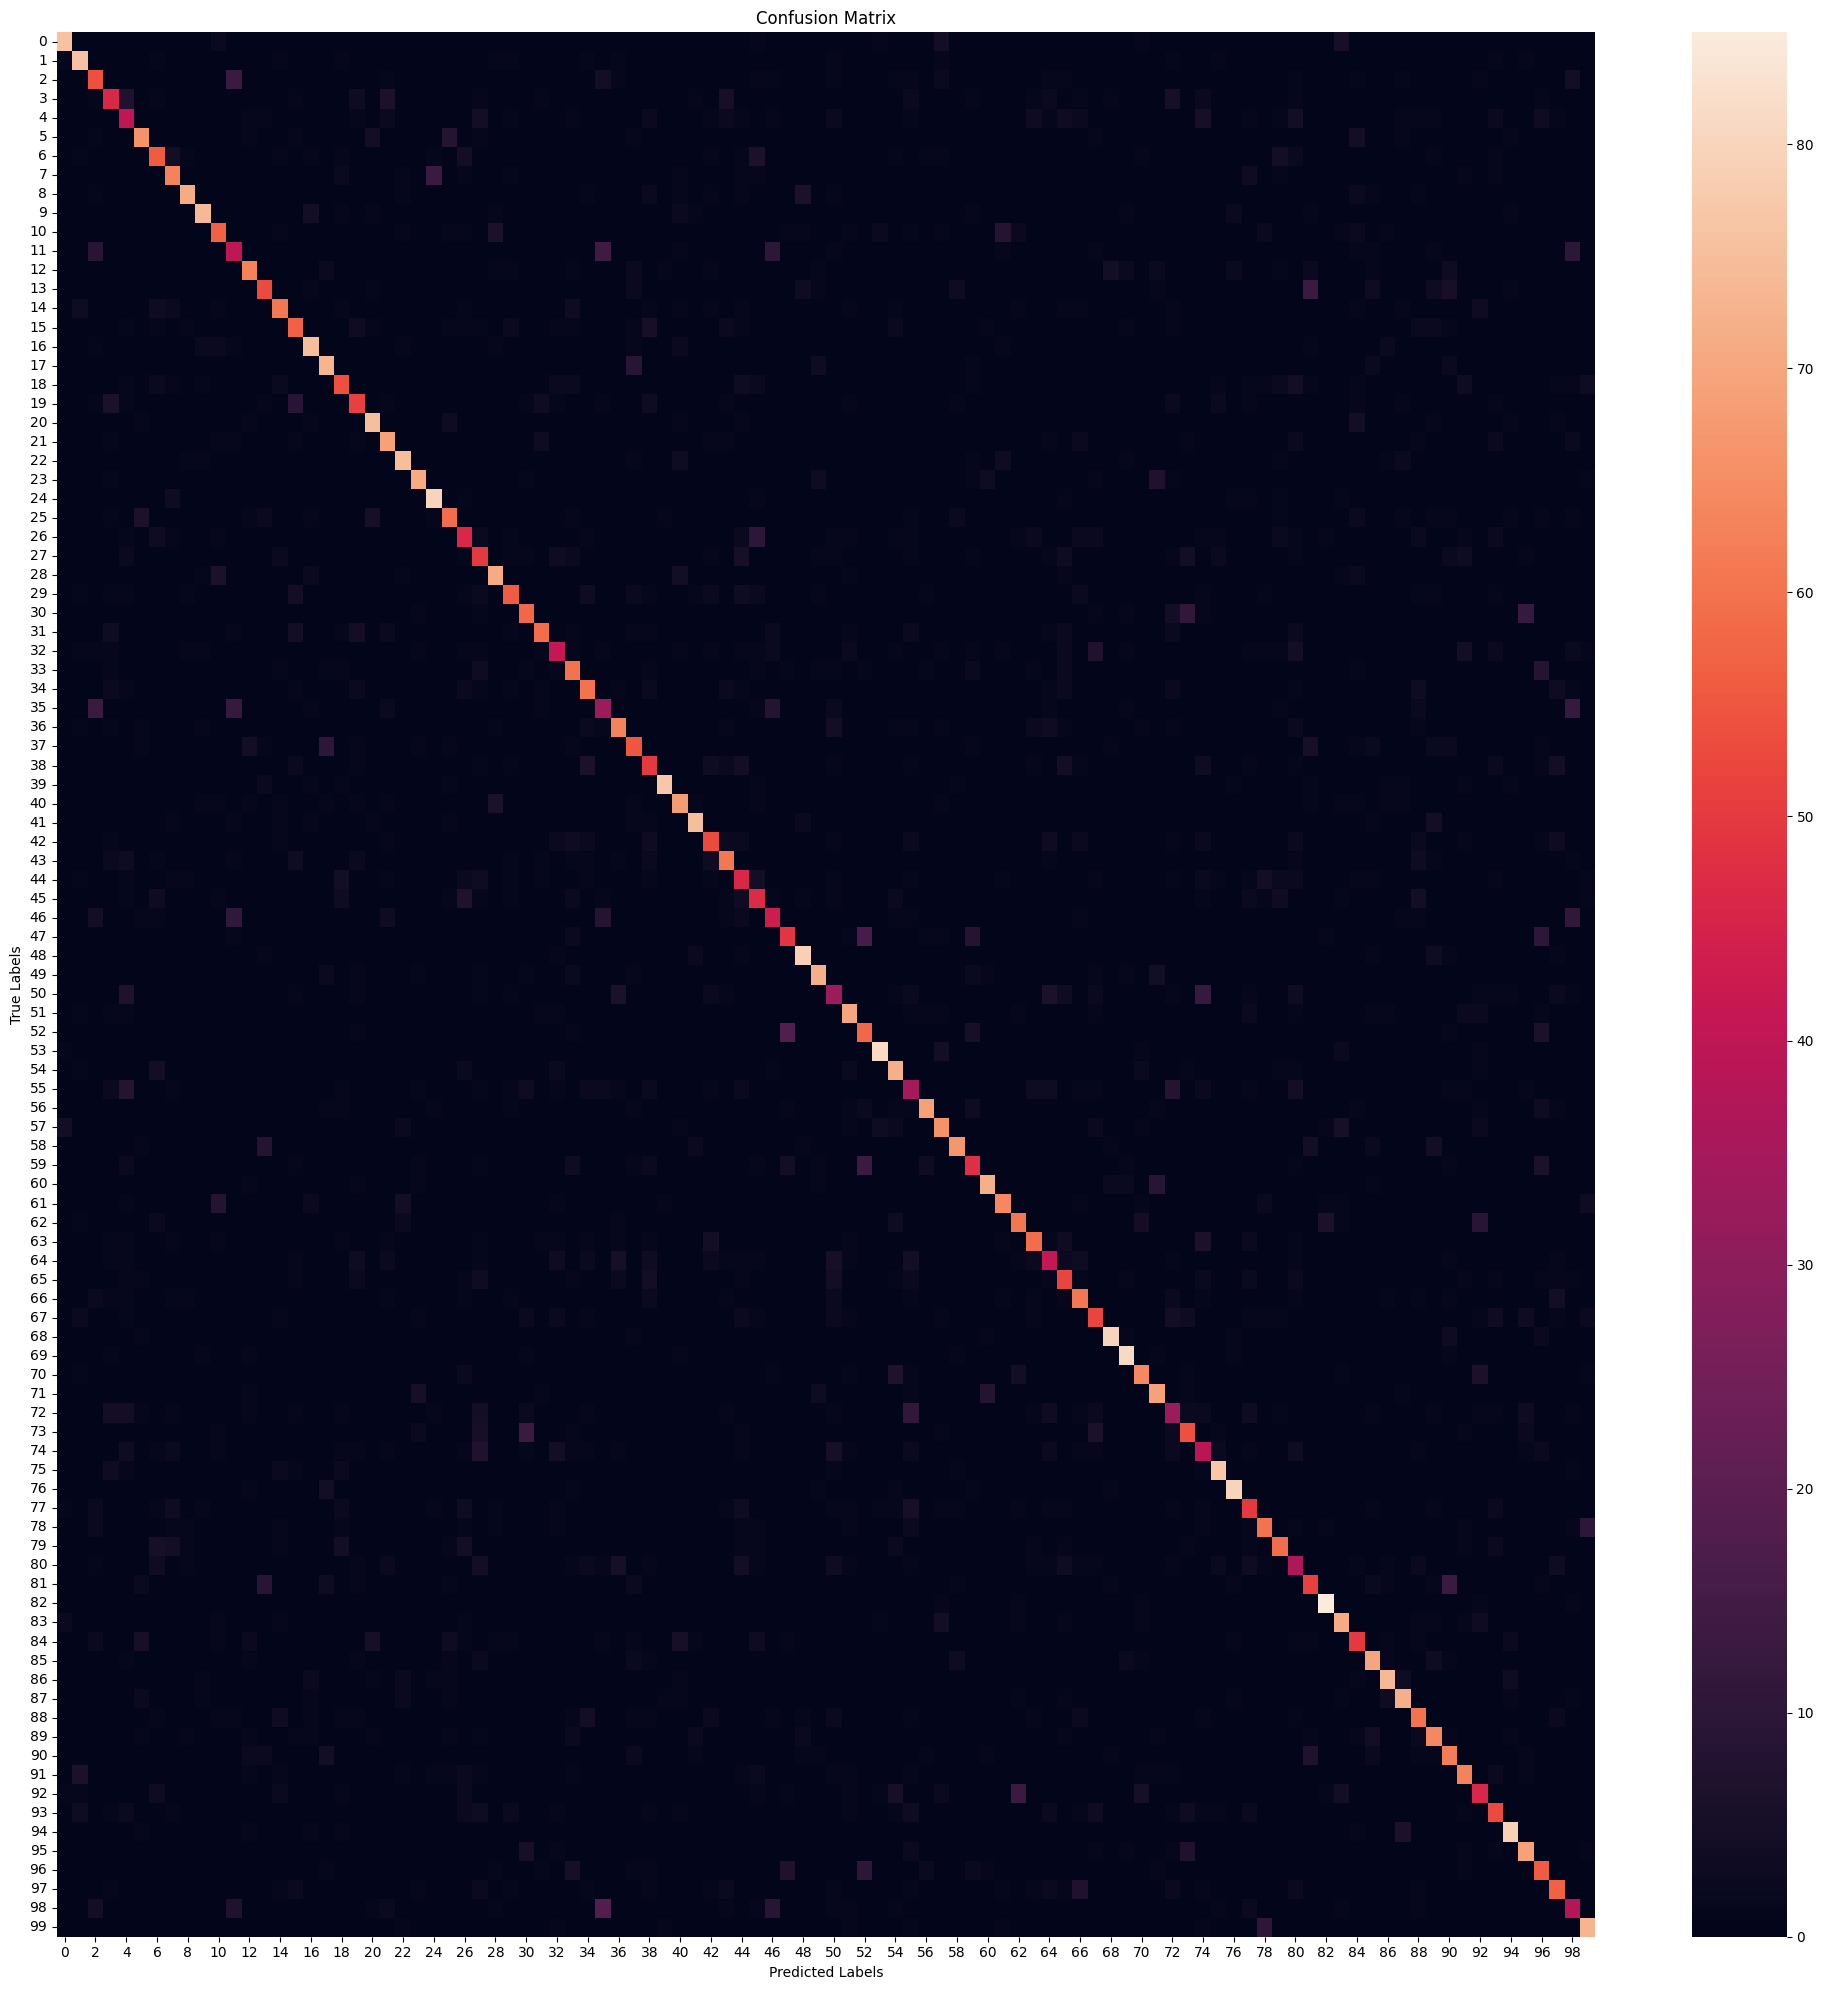

                   precision    recall  f1-score   support

           beaver       0.88      0.84      0.86        90
          dolphin       0.76      0.84      0.80        90
            otter       0.55      0.60      0.57        90
             seal       0.55      0.51      0.53        90
            whale       0.42      0.44      0.43        90
    aquarium fish       0.73      0.73      0.73        90
         flatfish       0.61      0.62      0.62        90
              ray       0.69      0.70      0.70        90
            shark       0.87      0.79      0.83        90
            trout       0.86      0.82      0.84        90
          orchids       0.66      0.63      0.65        90
          poppies       0.44      0.44      0.44        90
            roses       0.74      0.70      0.72        90
       sunflowers       0.66      0.59      0.62        90
           tulips       0.72      0.68      0.70        90
          bottles       0.62      0.63      0.63       

In [8]:
for repeat_2_times in range(2):
    #### <<<<<<<<<<Load and process data>>>>>>>>>>
    # Load CIFAR-100 dataset
    (X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode='fine')

    # Split (8000) of training data into temporary set
    X_temp, X_train, y_temp, y_train = train_test_split(X_train, y_train, test_size=0.84, stratify=y_train, random_state=42)
    print(f"X_temp.shape: {X_temp.shape}\n")

    # Split temp data into equal validation (4000) and testing (4000) data
    X_temp_val, X_temp_test, y_temp_val, y_temp_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
    print(f"X_temp_val.shape: {X_temp_val.shape}")
    print(f"y_temp_val.shape: {y_temp_val.shape}")
    print(f"X_temp_test.shape: {X_temp_test.shape}")
    print(f"y_temp_test.shape: {y_temp_test.shape}\n")

    # Split test data into validation (5000) and testing (5000)
    X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=42)

    # Add temp_val to validation (9000) and temp_test to testing (9000) to get a 70/15/15 data split
    X_val = np.concatenate((X_val, X_temp_val), axis=0)
    y_val = np.concatenate((y_val, y_temp_val), axis=0)
    X_test = np.concatenate((X_test, X_temp_test), axis=0)
    y_test = np.concatenate((y_test, y_temp_test), axis=0)

    print(f"X_train.shape: {X_train.shape}")
    print(f"y_train.shape: {y_train.shape}")
    print(f"X_val.shape: {X_val.shape}")
    print(f"y_val.shape: {y_val.shape}")
    print(f"X_test.shape: {X_test.shape}")
    print(f"y_test.shape: {y_test.shape}\n")

    display_imgs(X_train, y_train)

    # Normalise images (scale to range [0, 1]) - Improves convergence speed & accuracy
    X_train, X_val, X_test = X_train / 255.0, X_val / 255.0, X_test / 255.0
    display_imgs(X_train, y_train)

    labels_names = ['beaver','dolphin','otter','seal','whale','aquarium fish','flatfish','ray','shark','trout',
                   'orchids','poppies','roses','sunflowers','tulips','bottles','bowls','cans','cups','plates',
                   'apples','mushrooms','oranges','pears','sweet peppers','clock','computer keyboard','lamp',
                   'telephone','television','bed','chair','couch','table','wardrobe','bee','beetle','butterfly',
                   'caterpillar','cockroach','bear','leopard','lion','tiger','wolf','bridge','castle','house',
                   'road','skyscraper','cloud','forest','mountain','plain','sea','camel','cattle','chimpanzee',
                   'elephant','kangaroo','fox','porcupine','possum','raccoon','skunk','crab','lobster','snail',
                   'spider','worm','baby','boy','girl','man','woman','crocodile','dinosaur','lizard','snake',
                   'turtle','hamster','mouse','rabbit','shrew','squirrel','maple','oak','palm','pine','willow',
                   'bicycle','bus','motorcycle','pickup truck','train','lawn-mower','rocket','streetcar','tank',
                   'tractor']

    class_distrib(y_train, labels_names, "Training")
    class_distrib(y_val, labels_names, "Validating")
    class_distrib(y_test, labels_names, "Testing")

    # Create TensorFlow datasets

    batch_size = 64

    train_dataset_ = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
                     .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                        tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
                     .batch(batch_size)
                     .prefetch(tf.data.experimental.AUTOTUNE))

    # DEBUG augment
    #train_dataset_aug = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
    #                 .map(augment_dataset, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    #                 .batch(batch_size)
    #                 .prefetch(tf.data.experimental.AUTOTUNE))

    # Combine the original dataset and the augmented dataset
    train_dataset = train_dataset_#.concatenate(train_dataset_aug)

    val_dataset = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
                   .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                      tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
                   .batch(batch_size)
                   .prefetch(tf.data.experimental.AUTOTUNE))

    test_dataset = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
                     .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                        tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
                    .batch(batch_size)
                    .prefetch(tf.data.experimental.AUTOTUNE))

    print(f"Training dataset:\n {train_dataset}")
    for img, lbl in train_dataset.take(1):
        #if isinstance(batch, tuple) and len(batch) == 2:
        print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
        print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
        del img,lbl
    print(f"\nValidation dataset:\n {val_dataset}")
    for img, lbl in val_dataset.take(1):
        #if isinstance(batch, tuple) and len(batch) == 2:
        print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
        print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
        del img,lbl
    print(f"\nTesting dataset:\n {test_dataset}")
    for img, lbl in test_dataset.take(1):
        #if isinstance(batch, tuple) and len(batch) == 2:
        print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
        print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
        del img,lbl


    #### <<<<<<<<<<Pre-trained model>>>>>>>>>>
    # Load ResNet50 pre-trained on ImageNet (w/out the top classification layer which is designed for ImageNet (diff dataset))
    resnet_50_base = tf.keras.applications.ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Freeze the layers of VGG16 so they don't get updated during training - can unfreeze for fine tuning later
    resnet_50_base.trainable = False

    for layer in resnet_50_base.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            layer.kernel_regularizer = tf.keras.regularizers.l2(5e-2) # DEBUG l2

    # Add custom classification layers for CIFAR-100 (100 classes) - adapt model to CIFAR-100
    model = models.Sequential([
        resnet_50_base,
        layers.GlobalAveragePooling2D(), # Better for ResNet than Flatten
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5), # DEBUG dropout
        layers.Dense(100, activation='softmax')  # CIFAR-100 has 100 classes
    ])

    for sample in test_dataset.take(1):
        print(type(sample))  # Should be <class 'tuple'>
        print(len(sample))  # Should be 2
        print(type(sample[0]), type(sample[1]))  # Both should be <class 'tensorflow.Tensor'>
        print(sample[0].shape)  # Should be (batch_size, 224, 224, 3)
        print(sample[1].shape)  # Should be (batch_size, 100)
    print(f"Model input shape: {model.input_shape}")
    print(f"Model output shape: {model.output_shape}")
    sample = next(iter(test_dataset.as_numpy_iterator()))
    print(len(sample))  # Should be 2
    print(type(sample[0]), type(sample[1]))  # Both should be <class 'numpy.ndarray'>
    print(sample[0].shape, sample[1].shape)  # Should match model input and output
    print("\n")
    #for x, y in test_dataset.take(1):
    #    print(type(x), type(y))  # Both should be <class 'tensorflow.Tensor'>
    #for x_batch, y_batch in test_dataset.take(1):
    #    test_loss, test_acc = model.evaluate(x_batch, y_batch)
    #    print(f"Test Loss: {test_loss}, Test Accuracy: {test_acc}")

    # Compile the model
    #tensorboard_callback = keras.callbacks.TensorBoard(log_dir="./logs")
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3, weight_decay=5e-2), # DEBUG weight
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 'precision', 'f1_score'])

    model.summary()

    #### <<<<<<<<<<Train Model & Track Training/Validation Error>>>>>>>>>>
    early_stopping = EarlyStopping(monitor='val_loss', # or val_accuracy
                                   patience=5, # Num. epochs with no improvements - help void overfitting
                                   restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', # or val_accuracy
                                  factor=0.5, # Reduce lr by a factor
                                  patience=3, # Num epochs w/ no improvement
                                  min_lr=1e-6, # Min lr
                                  verbose=1)
    #tensorboard = TensorBoard(log_dir='./logs', # Logs directory
    #                         histogram_freq=1, # Logs histograms for weights/activations
    #                         write_graph=True, # Logs graph of model
    #                         write_images=True) # Log images like weight histogram
    checkpoint = ModelCheckpoint('best_model_v4.keras', # Path where the best model will be saved
                                 monitor='val_loss', # What to monitor (validation loss)
                                 save_best_only=True, # Only save model when validation loss improves
                                 mode='min', # Looking to minimse the validation loss
                                 verbose=1) # Print out message when saving model
    checkpoint_fine_tune = ModelCheckpoint('best_model_fine_tune_v4.keras', # Path where the best model will be saved
                                 monitor='val_loss', # What to monitor (validation loss)
                                 save_best_only=True, # Only save model when validation loss improves
                                 mode='min', # Looking to minimse the validation loss
                                 verbose=1) # Print out message when saving model
    #cvs_logger = CSVLogger('training_log.csv', seperator=',', append=True) # Save train metrics to analyse

    # Train the model
    history = model.fit(train_dataset, validation_data=val_dataset, epochs=25,
                        batch_size=batch_size, callbacks=[checkpoint, reduce_lr, early_stopping], verbose=1)

    #### <<<<<<<<<<Plot Training & Validation Error>>>>>>>>>>

    # Extract loss and accuracy
    epochs = range(1,len(history.history['loss'])+1)
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    plot_evidence(epochs, train_loss, val_loss, train_acc, val_acc)

    #### <<<<<<<<<<Evaluate Model on Test Data>>>>>>>>>>

    # Evaluate on test data
    model = load_model('best_model_v4.keras')
    results = model.evaluate(test_dataset)
    test_loss = results[0]
    test_acc = results[1]
    test_precision = results[2]
    test_f1_scores = results[3]
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"Test Loss: {test_loss}")
    print(f"Test Precision: {test_precision*100:.2f}%")
    print(f"Test F1 Scores (Per Class): {test_f1_scores.numpy()*100}")
    print(f"Average Test F1 Scores:{np.average(test_f1_scores.numpy()*100):.2f}\n")

    #### <<<<<<<<<<Generate Confusion Matrix>>>>>>>>>>

    # Get predictions
    X_test_revised = tf.image.resize(X_test, (224, 224))
    y_pred = model.predict(X_test_revised)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = y_test.flatten()

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

    # Plot confusion matrix
    plt.figure(figsize=(20, 20))
    sns.heatmap(conf_matrix) #cmap='Blues', fmt='d'
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true_classes, y_pred_classes, target_names=labels_names))
    #tensorboard --logdir==path_to_your_logs

    # Create a DataFrame from the history of the training and store the epoch values.
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    # Finally, display the hist DataFrame.
    hist

    #### <<<<<<<<<<Fine-Tune>>>>>>>>>>
    # Adapt Model
    for layer in resnet_50_base.layers:
        layer.trainable = True # Allow layers to be updated

    # Compile again w/ lower learning rate (prevents destroying learned features)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 'precision', 'f1_score'])

    model.summary()

    #### <<<<<<<<<<Modify Dataset>>>>>>>>>>


    # DEBUG augment
    train_dataset_aug_ = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
                     .map(augment_dataset, num_parallel_calls=tf.data.experimental.AUTOTUNE)
                     .batch(batch_size)
                     .prefetch(tf.data.experimental.AUTOTUNE))

    # Combine the original dataset and the augmented dataset
    train_dataset_aug = train_dataset.concatenate(train_dataset_aug_) # Not val or test as augment train helps generalise better, but want to provide consistent benchmark for eval perf

    #### <<<<<<<<<<Train Model & Track Training/Validation Error>>>>>>>>>>

    # Train the model
    history_fine_tune = model.fit(train_dataset_aug, validation_data=val_dataset, epochs=25,
                                  batch_size=batch_size, callbacks=[checkpoint_fine_tune, reduce_lr, early_stopping], verbose=1)

    #### <<<<<<<<<<Plot Training & Validation Error>>>>>>>>>>

    # Extract loss and accuracy
    epochs = range(1,len(history_fine_tune.history['loss'])+1)
    train_loss = history_fine_tune.history['loss']
    val_loss = history_fine_tune.history['val_loss']
    train_acc = history_fine_tune.history['accuracy']
    val_acc = history_fine_tune.history['val_accuracy']

    plot_evidence(epochs, train_loss, val_loss, train_acc, val_acc)

    #### <<<<<<<<<<Evaluate Model on Test Data>>>>>>>>>>

    # Evaluate on test data
    model_fine_tune = load_model('best_model_fine_tune_v4.keras')
    results = model_fine_tune.evaluate(test_dataset)
    test_loss = results[0]
    test_acc = results[1]
    test_precision = results[2]
    test_f1_scores = results[3]
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"Test Loss: {test_loss}")
    print(f"Test Precision: {test_precision*100:.2f}%")
    print(f"Test F1 Scores (Per Class): {test_f1_scores.numpy()*100}")
    print(f"Average Test F1 Scores:{np.average(test_f1_scores.numpy()*100):.2f}\n")

    #### <<<<<<<<<<Generate Confusion Matrix>>>>>>>>>>

    # Get predictions
    X_test_revised = tf.image.resize(X_test, (224, 224))
    y_pred = model_fine_tune.predict(X_test_revised)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = y_test.flatten()

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

    # Plot confusion matrix
    plt.figure(figsize=(20, 20))
    sns.heatmap(conf_matrix) #cmap='Blues', fmt='d'
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true_classes, y_pred_classes, target_names=labels_names))

    # Create a DataFrame from the history of the training and store the epoch values.
    hist = pd.DataFrame(history_fine_tune.history)
    hist['epoch'] = history_fine_tune.epoch

    # Finally, display the hist DataFrame.
    hist